# Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import matplotlib.ticker as ticker

In [2]:
df = pd.read_csv('data/real_estate_total.csv', encoding='cp949', parse_dates=["계약일"])
df

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_24657/1100737979.py:1: DtypeWarning: Columns (19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_estate_total.csv', encoding='cp949', parse_dates=["계약일"])


,접수연도,자치구코드,자치구명,법정동코드,법정동명,지번구분,지번구분명,본번,부번,건물명,...,물건금액(만원),건물면적(㎡),토지면적(㎡),층,권리구분,취소일,건축년도,건물용도,신고구분,신고한_개업공인중개사_시군구명
0,2018,11500,강서구,10300,화곡동,1.0,대지,1159.0,0.0,"우장산아이파크,이편한세상",...,95000,101.65,NaN,10.0,NaN,NaN,2008.0,아파트,NaN,NaN
1,2018,11410,서대문구,11200,대현동,1.0,대지,144.0,0.0,럭키대현,...,70000,83.38,NaN,10.0,NaN,NaN,1999.0,아파트,NaN,NaN
2,2018,11590,동작구,10700,사당동,1.0,대지,169.0,32.0,현대,...,49500,51.66,NaN,10.0,NaN,NaN,1991.0,아파트,NaN,NaN
3,2018,11350,노원구,10500,상계동,1.0,대지,1380.0,4.0,초산빌라,...,16000,41.37,18.38,1.0,NaN,NaN,1996.0,연립다세대,NaN,NaN
4,2018,11380,은평구,11000,증산동,1.0,대지,189.0,63.0,궁전맨션(189-63),...,43000,54.34,27.17,2.0,NaN,NaN,1992.0,연립다세대,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,2024,11530,구로구,10700,개봉동,1.0,대지,170.0,33.0,금석연립(170-33),...,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래,서울 강남구
833610,2024,11530,구로구,10700,개봉동,1.0,대지,170.0,33.0,금석연립(170-33),...,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래,서울 강남구
833611,2024,11530,구로구,10700,개봉동,1.0,대지,170.0,33.0,금석연립(170-33),...,9740,53.61,124.00,2.0,NaN,20240207.0,1981.0,연립다세대,중개거래,서울 강남구
833612,2024,11440,마포구,11000,노고산동,NaN,NaN,NaN,NaN,NaN,...,195000,157.45,116.70,NaN,NaN,20240417.0,1988.0,단독다가구,NaN,NaN


In [3]:
# 변경할 컬럼 매핑 딕셔너리 생성
# { "기존 한글명": "변경할 영어명" }
rename_dict = {
    "접수연도": "RCPT_YR",
    "자치구코드": "CGG_CD",
    "자치구명": "CGG_NM",
    "법정동코드": "STDG_CD",
    "법정동명": "STDG_NM",
    "지번구분": "LOTNO_SE",
    "지번구분명": "LOTNO_SE_NM",
    "본번": "MNO",
    "부번": "SNO",
    "건물명": "BLDG_NM",
    "계약일": "CTRT_DAY",
    "물건금액(만원)": "THING_AMT",
    "건물면적(㎡)": "ARCH_AREA",
    "토지면적(㎡)": "LAND_AREA",
    "층": "FLR",
    "권리구분": "RGHT_SE",
    "취소일": "RTRCN_DAY",
    "건축년도": "ARCH_YR",
    "건물용도": "BLDG_USG",
    "신고구분": "DCLR_SE",
    "신고한_개업공인중개사_시군구명": "OPBIZ_RESTAGNT_SGG_NM"
}

# 3. 컬럼명 변경 적용
df = df.rename(columns=rename_dict)

# 4. 제거할 열 리스트 (여기 적힌 열들이 삭제됩니다)
excluded_columns = [
    "RCPT_YR", "LOTNO_SE_NM", "MNO", "SNO", "OPBIZ_RESTAGNT_SGG_NM"
]
# 열 삭제 실행 (axis=1은 열을 의미합니다)
df_final = df.drop(columns=excluded_columns)

# 5. 결과 저장 (DBeaver 업로드용 UTF-8)
df_final.to_csv('data/real_estate_total_edit.csv', index=False, encoding='cp949')


In [4]:
df = pd.read_csv('data/real_estate_total_edit.csv', encoding='cp949', parse_dates=["CTRT_DAY"])
df

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_24657/2835427283.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_estate_total_edit.csv', encoding='cp949', parse_dates=["CTRT_DAY"])


,CGG_CD,CGG_NM,STDG_CD,STDG_NM,LOTNO_SE,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE
0,11500,강서구,10300,화곡동,1.0,"우장산아이파크,이편한세상",2019-04-25,95000,101.65,NaN,10.0,NaN,NaN,2008.0,아파트,NaN
1,11410,서대문구,11200,대현동,1.0,럭키대현,2019-03-16,70000,83.38,NaN,10.0,NaN,NaN,1999.0,아파트,NaN
2,11590,동작구,10700,사당동,1.0,현대,2019-02-21,49500,51.66,NaN,10.0,NaN,NaN,1991.0,아파트,NaN
3,11350,노원구,10500,상계동,1.0,초산빌라,2019-01-21,16000,41.37,18.38,1.0,NaN,NaN,1996.0,연립다세대,NaN
4,11380,은평구,11000,증산동,1.0,궁전맨션(189-63),2019-01-03,43000,54.34,27.17,2.0,NaN,NaN,1992.0,연립다세대,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,11530,구로구,10700,개봉동,1.0,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833610,11530,구로구,10700,개봉동,1.0,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833611,11530,구로구,10700,개봉동,1.0,금석연립(170-33),2022-07-08,9740,53.61,124.00,2.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833612,11440,마포구,11000,노고산동,NaN,NaN,2021-07-19,195000,157.45,116.70,NaN,NaN,20240417.0,1988.0,단독다가구,NaN


In [5]:
# 앞으로 사용할 데이터프레임 새로 생성
df2 = df.copy()
df2

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,LOTNO_SE,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE
0,11500,강서구,10300,화곡동,1.0,"우장산아이파크,이편한세상",2019-04-25,95000,101.65,NaN,10.0,NaN,NaN,2008.0,아파트,NaN
1,11410,서대문구,11200,대현동,1.0,럭키대현,2019-03-16,70000,83.38,NaN,10.0,NaN,NaN,1999.0,아파트,NaN
2,11590,동작구,10700,사당동,1.0,현대,2019-02-21,49500,51.66,NaN,10.0,NaN,NaN,1991.0,아파트,NaN
3,11350,노원구,10500,상계동,1.0,초산빌라,2019-01-21,16000,41.37,18.38,1.0,NaN,NaN,1996.0,연립다세대,NaN
4,11380,은평구,11000,증산동,1.0,궁전맨션(189-63),2019-01-03,43000,54.34,27.17,2.0,NaN,NaN,1992.0,연립다세대,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,11530,구로구,10700,개봉동,1.0,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833610,11530,구로구,10700,개봉동,1.0,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833611,11530,구로구,10700,개봉동,1.0,금석연립(170-33),2022-07-08,9740,53.61,124.00,2.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833612,11440,마포구,11000,노고산동,NaN,NaN,2021-07-19,195000,157.45,116.70,NaN,NaN,20240417.0,1988.0,단독다가구,NaN


In [6]:
# 날짜 컬럼을 datetime 형식으로 변환 (필수!)
df2['CTRT_DAY'] = pd.to_datetime(df2['CTRT_DAY'])

# 계약 연도 컬럼 새로 생성
df2['CTRT_YEAR'] = df2['CTRT_DAY'].dt.year 

# 계약일 연도값별로 개수 count 하고 연도 순서대로 정렬
print(df2['CTRT_DAY'].dt.year.value_counts().sort_index())
'''
CTRT_DAY
2008         2
2009         1
2010         1
2011         2
2012         2
2013         3
2014         3
2015         7
2016        64
2017     1336,0
2018    157931
2019    141204
2020    175320
2021    134779
2022     64804
2023     70406
2024     75725
Name: count, dtype: int64
'''

CTRT_DAY
2008         2
2009         1
2010         1
2011         2
2012         2
2013         3
2014         3
2015         7
2016        64
2017     13360
2018    157931
2019    141204
2020    175320
2021    134779
2022     64804
2023     70406
2024     75725
Name: count, dtype: int64


'\nCTRT_DAY\n2008         2\n2009         1\n2010         1\n2011         2\n2012         2\n2013         3\n2014         3\n2015         7\n2016        64\n2017     1336,0\n2018    157931\n2019    141204\n2020    175320\n2021    134779\n2022     64804\n2023     70406\n2024     75725\nName: count, dtype: int64\n'

In [7]:
# 2018년부터 2024년까지 리스트 설정
target_years = list(range(2018, 2025))

# 해당 연도에 포함되는 데이터만 남기고 copy
df2 = df2[df2['CTRT_DAY'].dt.year.isin(target_years)].copy()

# 필터링 잘 되었는지 결과 확인 
print(df2['CTRT_DAY'].dt.year.value_counts().sort_index())

# 전체 행 수 확인
print(f"\n최종 남은 데이터 건수: {len(df2):,}건")

'''
CTRT_DAY
2018    157931
2019    141204
2020    175320
2021    134779
2022     64804
2023     70406
2024     75725
Name: count, dtype: int64

최종 남은 데이터 건수: 820,169건
'''

CTRT_DAY
2018    157931
2019    141204
2020    175320
2021    134779
2022     64804
2023     70406
2024     75725
Name: count, dtype: int64

최종 남은 데이터 건수: 820,169건


'\nCTRT_DAY\n2018    157931\n2019    141204\n2020    175320\n2021    134779\n2022     64804\n2023     70406\n2024     75725\nName: count, dtype: int64\n\n최종 남은 데이터 건수: 820,169건\n'

In [8]:
# 새로 생성된 컬럼 CTRT_YEAR 과 CTRT_DAY 형식이 datetime 형으로 변환된 것을 확인
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 820169 entries, 0 to 833613
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   CGG_CD     820169 non-null  int64         
 1   CGG_NM     820168 non-null  object        
 2   STDG_CD    820169 non-null  int64         
 3   STDG_NM    820169 non-null  object        
 4   LOTNO_SE   763776 non-null  float64       
 5   BLDG_NM    763798 non-null  object        
 6   CTRT_DAY   820169 non-null  datetime64[ns]
 7   THING_AMT  820169 non-null  int64         
 8   ARCH_AREA  820169 non-null  float64       
 9   LAND_AREA  656055 non-null  float64       
 10  FLR        763852 non-null  float64       
 11  RGHT_SE    7310 non-null    object        
 12  RTRCN_DAY  25541 non-null   float64       
 13  ARCH_YR    816779 non-null  float64       
 14  BLDG_USG   820169 non-null  object        
 15  DCLR_SE    225344 non-null  object        
 16  CTRT_YEAR  820169 non-nul

In [9]:
# 지번구분 열 삭제
df2 = df2.drop(columns= 'LOTNO_SE')
df2

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
0,11500,강서구,10300,화곡동,"우장산아이파크,이편한세상",2019-04-25,95000,101.65,NaN,10.0,NaN,NaN,2008.0,아파트,NaN,2019
1,11410,서대문구,11200,대현동,럭키대현,2019-03-16,70000,83.38,NaN,10.0,NaN,NaN,1999.0,아파트,NaN,2019
2,11590,동작구,10700,사당동,현대,2019-02-21,49500,51.66,NaN,10.0,NaN,NaN,1991.0,아파트,NaN,2019
3,11350,노원구,10500,상계동,초산빌라,2019-01-21,16000,41.37,18.38,1.0,NaN,NaN,1996.0,연립다세대,NaN,2019
4,11380,은평구,11000,증산동,궁전맨션(189-63),2019-01-03,43000,54.34,27.17,2.0,NaN,NaN,1992.0,연립다세대,NaN,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래,2022
833610,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래,2022
833611,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9740,53.61,124.00,2.0,NaN,20240207.0,1981.0,연립다세대,중개거래,2022
833612,11440,마포구,11000,노고산동,NaN,2021-07-19,195000,157.45,116.70,NaN,NaN,20240417.0,1988.0,단독다가구,NaN,2021


In [10]:
# 자치구명 결측치 확인 (1건 발견)
df2['CGG_NM'].isna().sum() # np.int64(1)

np.int64(1)

In [11]:
# 해당 오류 행 제거
df2 = df2.dropna(subset=['CGG_NM'])

In [12]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 820168 entries, 0 to 833613
Data columns (total 16 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   CGG_CD     820168 non-null  int64         
 1   CGG_NM     820168 non-null  object        
 2   STDG_CD    820168 non-null  int64         
 3   STDG_NM    820168 non-null  object        
 4   BLDG_NM    763797 non-null  object        
 5   CTRT_DAY   820168 non-null  datetime64[ns]
 6   THING_AMT  820168 non-null  int64         
 7   ARCH_AREA  820168 non-null  float64       
 8   LAND_AREA  656054 non-null  float64       
 9   FLR        763851 non-null  float64       
 10  RGHT_SE    7309 non-null    object        
 11  RTRCN_DAY  25541 non-null   float64       
 12  ARCH_YR    816778 non-null  float64       
 13  BLDG_USG   820168 non-null  object        
 14  DCLR_SE    225343 non-null  object        
 15  CTRT_YEAR  820168 non-null  int32         
dtypes: datetime64[ns](1), flo

In [13]:
# 취소일(RTRCN_DAY)이 있는 행 제거
df2 = df2[df2["RTRCN_DAY"].isna()].copy()
df2 = df2.drop(columns=["RTRCN_DAY"])

In [14]:
df2

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
0,11500,강서구,10300,화곡동,"우장산아이파크,이편한세상",2019-04-25,95000,101.65,NaN,10.0,NaN,2008.0,아파트,NaN,2019
1,11410,서대문구,11200,대현동,럭키대현,2019-03-16,70000,83.38,NaN,10.0,NaN,1999.0,아파트,NaN,2019
2,11590,동작구,10700,사당동,현대,2019-02-21,49500,51.66,NaN,10.0,NaN,1991.0,아파트,NaN,2019
3,11350,노원구,10500,상계동,초산빌라,2019-01-21,16000,41.37,18.38,1.0,NaN,1996.0,연립다세대,NaN,2019
4,11380,은평구,11000,증산동,궁전맨션(189-63),2019-01-03,43000,54.34,27.17,2.0,NaN,1992.0,연립다세대,NaN,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833594,11740,강동구,10900,천호동,경복빌라,2023-11-21,28500,44.11,32.99,1.0,NaN,1991.0,연립다세대,중개거래,2023
833595,11215,광진구,10700,화양동,KCC파크타운,2023-11-14,19000,25.79,37.36,14.0,NaN,2005.0,오피스텔,중개거래,2023
833596,11440,마포구,12200,합정동,그레이스빌2차A,2023-11-13,26300,22.44,12.65,5.0,NaN,2004.0,연립다세대,직거래,2023
833597,11440,마포구,12600,중동,백명TRENDYAPT,2023-11-11,76000,107.48,0.00,6.0,NaN,2004.0,아파트,중개거래,2023


In [15]:
df2['ARCH_YR'].isnull().sum()

np.int64(3255)

In [16]:
null_build_df = df2[df2['ARCH_YR'].isna()]
print(null_build_df['CGG_NM'].value_counts(dropna=False))

CGG_NM
송파구     1946
동대문구     269
마포구      153
용산구      144
도봉구       98
은평구       94
강서구       91
영등포구      76
금천구       58
중구        49
강남구       46
관악구       26
중랑구       26
광진구       25
구로구       25
강동구       25
성북구       24
동작구       23
성동구       17
양천구       17
종로구       10
서초구        6
강북구        4
서대문구       2
노원구        1
Name: count, dtype: int64


In [17]:
# 건축년도가 NULL인 데이터 필터링
null_build_df = df2[df2['ARCH_YR'].isnull()]

# 권리구분별 빈도수 계산
counts = null_build_df[['CGG_NM','BLDG_NM','BLDG_USG']].value_counts(dropna=False)

# 빈도수가 30개 이상인 항목만 필터링하여 출력
print(counts[counts >= 30])


CGG_NM  BLDG_NM        BLDG_USG
송파구     파크하비오          오피스텔        1506
        엠스테이트          오피스텔         208
동대문구    동대문 푸르지오시티     오피스텔         157
용산구     래미안 용산 더 센트럴   오피스텔         144
송파구     대명벨리온          오피스텔         110
마포구     갑을명가시티2        오피스텔          91
도봉구     도봉 투웨니퍼스트 2단지  오피스텔          80
마포구     갑을명가시티1        오피스텔          49
송파구     롯데월드타워앤드롯데월드몰  오피스텔          40
동대문구    동트리움 에이동       오피스텔          40
        동트리움 비동        오피스텔          40
송파구     석촌호수 나인파크 A    오피스텔          39
은평구     은평헤스티아 2차      오피스텔          37
송파구     석촌호수 나인파크 B    오피스텔          35
중구      주건축물제1동        오피스텔          34
Name: count, dtype: int64


- 49 → 86로 개수가 확 튀는 구간 존재
- 누락 비중이 높은 상위 7개 단지의 실제 건축년도 파악

In [18]:
# 업데이트할 정밀 단지 정보 리스트 (자치구, 법정동, 본번, 부번, 건물명, 건물용도, 건축년도)
build_info = [
    ('송파구', '문정동', '파크하비오', '오피스텔', 2016),
    ('송파구', '문정동', '엠스테이트', '오피스텔', 2016),
    ('동대문구', '용두동', '동대문 푸르지오시티', '오피스텔', 2016),
    ('용산구', '한강로2가', '래미안 용산 더 센트럴', '오피스텔', 2017),
    ('송파구', '방이동', '대명벨리온', '오피스텔', 2017),
    ('마포구', '신공덕동', '갑을명가시티2', '오피스텔', 2016),
    ('도봉구', '도봉동', '도봉 투웨니퍼스트 2단지', '오피스텔', 2017)
]

# 반복문을 통해 모든 조건을 만족하는 행의 건축년도 업데이트
for gu, dong, bldg, usage, year in build_info:
    condition = (
        (df2['CGG_NM'] == gu) & 
        (df2['STDG_NM'] == dong) & 
        (df2['BLDG_NM'] == bldg) & 
        (df2['BLDG_USG'] == usage) &
        (df2['ARCH_YR'].isnull())
    )
    df2.loc[condition, 'ARCH_YR'] = year

# 업데이트 후에도 남아있는 결측치를 9999로 채우기 (핵심!)
df2['ARCH_YR'] = df2['ARCH_YR'].fillna(9999)

# 실수형(float)을 정수형(int)으로 변환해서 보기 좋게 만들기
df2['ARCH_YR'] = df2['ARCH_YR'].astype(int)


In [19]:
df2

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
0,11500,강서구,10300,화곡동,"우장산아이파크,이편한세상",2019-04-25,95000,101.65,NaN,10.0,NaN,2008,아파트,NaN,2019
1,11410,서대문구,11200,대현동,럭키대현,2019-03-16,70000,83.38,NaN,10.0,NaN,1999,아파트,NaN,2019
2,11590,동작구,10700,사당동,현대,2019-02-21,49500,51.66,NaN,10.0,NaN,1991,아파트,NaN,2019
3,11350,노원구,10500,상계동,초산빌라,2019-01-21,16000,41.37,18.38,1.0,NaN,1996,연립다세대,NaN,2019
4,11380,은평구,11000,증산동,궁전맨션(189-63),2019-01-03,43000,54.34,27.17,2.0,NaN,1992,연립다세대,NaN,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833594,11740,강동구,10900,천호동,경복빌라,2023-11-21,28500,44.11,32.99,1.0,NaN,1991,연립다세대,중개거래,2023
833595,11215,광진구,10700,화양동,KCC파크타운,2023-11-14,19000,25.79,37.36,14.0,NaN,2005,오피스텔,중개거래,2023
833596,11440,마포구,12200,합정동,그레이스빌2차A,2023-11-13,26300,22.44,12.65,5.0,NaN,2004,연립다세대,직거래,2023
833597,11440,마포구,12600,중동,백명TRENDYAPT,2023-11-11,76000,107.48,0.00,6.0,NaN,2004,아파트,중개거래,2023


In [20]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 794627 entries, 0 to 833598
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   CGG_CD     794627 non-null  int64         
 1   CGG_NM     794627 non-null  object        
 2   STDG_CD    794627 non-null  int64         
 3   STDG_NM    794627 non-null  object        
 4   BLDG_NM    741465 non-null  object        
 5   CTRT_DAY   794627 non-null  datetime64[ns]
 6   THING_AMT  794627 non-null  int64         
 7   ARCH_AREA  794627 non-null  float64       
 8   LAND_AREA  633679 non-null  float64       
 9   FLR        741516 non-null  float64       
 10  RGHT_SE    7039 non-null    object        
 11  ARCH_YR    794627 non-null  int64         
 12  BLDG_USG   794627 non-null  object        
 13  DCLR_SE    213703 non-null  object        
 14  CTRT_YEAR  794627 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(1), int64(4), object(6)
memory us

In [21]:
df2.describe()

,CGG_CD,STDG_CD,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,ARCH_YR,CTRT_YEAR
count,794627.000000,794627.000000,794627,7.946270e+05,794627.000000,633679.000000,741516.000000,794627.000000,794627.000000
mean,11451.150722,10939.447439,2020-11-03 02:43:27.686877440,6.377750e+04,69.559560,31.413722,6.825642,1994.524321,2020.357168
min,11110.000000,10100.000000,2018-01-01 00:00:00,1.700000e+03,5.070000,0.000000,-3.000000,0.000000,2018.000000
25%,11305.000000,10200.000000,2019-06-18 00:00:00,2.450000e+04,38.680000,0.000000,3.000000,1993.000000,2019.000000
50%,11470.000000,10500.000000,2020-07-15 00:00:00,4.200000e+04,59.400000,22.740000,5.000000,2003.000000,2020.000000
75%,11590.000000,10900.000000,2022-01-10 00:00:00,7.980000e+04,84.780000,35.180000,10.000000,2013.000000,2022.000000
max,11740.000000,18700.000000,2024-10-14 00:00:00,1.108778e+07,3619.840000,119119.000000,73.000000,9999.000000,2024.000000
std,173.094821,1249.319875,NaN,7.190258e+04,64.349954,165.101719,5.891791,335.874787,1.879475


In [22]:
# 데이터 로드
df_ref = pd.read_csv('data/법정동합본.csv', encoding='euc-kr')

# 컬럼명 및 데이터 타입 정리
df_ref.columns = ['CGG_CD', 'CGG_NM', 'STDG_CD', 'STDG_NM']
cols_to_str = ['CGG_CD', 'STDG_CD']
for col in cols_to_str:
    df_ref[col] = df_ref[col].astype(str)
    df2[col] = df2[col].astype(str)

# 매퍼(Mapper) 생성
# 자치구 매퍼
gu_mapper = dict(zip(df_ref['CGG_CD'], df_ref['CGG_NM']))

# 법정동 매퍼 (Key: 구코드 + 동코드)
df_ref['key'] = df_ref['CGG_CD'] + df_ref['STDG_CD']
df2['key'] = df2['CGG_CD'] + df2['STDG_CD']
dong_mapper = dict(zip(df_ref['key'], df_ref['STDG_NM']))

# 데이터 필터링 (불일치/미매핑 즉시 제거)
# 매핑된 정답 이름을 가져와서 원본과 비교합니다.
# (조건: 자치구명 일치 AND 법정동명 일치)
# map 결과가 NaN이거나 이름이 다르면 조건문에서 False가 되어 자동으로 제거됩니다.
initial_count = len(df2)

df2 = df2[
    (df2['CGG_NM'] == df2['CGG_CD'].map(gu_mapper)) & 
    (df2['STDG_NM'] == df2['key'].map(dong_mapper))
].copy()

# 4. 후처리 (임시 컬럼 삭제 및 결과 확인)
df2 = df2.drop(columns=['key'])

print(f"처리 완료: 총 {initial_count}건 중 {initial_count - len(df2)}건 삭제됨 (남은 데이터: {len(df2)}건)")
df2.head()

처리 완료: 총 794627건 중 21건 삭제됨 (남은 데이터: 794606건)


,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
0,11500,강서구,10300,화곡동,"우장산아이파크,이편한세상",2019-04-25,95000,101.65,NaN,10.0,NaN,2008,아파트,NaN,2019
1,11410,서대문구,11200,대현동,럭키대현,2019-03-16,70000,83.38,NaN,10.0,NaN,1999,아파트,NaN,2019
2,11590,동작구,10700,사당동,현대,2019-02-21,49500,51.66,NaN,10.0,NaN,1991,아파트,NaN,2019
3,11350,노원구,10500,상계동,초산빌라,2019-01-21,16000,41.37,18.38,1.0,NaN,1996,연립다세대,NaN,2019
4,11380,은평구,11000,증산동,궁전맨션(189-63),2019-01-03,43000,54.34,27.17,2.0,NaN,1992,연립다세대,NaN,2019


In [23]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 794606 entries, 0 to 833598
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   CGG_CD     794606 non-null  object        
 1   CGG_NM     794606 non-null  object        
 2   STDG_CD    794606 non-null  object        
 3   STDG_NM    794606 non-null  object        
 4   BLDG_NM    741444 non-null  object        
 5   CTRT_DAY   794606 non-null  datetime64[ns]
 6   THING_AMT  794606 non-null  int64         
 7   ARCH_AREA  794606 non-null  float64       
 8   LAND_AREA  633666 non-null  float64       
 9   FLR        741495 non-null  float64       
 10  RGHT_SE    7039 non-null    object        
 11  ARCH_YR    794606 non-null  int64         
 12  BLDG_USG   794606 non-null  object        
 13  DCLR_SE    213700 non-null  object        
 14  CTRT_YEAR  794606 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(1), int64(2), object(8)
memory us

In [24]:
df2.to_csv('data/real_estate_clean_v1.csv', index=False,encoding='cp949')

In [25]:
df3 = pd.read_csv('data/real_estate_clean_v1.csv', encoding='cp949')
df3

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_24657/2389910127.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv('data/real_estate_clean_v1.csv', encoding='cp949')


,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
0,11500,강서구,10300,화곡동,"우장산아이파크,이편한세상",2019-04-25,95000,101.65,NaN,10.0,NaN,2008,아파트,NaN,2019
1,11410,서대문구,11200,대현동,럭키대현,2019-03-16,70000,83.38,NaN,10.0,NaN,1999,아파트,NaN,2019
2,11590,동작구,10700,사당동,현대,2019-02-21,49500,51.66,NaN,10.0,NaN,1991,아파트,NaN,2019
3,11350,노원구,10500,상계동,초산빌라,2019-01-21,16000,41.37,18.38,1.0,NaN,1996,연립다세대,NaN,2019
4,11380,은평구,11000,증산동,궁전맨션(189-63),2019-01-03,43000,54.34,27.17,2.0,NaN,1992,연립다세대,NaN,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794601,11740,강동구,10900,천호동,경복빌라,2023-11-21,28500,44.11,32.99,1.0,NaN,1991,연립다세대,중개거래,2023
794602,11215,광진구,10700,화양동,KCC파크타운,2023-11-14,19000,25.79,37.36,14.0,NaN,2005,오피스텔,중개거래,2023
794603,11440,마포구,12200,합정동,그레이스빌2차A,2023-11-13,26300,22.44,12.65,5.0,NaN,2004,연립다세대,직거래,2023
794604,11440,마포구,12600,중동,백명TRENDYAPT,2023-11-11,76000,107.48,0.00,6.0,NaN,2004,아파트,중개거래,2023


In [26]:
df3.isna().sum()

CGG_CD            0
CGG_NM            0
STDG_CD           0
STDG_NM           0
BLDG_NM       53162
CTRT_DAY          0
THING_AMT         0
ARCH_AREA         0
LAND_AREA    160940
FLR           53111
RGHT_SE      787567
ARCH_YR           0
BLDG_USG          0
DCLR_SE      580906
CTRT_YEAR         0
dtype: int64

In [27]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 794606 entries, 0 to 794605
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   CGG_CD     794606 non-null  int64  
 1   CGG_NM     794606 non-null  object 
 2   STDG_CD    794606 non-null  int64  
 3   STDG_NM    794606 non-null  object 
 4   BLDG_NM    741444 non-null  object 
 5   CTRT_DAY   794606 non-null  object 
 6   THING_AMT  794606 non-null  int64  
 7   ARCH_AREA  794606 non-null  float64
 8   LAND_AREA  633666 non-null  float64
 9   FLR        741495 non-null  float64
 10  RGHT_SE    7039 non-null    object 
 11  ARCH_YR    794606 non-null  int64  
 12  BLDG_USG   794606 non-null  object 
 13  DCLR_SE    213700 non-null  object 
 14  CTRT_YEAR  794606 non-null  int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 90.9+ MB


In [28]:
# 건물 면적 대비 건물 가격을 통한 이상치 제거
df4 = df3.copy()
len(df4)

794606

In [29]:
# --- [한글 폰트 및 마이너스 깨짐 방지 설정] ---
def set_korean_font():
    os_name = platform.system()
    if os_name == 'Darwin':  # MacOS
        plt.rc('font', family='AppleGothic')
    elif os_name == 'Windows': # Windows
        plt.rc('font', family='Malgun Gothic')
    
    # 마이너스 기호 깨짐 방지
    plt.rc('axes', unicode_minus=False)

set_korean_font()

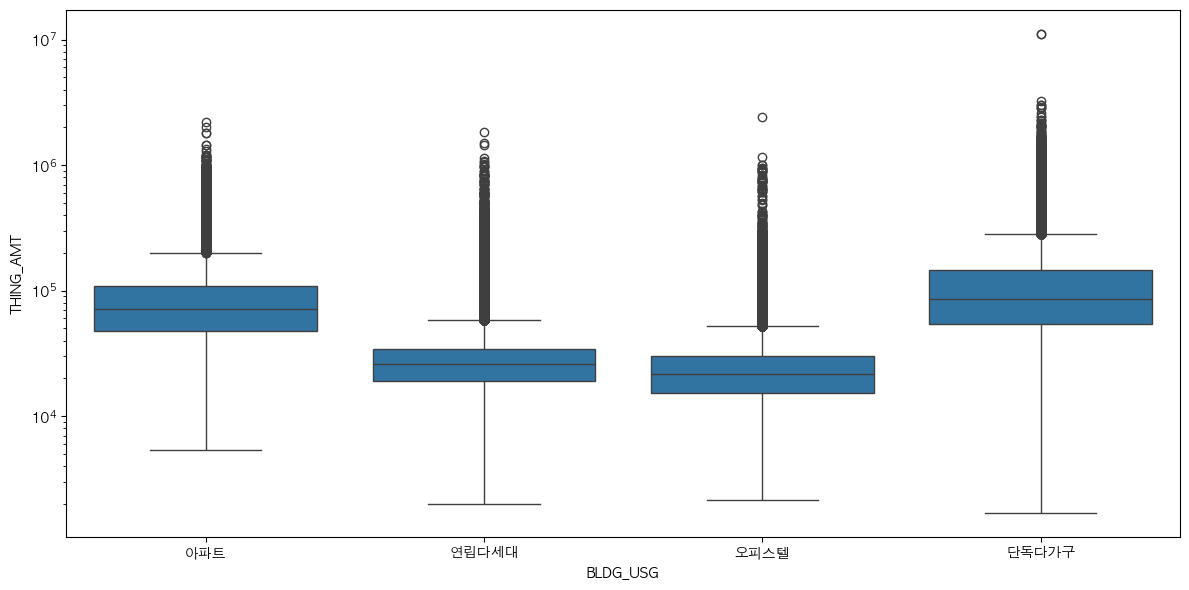

In [30]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df4, x='BLDG_USG', y='THING_AMT')
plt.yscale('log') # 범위가 너무 넓어서 로그스케일 사용
plt.tight_layout() 
plt.show()

<class 'pandas.core.frame.DataFrame'>
Index: 375767 entries, 0 to 794605
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   CGG_CD     375767 non-null  int64  
 1   CGG_NM     375767 non-null  object 
 2   STDG_CD    375767 non-null  int64  
 3   STDG_NM    375767 non-null  object 
 4   BLDG_NM    375767 non-null  object 
 5   CTRT_DAY   375767 non-null  object 
 6   THING_AMT  375767 non-null  int64  
 7   ARCH_AREA  375767 non-null  float64
 8   LAND_AREA  214827 non-null  float64
 9   FLR        375767 non-null  float64
 10  RGHT_SE    7039 non-null    object 
 11  ARCH_YR    375767 non-null  int64  
 12  BLDG_USG   375767 non-null  object 
 13  DCLR_SE    92761 non-null   object 
 14  CTRT_YEAR  375767 non-null  int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 45.9+ MB


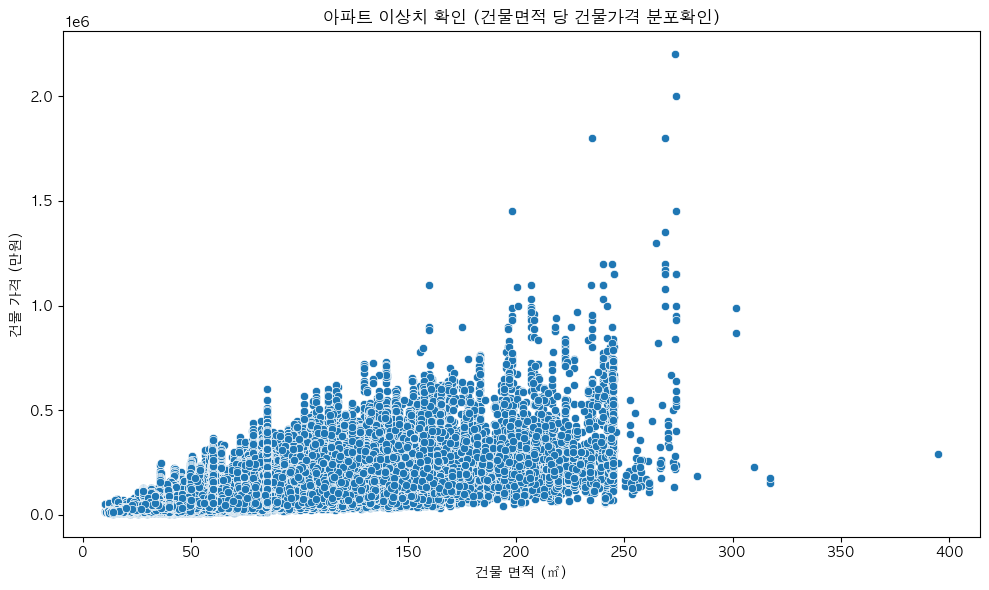

In [31]:
# 아파트 이상치 확인
apt = df4[df4['BLDG_USG']=='아파트']
apt.info()

plt.figure(figsize=(10,6))
sns.scatterplot(data=apt, x='ARCH_AREA', y='THING_AMT')
plt.title('아파트 이상치 확인 (건물면적 당 건물가격 분포확인)')
plt.xlabel('건물 면적 (㎡)')
plt.ylabel('건물 가격 (만원)')

plt.tight_layout() 
plt.show()

In [32]:
apt['ARCH_AREA'].describe()

count    375767.000000
mean         76.420447
std          30.520939
min          10.020000
25%          59.650000
50%          81.050000
75%          84.960000
max         395.060000
Name: ARCH_AREA, dtype: float64

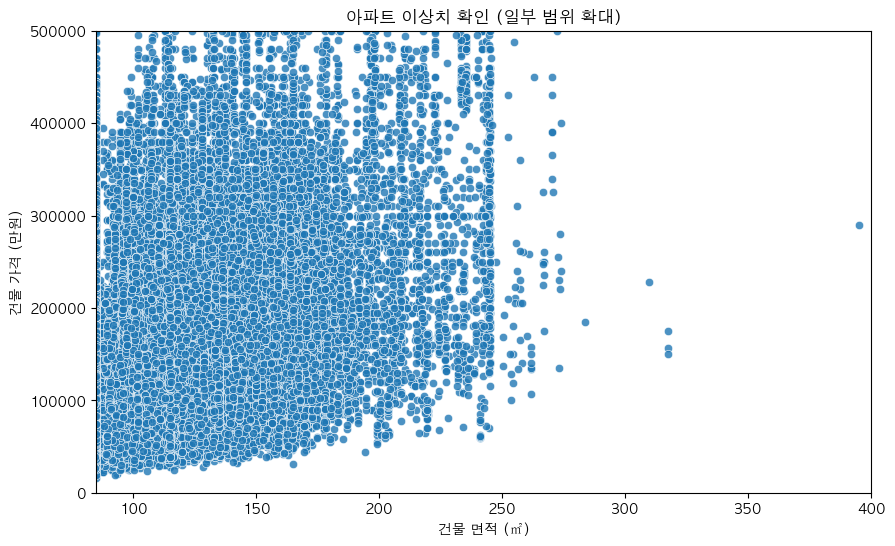

In [33]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=apt, x='ARCH_AREA', y='THING_AMT', alpha=0.8) # alpha로 겹친 점 확인

area_q3 = apt['ARCH_AREA'].quantile(0.75)
# x축: q3 ~ 400 (건물면적 최댓값이 395)
# y축: 금액 50억(500,000만원) 이하로 제한
plt.xlim(area_q3,400)
plt.ylim(0, 0.5e+06)

plt.title('아파트 이상치 확인 (일부 범위 확대)')
plt.xlabel('건물 면적 (㎡)')
plt.ylabel('건물 가격 (만원)')
plt.show()

In [34]:
apt[apt['ARCH_AREA']>300]

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
8974,11170,용산구,12900,이촌동,정우,2018-10-26,157000,317.36,NaN,5.0,NaN,1972,아파트,NaN,2018
17365,11650,서초구,10800,서초동,월드빌라트,2018-09-28,290000,395.06,NaN,10.0,NaN,1996,아파트,NaN,2018
356007,11170,용산구,12900,이촌동,정우,2020-07-04,150000,317.36,0.0,2.0,NaN,1972,아파트,NaN,2020
531853,11170,용산구,12900,이촌동,정우,2021-05-13,175000,317.36,0.0,9.0,NaN,1972,아파트,NaN,2021
623827,11680,강남구,11800,도곡동,타워팰리스1,2022-05-12,870000,301.47,0.0,56.0,NaN,2002,아파트,중개거래,2022
679683,11680,강남구,11800,도곡동,타워팰리스1,2023-07-31,990000,301.47,0.0,55.0,NaN,2002,아파트,중개거래,2023
708086,11140,중구,14300,장충동1가,장충레지던스,2023-03-16,228000,309.70,0.0,4.0,NaN,1993,아파트,직거래,2023


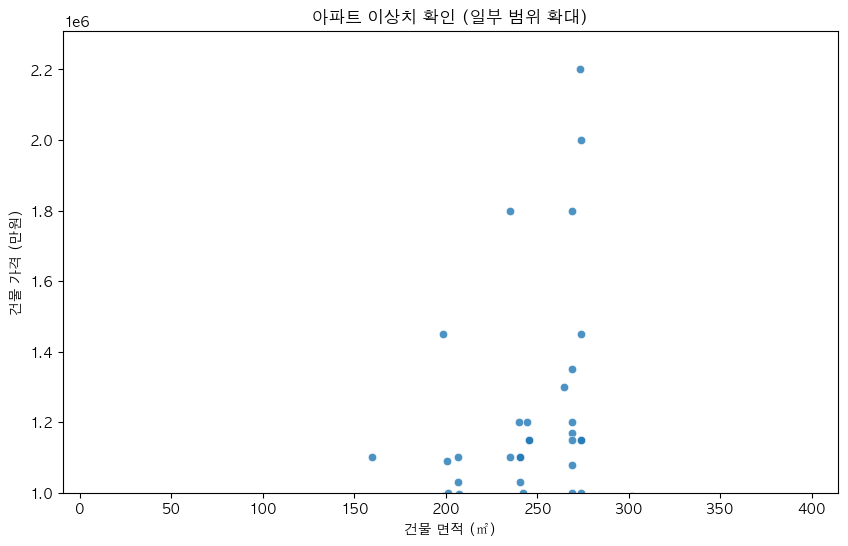

In [35]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=apt, x='ARCH_AREA', y='THING_AMT', alpha=0.8) # alpha로 겹친 점 확인

# y축: 금액 100억(1,000,000만원) 이상
# plt.xlim(area_q3,400)
plt.ylim(1.0e+06,)

plt.title('아파트 이상치 확인 (일부 범위 확대)')
plt.xlabel('건물 면적 (㎡)')
plt.ylabel('건물 가격 (만원)')

plt.show()

In [36]:
# 가격이 높게 형성된 매물 확인
high_price = apt.loc[apt['THING_AMT']>=1.0e+06,['CTRT_YEAR','STDG_NM','BLDG_NM','THING_AMT','ARCH_AREA','FLR','DCLR_SE']]
high_price

,CTRT_YEAR,STDG_NM,BLDG_NM,THING_AMT,ARCH_AREA,FLR,DCLR_SE
461762,2021,한남동,파르크한남,1200000,268.950,2.0,직거래
464987,2021,한남동,파르크한남,1170000,268.670,4.0,직거래
465689,2021,한남동,파르크한남,1150000,268.950,3.0,직거래
485513,2021,한남동,파르크한남,1080000,268.670,2.0,NaN
498770,2021,한남동,파르크한남,1000000,268.670,3.0,NaN
508949,2021,청담동,PH129,1000000,273.960,6.0,NaN
559369,2021,청담동,PH129,1150000,273.960,14.0,NaN
559373,2021,청담동,PH129,1150000,273.960,14.0,NaN
600073,2022,성수동1가,아크로서울포레스트,1300000,264.550,47.0,중개거래
619078,2022,한남동,한남더힐,1100000,240.310,3.0,중개거래


- 청담동 PH129 100평 100억 이상대(2021년부터) + 직거래의 경우 100억 이하로도 거래내역 확인 가능 

- 성수동1가 갤러리아포레 99평 2023년부터 100억 이상 확인
- 한남동 나인원한남 89평 2024년부터 100억이상 확인
    주택
- 반포동 아크로리버파크 71평 2025년 기준 95억 -> 95평의 경우 2023-2024년 기준 100억 이상 가능
- 성수동1가 아크로서울포레스트 75평 2024년부터 100억이상 확인,
- 한남동 파르크한남 96평 기준 2021년부터 100억 이상 확인

In [37]:
# 연립다세대 이상치 확인
# 연립다세대 데이터만 추출
yeon = df4.loc[df4['BLDG_USG']=='연립다세대'].copy() 

<class 'pandas.core.frame.DataFrame'>
Index: 279723 entries, 3 to 794603
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   CGG_CD     279723 non-null  int64  
 1   CGG_NM     279723 non-null  object 
 2   STDG_CD    279723 non-null  int64  
 3   STDG_NM    279723 non-null  object 
 4   BLDG_NM    279722 non-null  object 
 5   CTRT_DAY   279723 non-null  object 
 6   THING_AMT  279723 non-null  int64  
 7   ARCH_AREA  279723 non-null  float64
 8   LAND_AREA  279723 non-null  float64
 9   FLR        279723 non-null  float64
 10  RGHT_SE    0 non-null       object 
 11  ARCH_YR    279723 non-null  int64  
 12  BLDG_USG   279723 non-null  object 
 13  DCLR_SE    78082 non-null   object 
 14  CTRT_YEAR  279723 non-null  int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 34.1+ MB


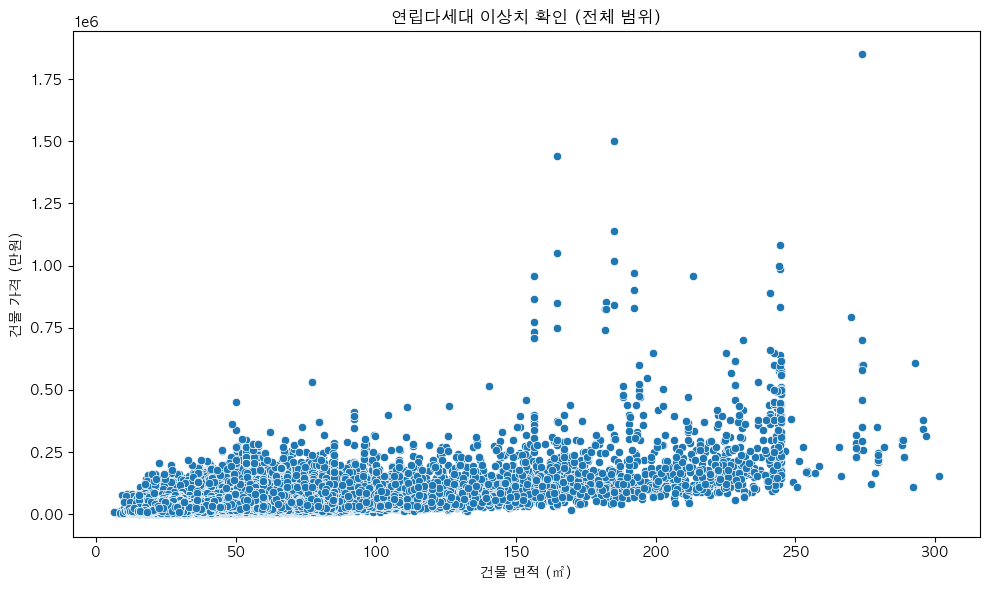

In [38]:
# 연립다세대
yeon = df4[df4['BLDG_USG']=='연립다세대']
yeon.info()

plt.figure(figsize=(10,6))
sns.scatterplot(data=yeon, x='ARCH_AREA', y='THING_AMT')

plt.title('연립다세대 이상치 확인 (전체 범위)')
plt.xlabel('건물 면적 (㎡)')
plt.ylabel('건물 가격 (만원)')

plt.tight_layout() 
plt.show()

In [39]:
yeon.info()

<class 'pandas.core.frame.DataFrame'>
Index: 279723 entries, 3 to 794603
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   CGG_CD     279723 non-null  int64  
 1   CGG_NM     279723 non-null  object 
 2   STDG_CD    279723 non-null  int64  
 3   STDG_NM    279723 non-null  object 
 4   BLDG_NM    279722 non-null  object 
 5   CTRT_DAY   279723 non-null  object 
 6   THING_AMT  279723 non-null  int64  
 7   ARCH_AREA  279723 non-null  float64
 8   LAND_AREA  279723 non-null  float64
 9   FLR        279723 non-null  float64
 10  RGHT_SE    0 non-null       object 
 11  ARCH_YR    279723 non-null  int64  
 12  BLDG_USG   279723 non-null  object 
 13  DCLR_SE    78082 non-null   object 
 14  CTRT_YEAR  279723 non-null  int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 34.1+ MB


In [40]:
yeon['FLR'].value_counts()

FLR
 2.0     70213
 3.0     61743
 4.0     48671
 1.0     33038
 5.0     31132
-1.0     20106
 6.0      9794
 7.0      1940
 8.0      1123
 9.0       703
 10.0      457
 11.0      295
 12.0      188
 13.0      120
 14.0       60
 15.0       36
 16.0       34
-2.0        26
 18.0       15
 17.0       13
 19.0        9
 20.0        6
-3.0         1
Name: count, dtype: int64

In [41]:
ten_yeon = yeon[yeon['FLR']==10]

In [42]:
# 7층 연립다세대 데이터 추출
seven_yeon = yeon[yeon['FLR']==7]

# 8층 연립다세대 데이터 추출
eight_yeon = yeon[yeon['FLR']==8]

In [43]:
seven_yeon[['CGG_NM','STDG_NM','BLDG_NM','CTRT_DAY','THING_AMT','ARCH_AREA','LAND_AREA','ARCH_YR']]

,CGG_NM,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,ARCH_YR
436,강서구,방화동,불루힐,2018-12-22,18800,27.38,14.50,2015
2145,마포구,동교동,더라움,2018-12-04,44000,36.15,16.70,2018
2343,중랑구,상봉동,청운명가,2018-12-03,22500,29.85,16.60,2017
2584,마포구,동교동,더라움,2018-12-01,42800,39.49,18.25,2018
3348,강서구,가양동,(184-5),2018-11-26,26500,27.68,12.59,2017
...,...,...,...,...,...,...,...,...
793569,은평구,불광동,해피하우스(281-16),2023-12-26,20000,19.77,7.16,2017
794038,강서구,등촌동,에스엠파크빌,2023-12-19,26000,24.64,15.01,2017
794177,금천구,시흥동,은연빌라트A,2023-12-16,33500,43.55,17.67,2016
794498,강서구,화곡동,에벤에셀,2023-12-05,48000,69.60,26.31,2009


In [44]:
eight_yeon[['CGG_NM','STDG_NM','BLDG_NM','CTRT_DAY','THING_AMT','ARCH_AREA','LAND_AREA','ARCH_YR']]

,CGG_NM,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,ARCH_YR
539,양천구,목동,목동토레스타워,2018-12-21,37800,34.91,16.79,2018
1214,강동구,천호동,다성이즈빌(169-6),2018-12-14,22000,19.14,6.61,2018
1837,중랑구,상봉동,포시즌빌,2018-12-07,21700,26.69,13.77,2016
3708,중랑구,면목동,스마트빌,2018-11-22,29000,50.35,19.42,2016
4255,동작구,사당동,사당휴브리지(206-127),2018-11-19,16700,12.42,8.27,2015
...,...,...,...,...,...,...,...,...
791224,영등포구,문래동1가,2030센터뷰,2024-01-12,40000,26.78,11.51,2023
791268,동작구,대방동,대방주상복합빌딩,2024-01-12,25900,24.31,6.14,2016
791460,강동구,천호동,美笑家,2024-01-11,37000,24.45,7.98,2023
791631,강동구,천호동,美笑家,2024-01-10,34000,25.23,8.24,2023


- 7층 8층의 경우 다세대주택과 오피스텔의 경계지점일 것으로 유추되어 집중조사해봄
- 그 결과, 건물용도의 경우 사용 비율에 따라 구분하고, 비율이 높은 용도를 표기한 것으로 유추됨.
- 따라서 보통 7층까지는 다세대주택 용도로 사용되는 것이 대부분이고, 
- 8층부터는 오피스텔과 다세대주택이 둘다 나타날 수 있는 경계선이라고 보임
   
    --> 너무 성급한 일반화? or too much detail?   

<class 'pandas.core.frame.DataFrame'>
Index: 86005 entries, 7 to 794602
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CGG_CD     86005 non-null  int64  
 1   CGG_NM     86005 non-null  object 
 2   STDG_CD    86005 non-null  int64  
 3   STDG_NM    86005 non-null  object 
 4   BLDG_NM    85943 non-null  object 
 5   CTRT_DAY   86005 non-null  object 
 6   THING_AMT  86005 non-null  int64  
 7   ARCH_AREA  86005 non-null  float64
 8   LAND_AREA  86005 non-null  float64
 9   FLR        86005 non-null  float64
 10  RGHT_SE    0 non-null      object 
 11  ARCH_YR    86005 non-null  int64  
 12  BLDG_USG   86005 non-null  object 
 13  DCLR_SE    33171 non-null  object 
 14  CTRT_YEAR  86005 non-null  int64  
dtypes: float64(3), int64(5), object(7)
memory usage: 10.5+ MB


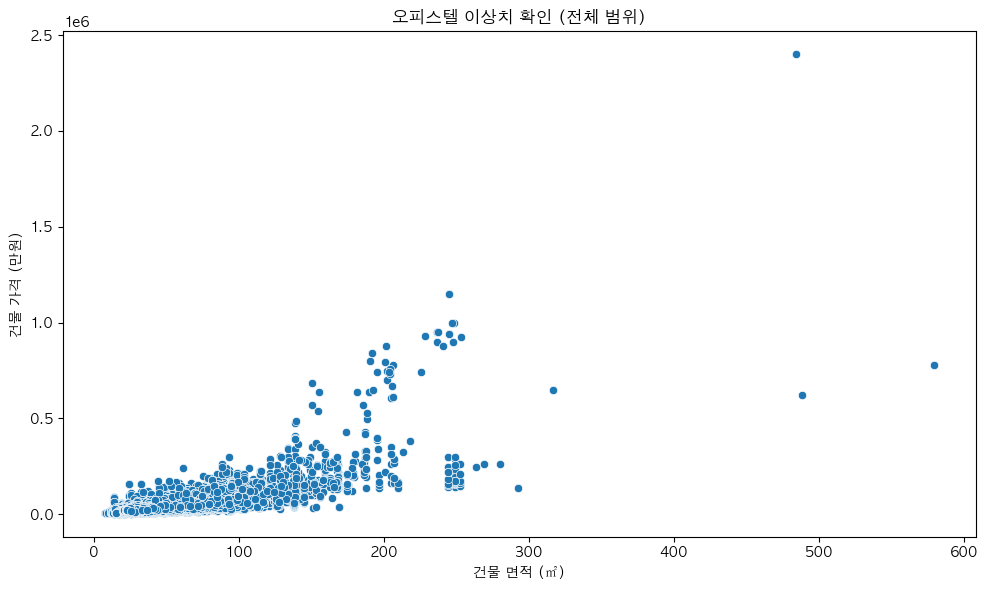

In [45]:
# 오피스텔 이상치 확인
office = df4[df4['BLDG_USG']=='오피스텔']
office.info()

plt.figure(figsize=(10,6))
sns.scatterplot(data=office, x='ARCH_AREA', y='THING_AMT')

plt.title('오피스텔 이상치 확인 (전체 범위)')
plt.xlabel('건물 면적 (㎡)')
plt.ylabel('건물 가격 (만원)')

plt.tight_layout() 
plt.show()

In [46]:
weird_office = office.loc[office['ARCH_AREA']>300,['STDG_NM','BLDG_NM','CTRT_DAY','THING_AMT','ARCH_AREA','FLR']]
weird_office

,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,FLR
263283,청담동,피엔폴루스,2019-03-27,650000,316.88,22.0
331593,동자동,트윈시티 남산,2020-08-19,621860,488.54,2.0
605591,한강로2가,용산 토투벨리,2022-08-16,780000,579.27,14.0
657965,신천동,롯데월드타워앤드롯데월드몰,2023-11-23,2400000,483.96,68.0


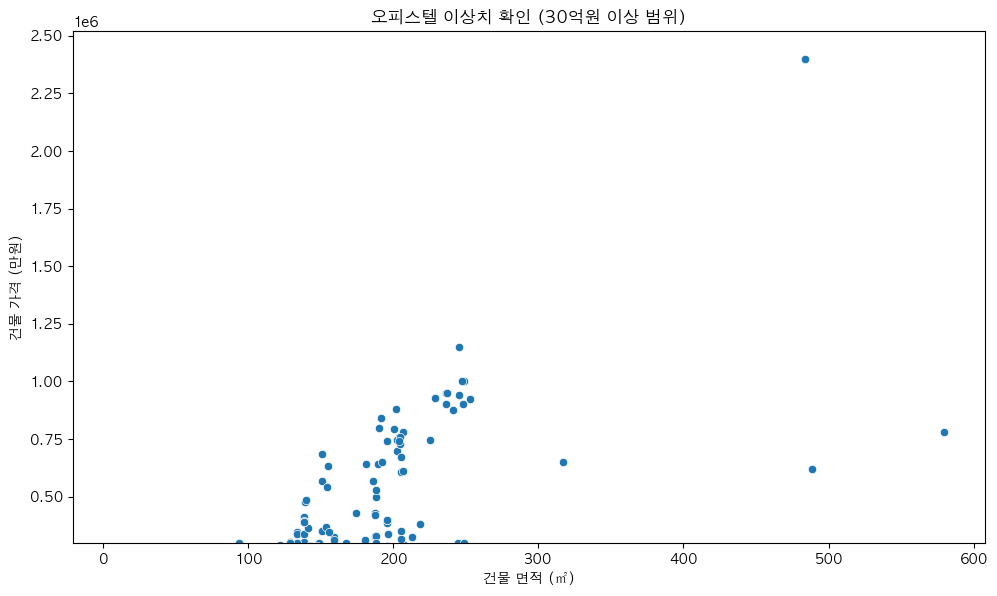

In [47]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=office, x='ARCH_AREA', y='THING_AMT')
plt.tight_layout() 
plt.ylim(0.3e+06,)

plt.title('오피스텔 이상치 확인 (30억원 이상 범위)')
plt.xlabel('건물 면적 (㎡)')
plt.ylabel('건물 가격 (만원)')

plt.show()

In [48]:
office[office['THING_AMT']>0.3e+06]

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
59375,11680,강남구,10400,청담동,피엔폴루스,2018-07-20,385000,195.43,267.79,17.0,NaN,2007,오피스텔,NaN,2018
170884,11710,송파구,10200,신천동,롯데월드타워앤드롯데월드몰,2019-11-08,498060,188.04,310.55,48.0,NaN,9999,오피스텔,NaN,2019
179083,11710,송파구,10200,신천동,롯데월드타워앤드롯데월드몰,2019-10-25,608130,205.01,335.69,49.0,NaN,9999,오피스텔,NaN,2019
205961,11710,송파구,10200,신천동,롯데월드타워앤드롯데월드몰,2019-09-02,1150000,244.94,402.50,65.0,NaN,9999,오피스텔,NaN,2019
250690,11650,서초구,10800,서초동,부띠크 모나코,2019-05-14,325000,212.91,288.29,27.0,NaN,2008,오피스텔,NaN,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
760343,11710,송파구,10200,신천동,롯데월드타워앤드롯데월드몰,2024-05-28,740000,203.84,333.77,55.0,NaN,9999,오피스텔,중개거래,2024
763586,11680,강남구,10400,청담동,피엔폴루스,2024-05-16,395000,138.56,189.85,11.0,NaN,2007,오피스텔,중개거래,2024
774882,11710,송파구,10200,신천동,롯데월드타워앤드롯데월드몰,2024-04-01,939500,245.03,400.09,67.0,NaN,9999,오피스텔,직거래,2024
790360,11680,강남구,10400,청담동,피엔폴루스,2024-01-17,390000,138.56,189.85,19.0,NaN,2007,오피스텔,중개거래,2024


- 청담동 피엔폴루스 2019년 316제곱미터 65억 거래 확인 (https://hogangnono.com/apt/bg93c/0/7)
- 동자동 트윈시티 남산 2020년 488제곱미터 확인되지 않음. 실제 매물의 경우 2층 25.37제곱미터로 확인 --> 이상치 
- 한강로2가 용산 토투벨리 2022년 341평 78억 실제 거래 데이터 확인 (https://hogangnono.com/apt/b8N50/0/14)
- 신천동 롯데월드타워앤드롯데월드몰 2023년 371평 240억 실제 거래 데이터 확인 (https://hogangnono.com/apt/dGZ68/0/148)

In [49]:

# 동자동 트윈시티 남산 매물을 이상치로 판단하고 제거
target = df4[(df4['BLDG_NM']=='트윈시티 남산') & (df4['ARCH_AREA']==488.54)]

df4 = df4.drop(target.index)

# 입주권 제거
df4 = df4[df4['RGHT_SE'] != '입주권'].copy()

print(len(df4))

789955


In [50]:
df4['QUARTER'] = df4['CTRT_DAY'].astype(str).str[5:7]
df4['QUARTER_INT'] = df4['QUARTER'].astype(int)
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 789955 entries, 0 to 794605
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   CGG_CD       789955 non-null  int64  
 1   CGG_NM       789955 non-null  object 
 2   STDG_CD      789955 non-null  int64  
 3   STDG_NM      789955 non-null  object 
 4   BLDG_NM      736793 non-null  object 
 5   CTRT_DAY     789955 non-null  object 
 6   THING_AMT    789955 non-null  int64  
 7   ARCH_AREA    789955 non-null  float64
 8   LAND_AREA    629015 non-null  float64
 9   FLR          736844 non-null  float64
 10  RGHT_SE      2389 non-null    object 
 11  ARCH_YR      789955 non-null  int64  
 12  BLDG_USG     789955 non-null  object 
 13  DCLR_SE      212915 non-null  object 
 14  CTRT_YEAR    789955 non-null  int64  
 15  QUARTER      789955 non-null  object 
 16  QUARTER_INT  789955 non-null  int64  
dtypes: float64(3), int64(6), object(8)
memory usage: 108.5+ MB


In [51]:
# 함수 정의 (매개변수 x는 행의 특정 값)
def get_QUARTER(x):
    if x < 4:
        return 'Q1'
    elif x < 7:
        return 'Q2'
    elif x < 10:
        return 'Q3'
    else:
        return 'Q4'

# 2. apply 함수를 이용해 QUARTER_int 컬럼의 모든 값에 적용
df4['QUARTER'] = df4['CTRT_YEAR'].astype(str) + df4['QUARTER_INT'].apply(get_QUARTER)

df4['QUARTER']

0         2019Q2
1         2019Q1
2         2019Q1
3         2019Q1
4         2019Q1
           ...  
794601    2023Q4
794602    2023Q4
794603    2023Q4
794604    2023Q4
794605    2023Q4
Name: QUARTER, Length: 789955, dtype: object

In [52]:
# 2024Q4 데이터 제거
remove = df4[df4['QUARTER']=='2024Q4']
df4 = df4.drop(remove.index)

# 잘 제거 되었는지 확인
df4['QUARTER'].value_counts().sort_index(ascending=False)

QUARTER
2024Q3    27308
2024Q2    26359
2024Q1    17811
2023Q4    14229
2023Q3    19434
2023Q2    18922
2023Q1    13899
2022Q4     8809
2022Q3    12130
2022Q2    22515
2022Q1    16965
2021Q4    22317
2021Q3    31859
2021Q2    37432
2021Q1    36718
2020Q4    39455
2020Q3    42004
2020Q2    46573
2020Q1    38056
2019Q4    55195
2019Q3    38335
2019Q2    29180
2019Q1    17094
2018Q4    20805
2018Q3    50140
2018Q2    31926
2018Q1    53613
Name: count, dtype: int64

In [53]:
print(f"상위 1.5% 제거 전 행 개수: {len(df4)}")

상위 1.5% 제거 전 행 개수: 789083


In [54]:
# 건물용도별 데이터프레임 분리
df_a = df4[df4['BLDG_USG']=='단독다가구']
df_b = df4[df4['BLDG_USG']=='아파트']
df_c = df4[df4['BLDG_USG']=='연립다세대']
df_d = df4[df4['BLDG_USG']=='오피스텔']

In [55]:
# 1. 처리할 데이터프레임과 이름을 리스트로 관리
dfs = [df_a, df_b, df_c, df_d]
cleaned_dfs = []

for target_df in dfs:
    # 2. 상위 1.5% (0.985 분위수) 임계값 계산
    threshold = target_df['THING_AMT'].quantile(0.985)
    
    # 3. 임계값 이하의 데이터만 추출 (상위 1.5% 제거)
    under_985 = target_df[target_df['THING_AMT'] <= threshold].copy()
    cleaned_dfs.append(under_985)

# 4. 하나의 데이터프레임으로 다시 통합
df5 = pd.concat(cleaned_dfs).reset_index(drop=True)

print(f"상위 1.5% 제거 후 행 개수: {len(df5)}")

상위 1.5% 제거 후 행 개수: 777307


In [56]:
df5

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR,QUARTER,QUARTER_INT
0,11530,구로구,10800,오류동,NaN,2018-12-31,73000,197.40,146.00,NaN,NaN,1990,단독다가구,NaN,2018,2018Q4,12
1,11215,광진구,10100,중곡동,NaN,2018-12-31,102000,89.09,131.20,NaN,NaN,1973,단독다가구,NaN,2018,2018Q4,12
2,11560,영등포구,10900,영등포동8가,NaN,2018-12-29,88700,36.36,91.60,NaN,NaN,1945,단독다가구,NaN,2018,2018Q4,12
3,11230,동대문구,10900,휘경동,NaN,2018-12-28,95000,140.22,112.00,NaN,NaN,1991,단독다가구,NaN,2018,2018Q4,12
4,11620,관악구,10200,신림동,NaN,2018-12-27,56500,179.46,127.00,NaN,NaN,1988,단독다가구,NaN,2018,2018Q4,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777302,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,38.70,11.0,NaN,2023,오피스텔,중개거래,2023,2023Q4,12
777303,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,38.70,15.0,NaN,2023,오피스텔,중개거래,2023,2023Q4,12
777304,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,38.70,16.0,NaN,2023,오피스텔,중개거래,2023,2023Q4,12
777305,11650,서초구,10800,서초동,벨라채 오피스텔,2023-12-04,24000,36.64,52.05,4.0,NaN,2003,오피스텔,중개거래,2023,2023Q4,12


In [57]:
# 건축년식 파생컬럼
df5['CTRT_BLDG_AGE'] = df5['CTRT_YEAR'] - df5['ARCH_YR']

In [58]:
# 단위면적 당 가격(만원) 파생컬럼 생성
df5['AMT_PER_AREA'] = df5['THING_AMT'] / df5['ARCH_AREA']

In [59]:
# 평당가 구하기
# 전용면적(평수): 부동산에서 순수하게 거주할 수 있는 면적
# df 데이터에서 나타내는 건물면적: 전용면적
# 1평은 약 **3.3058$m^2$**에 해당
# 평당가 = 건물가격 / 건물면적 * 3.3058
df5['AMT_PER_PYEONG'] = df5['THING_AMT'] / df5['ARCH_AREA'] * (3.3058)

In [60]:
df5.to_csv('data/real_estate_clean_v2.csv',index=False,encoding='cp949')

In [61]:
df6 = pd.read_csv('data/real_estate_clean_v2.csv', encoding='cp949')
df6

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_24657/519144003.py:1: DtypeWarning: Columns (10,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df6 = pd.read_csv('data/real_estate_clean_v2.csv', encoding='cp949')


,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR,QUARTER,QUARTER_INT,CTRT_BLDG_AGE,AMT_PER_AREA,AMT_PER_PYEONG
0,11530,구로구,10800,오류동,NaN,2018-12-31,73000,197.40,146.00,NaN,NaN,1990,단독다가구,NaN,2018,2018Q4,12,28,369.807497,1222.509625
1,11215,광진구,10100,중곡동,NaN,2018-12-31,102000,89.09,131.20,NaN,NaN,1973,단독다가구,NaN,2018,2018Q4,12,45,1144.909642,3784.842294
2,11560,영등포구,10900,영등포동8가,NaN,2018-12-29,88700,36.36,91.60,NaN,NaN,1945,단독다가구,NaN,2018,2018Q4,12,73,2439.493949,8064.479098
3,11230,동대문구,10900,휘경동,NaN,2018-12-28,95000,140.22,112.00,NaN,NaN,1991,단독다가구,NaN,2018,2018Q4,12,27,677.506775,2239.701897
4,11620,관악구,10200,신림동,NaN,2018-12-27,56500,179.46,127.00,NaN,NaN,1988,단독다가구,NaN,2018,2018Q4,12,30,314.833389,1040.776218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777302,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,38.70,11.0,NaN,2023,오피스텔,중개거래,2023,2023Q4,12,0,904.003444,2988.454585
777303,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,38.70,15.0,NaN,2023,오피스텔,중개거래,2023,2023Q4,12,0,904.003444,2988.454585
777304,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,38.70,16.0,NaN,2023,오피스텔,중개거래,2023,2023Q4,12,0,904.003444,2988.454585
777305,11650,서초구,10800,서초동,벨라채 오피스텔,2023-12-04,24000,36.64,52.05,4.0,NaN,2003,오피스텔,중개거래,2023,2023Q4,12,20,655.021834,2165.371179


In [62]:
df6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777307 entries, 0 to 777306
Data columns (total 20 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CGG_CD          777307 non-null  int64  
 1   CGG_NM          777307 non-null  object 
 2   STDG_CD         777307 non-null  int64  
 3   STDG_NM         777307 non-null  object 
 4   BLDG_NM         724951 non-null  object 
 5   CTRT_DAY        777307 non-null  object 
 6   THING_AMT       777307 non-null  int64  
 7   ARCH_AREA       777307 non-null  float64
 8   LAND_AREA       617714 non-null  float64
 9   FLR             725003 non-null  float64
 10  RGHT_SE         2374 non-null    object 
 11  ARCH_YR         777307 non-null  int64  
 12  BLDG_USG        777307 non-null  object 
 13  DCLR_SE         206848 non-null  object 
 14  CTRT_YEAR       777307 non-null  int64  
 15  QUARTER         777307 non-null  object 
 16  QUARTER_INT     777307 non-null  int64  
 17  CTRT_BLDG_

# Analysis

In [63]:
df6

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR,QUARTER,QUARTER_INT,CTRT_BLDG_AGE,AMT_PER_AREA,AMT_PER_PYEONG
0,11530,구로구,10800,오류동,NaN,2018-12-31,73000,197.40,146.00,NaN,NaN,1990,단독다가구,NaN,2018,2018Q4,12,28,369.807497,1222.509625
1,11215,광진구,10100,중곡동,NaN,2018-12-31,102000,89.09,131.20,NaN,NaN,1973,단독다가구,NaN,2018,2018Q4,12,45,1144.909642,3784.842294
2,11560,영등포구,10900,영등포동8가,NaN,2018-12-29,88700,36.36,91.60,NaN,NaN,1945,단독다가구,NaN,2018,2018Q4,12,73,2439.493949,8064.479098
3,11230,동대문구,10900,휘경동,NaN,2018-12-28,95000,140.22,112.00,NaN,NaN,1991,단독다가구,NaN,2018,2018Q4,12,27,677.506775,2239.701897
4,11620,관악구,10200,신림동,NaN,2018-12-27,56500,179.46,127.00,NaN,NaN,1988,단독다가구,NaN,2018,2018Q4,12,30,314.833389,1040.776218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777302,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,38.70,11.0,NaN,2023,오피스텔,중개거래,2023,2023Q4,12,0,904.003444,2988.454585
777303,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,38.70,15.0,NaN,2023,오피스텔,중개거래,2023,2023Q4,12,0,904.003444,2988.454585
777304,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.23,38.70,16.0,NaN,2023,오피스텔,중개거래,2023,2023Q4,12,0,904.003444,2988.454585
777305,11650,서초구,10800,서초동,벨라채 오피스텔,2023-12-04,24000,36.64,52.05,4.0,NaN,2003,오피스텔,중개거래,2023,2023Q4,12,20,655.021834,2165.371179


In [64]:
df6.shape

(777307, 20)

In [65]:
seoul_avg = (
    df6
    .groupby('CTRT_YEAR')['THING_AMT']
    .mean()
    .reset_index()
)

avg_price = (
    df6.groupby(['CTRT_YEAR', 'BLDG_USG'])['THING_AMT']
    .mean()
    .reset_index()
)

### 서울시 부동산 시장의 전체적인 모습

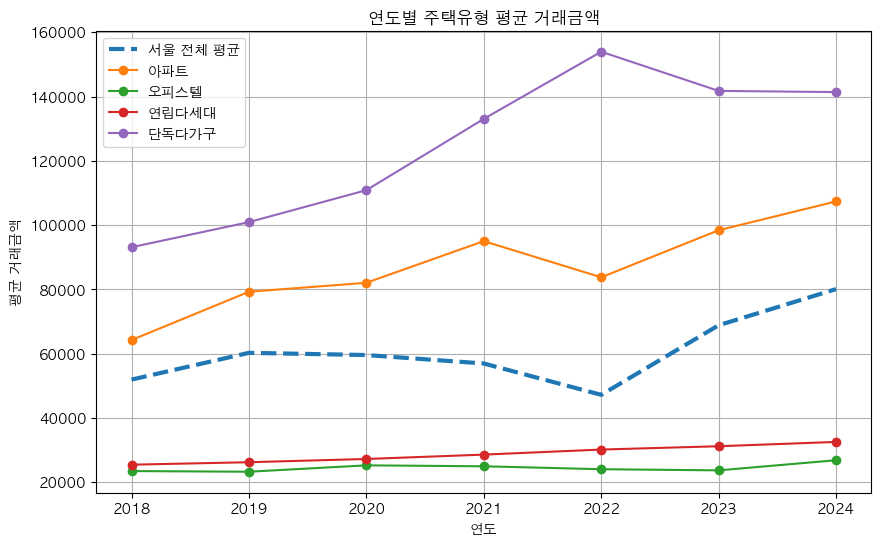

In [66]:
plt.figure(figsize=(10, 6))

plt.plot(
    seoul_avg['CTRT_YEAR'],
    seoul_avg['THING_AMT'],
    linestyle='--',
    linewidth=3,
    label='서울 전체 평균'
)

plt.plot(
    avg_price[avg_price['BLDG_USG'] == '아파트']['CTRT_YEAR'],
    avg_price[avg_price['BLDG_USG'] == '아파트']['THING_AMT'],
    marker='o',
    label='아파트'
)

plt.plot(
    avg_price[avg_price['BLDG_USG'] == '오피스텔']['CTRT_YEAR'],
    avg_price[avg_price['BLDG_USG'] == '오피스텔']['THING_AMT'],
    marker='o',
    label='오피스텔'
)

plt.plot(
    avg_price[avg_price['BLDG_USG'] == '연립다세대']['CTRT_YEAR'],
    avg_price[avg_price['BLDG_USG'] == '연립다세대']['THING_AMT'],
    marker='o',
    label='연립다세대'
)

plt.plot(
    avg_price[avg_price['BLDG_USG'] == '단독다가구']['CTRT_YEAR'],
    avg_price[avg_price['BLDG_USG'] == '단독다가구']['THING_AMT'],
    marker='o',
    label='단독다가구'
)

plt.title('연도별 주택유형 평균 거래금액')
plt.xlabel('연도')
plt.ylabel('평균 거래금액')
plt.legend()
plt.grid(True)

plt.show()

추세 파악을 위해 연도를 분기별로, 평균 거래금액을 평당 가격으로 세분화 시켜서 확인하기

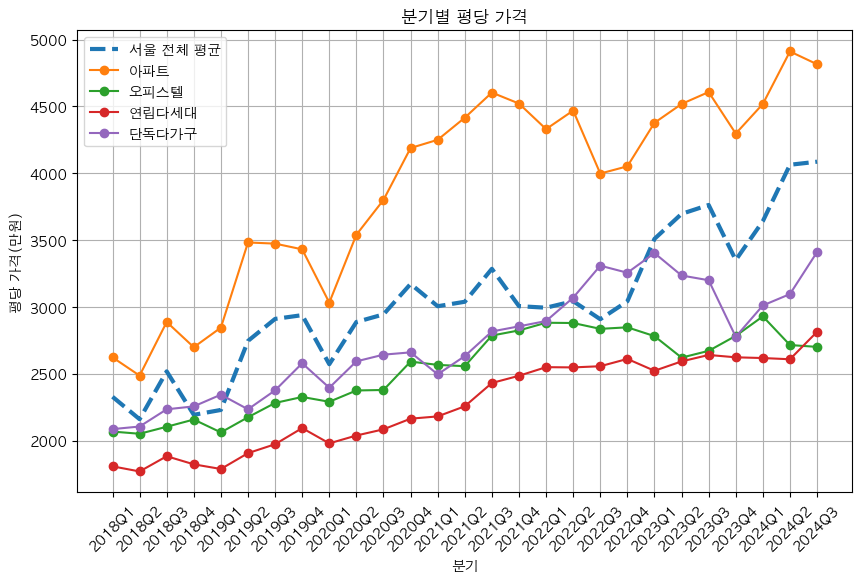

In [67]:
seoul_qtr = (
    df6
    .groupby('QUARTER')['AMT_PER_PYEONG']
    .mean()
    .reset_index()
)

price_qtr = (
    df6.groupby(['QUARTER', 'BLDG_USG'])['AMT_PER_PYEONG']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    seoul_qtr['QUARTER'],
    seoul_qtr['AMT_PER_PYEONG'],
    linestyle='--',
    linewidth=3,
    label='서울 전체 평균'
)

plt.plot(
    price_qtr[price_qtr['BLDG_USG'] == '아파트']['QUARTER'],
    price_qtr[price_qtr['BLDG_USG'] == '아파트']['AMT_PER_PYEONG'],
    marker='o',
    label='아파트'
)

plt.plot(
    price_qtr[price_qtr['BLDG_USG'] == '오피스텔']['QUARTER'],
    price_qtr[price_qtr['BLDG_USG'] == '오피스텔']['AMT_PER_PYEONG'],
    marker='o',
    label='오피스텔'
)

plt.plot(
    price_qtr[price_qtr['BLDG_USG'] == '연립다세대']['QUARTER'],
    price_qtr[price_qtr['BLDG_USG'] == '연립다세대']['AMT_PER_PYEONG'],
    marker='o',
    label='연립다세대'
)

plt.plot(
    price_qtr[price_qtr['BLDG_USG'] == '단독다가구']['QUARTER'],
    price_qtr[price_qtr['BLDG_USG'] == '단독다가구']['AMT_PER_PYEONG'],
    marker='o',
    label='단독다가구'
)

plt.title('분기별 평당 가격')
plt.xlabel('분기')
plt.ylabel('평당 가격(만원)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

서울시 전체 데이터의 평균과 중앙값을 비교, 거래량을 동반한 금액 추세 변화인지 파악해보기

In [68]:
seoul_qtr_des = ( 
    df6
    .groupby('QUARTER')['AMT_PER_PYEONG']
    .agg(mean_price='mean', median_price='median', trade_cnt='count')
    .reset_index() .sort_values('QUARTER') 
)

seoul_qtr_des['mean_ratio'] = ( 
    seoul_qtr_des['mean_price']
      .pct_change() * 100 

)
seoul_qtr_des['median_ratio'] = ( 
    seoul_qtr_des['median_price'] 
    .pct_change() * 100 

)
seoul_qtr_des['trade_ratio'] = ( 
    seoul_qtr_des['trade_cnt'] 
    .pct_change() * 100 
)

seoul_qtr_des[['mean_ratio', 'median_ratio', 'trade_ratio']] = (
    seoul_qtr_des[['mean_ratio', 'median_ratio', 'trade_ratio']]
    .fillna(0)
)

upper = seoul_qtr_des['mean_ratio'].quantile(0.9)
lower = seoul_qtr_des['mean_ratio'].quantile(0.1)

big_move_seoul = seoul_qtr_des[
    (seoul_qtr_des['mean_ratio'] >= upper) | 
    (seoul_qtr_des['mean_ratio'] <= lower)
]

big_move_seoul = big_move_seoul['QUARTER'].values.astype('str').tolist()

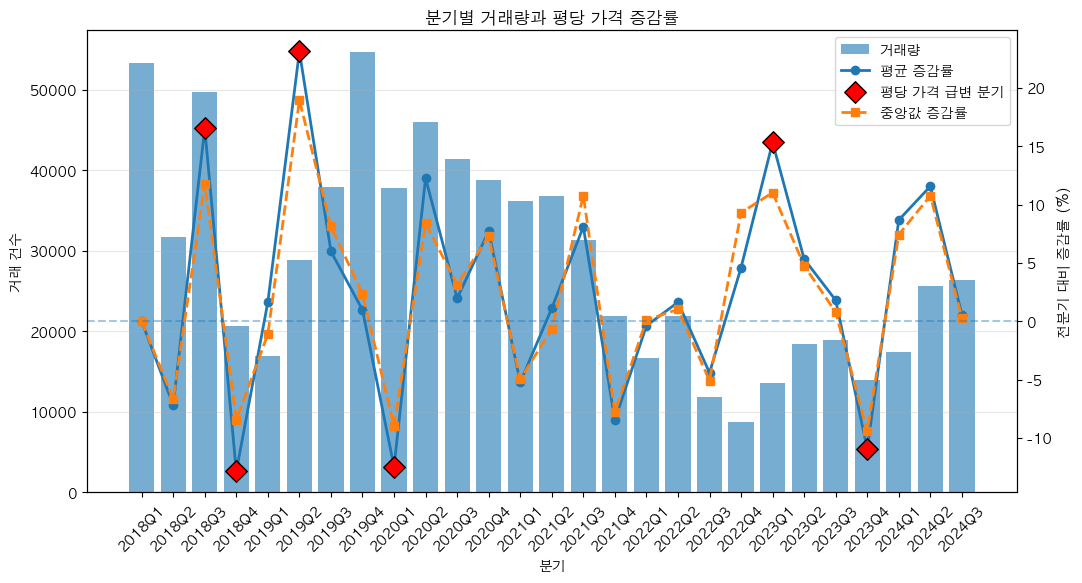

In [69]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# -------------------------
# 1. 거래량 (barplot, 왼쪽 y축)
# -------------------------
ax1.bar(
    seoul_qtr_des['QUARTER'],
    seoul_qtr_des['trade_cnt'],
    alpha=0.6,
    label='거래량'
)

ax1.set_xlabel('분기')
ax1.set_ylabel('거래 건수')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# -------------------------
# 2. 증감률 (lineplot, 오른쪽 y축)
# -------------------------
ax2 = ax1.twinx()

ax2.plot(
    seoul_qtr_des['QUARTER'],
    seoul_qtr_des['mean_ratio'],
    marker='o',
    linewidth=2,
    label='평균 증감률'
)

highlight_df = seoul_qtr_des[
    seoul_qtr_des['QUARTER'].isin(big_move_seoul)
]

ax2.scatter(
    highlight_df['QUARTER'],
    highlight_df['mean_ratio'],
    s=120,
    marker='D',
    color='red',
    edgecolor='black',
    zorder=5,
    label='평당 가격 급변 분기'
)

ax2.plot(
    seoul_qtr_des['QUARTER'],
    seoul_qtr_des['median_ratio'],
    marker='s',
    linewidth=2,
    linestyle='--',
    label='중앙값 증감률'
)

ax2.set_ylabel('전분기 대비 증감률 (%)')
ax2.axhline(0, linestyle='--', alpha=0.4)

# -------------------------
# 3. 범례 합치기
# -------------------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax2.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper right'
)

# -------------------------
# 4. 기타
# -------------------------
plt.title('분기별 거래량과 평당 가격 증감률')

plt.show()


“평균과 중앙값의 증감률이 거의 동일한 형태를 보였으며,
이는 일부 고가 거래에 의한 평균 왜곡이 아니라
가격 분포 전반이 이동했음을 의미한다.
따라서 해당 시기의 가격 변동은
통계적 노이즈보다는 실제 시장 변화로 해석할 수 있다.”

분기별 가격 증감률과 거래량을 함께 비교한 결과, 일부 가격 급변 구간은 거래량 급증·급감과 동반되었으나, 특정 분기에서는 거래량 변화 없이도 가격이 급격히 변동하는 현상이 관측되었다. 이는 해당 시기의 가격 변동이 단기 수급 요인보다는 정책·금리 등 외부 거시 요인의 영향을 받았을 가능성을 시사한다.

예시)
1. 2018년 3분기 (급등): 거래량 동반한 '막차 타기'
- 현상: 평균 증감률이 약 17%에 달하며 급격히 상승했습니다.
- 거래량과의 관계: 일시적 폭발 후 급감. 9.13 대책 발표 직전까지 규제를 피하려는 추격 매수세가 강하게 붙으며 거래량이 동반되었습니다.
- 주요 원인: 9.13 주택시장 안정대책: 종부세 인상, 다주택자 대출 금지 등 역대급 고강도 규제가 발표되기 직전의 '불장'이었습니다. 양도세 중과 시행(4월) 이후 매물 잠김 현상과 서울 신축 공급 부족 우려가 겹치며 가격이 폭등했습니다.

2. 2018년 4분기 (급락): '거래 절벽'에 의한 가격 조정
- 현상: 직전 분기 폭등을 뒤로하고 증감률이 -13% 수준으로 수직 낙하했습니다.
- 거래량과의 관계: 거래 실종. 9.13 대책의 강력한 대출 규제로 인해 매수 심리가 완전히 꺾이며 거래량이 전년 대비 절반 가까이 줄어든 '거래 절벽' 구간입니다.
- 판단: 건전한 하락이라기보다 강력한 **정부 규제(외부 요인)**에 의해 시장이 즉각적으로 냉각된 사례입니다.

3. 2019년 2분기 (급등): '강남 재건축' 중심의 반등
- 현상: 평균 증감률이 다시 20% 이상으로 치솟으며 전 고점을 돌파하려는 움직임을 보였습니다.
- 거래량과의 관계: 완만한 회복. 대출 규제 적응기와 금리 인하 기대감이 맞물리며 강남권 재건축 단지를 중심으로 거래가 재개되었습니다.
- 주요 원인: 3기 신도시 발표 등으로 인한 공급 불안 심리와 저금리 기조 유지가 시장을 다시 자극했습니다.

4. 2020년 1분기 (급락): 코로나19 초기 쇼크와 규제
- 현상: 증감률이 다시 -12% 수준으로 하락했습니다.
- 거래량과의 관계: 심리 위축. 코로나19 팬데믹 초기 발생으로 인한 경제 불확실성과 12.16 대책(15억 초과 대출 금지)의 영향이 본격화되었습니다.
- 판단: 질병이라는 예측 불가능한 외부 변수와 강력한 대출 규제가 결합된 구간입니다.

5. 2023년 1분기 (반등): '정책 금융'이 살린 심폐소생
- 현상: 2022년 하락세를 멈추고 15% 이상 급등했습니다.
- 거래량과의 관계: 인위적 거래량 회복. 하락장에서 멈춰있던 거래가 정책 자금 투입으로 인해 살아난 구간입니다.
- 주요 원인: 특례보금자리론 출시: 9억원 이하 주택에 대해 DSR 규제 없이 저금리 대출을 실행하면서 1분기 서울 아파트 거래량이 4년 만에 최대치를 기록했습니다.
강남 3구 등을 제외한 규제지역 대거 해제 등 정부의 연착륙 정책이 주효했습니다.

6. 2023년 4분기 (하락): '대출 중단'과 고금리의 역습
- 현상: 증감률이 다시 마이너스(-11%)로 전환되었습니다.
- 거래량과의 관계: 다시 거래 절벽. 1분기에 상승을 주도했던 정책 동력이 상실되며 거래량이 다시 줄어들었습니다.
- 주요 원인: 특례보금자리론 일반형 중단: 6~9억원대 대출이 막히자마자 시장 수요가 급격히 증발했습니다.
고금리 장기화 우려로 인해 '영끌' 심리가 위축된 구간입니다.

### 페르소나1

In [70]:
qtr_price = ( 
    df6
    .groupby(['QUARTER', 'BLDG_USG'])['AMT_PER_PYEONG']
    .agg( mean_price='mean', median_price='median', trade_cnt='count' )
    .reset_index() .sort_values('QUARTER') 
)

qtr_price['mean_ratio'] = (
    qtr_price.groupby('BLDG_USG')['mean_price']
    .pct_change() * 100
)

qtr_price['median_ratio'] = (
    qtr_price.groupby('BLDG_USG')['median_price']
    .pct_change() * 100
)

qtr_price['trade_ratio'] = (
    qtr_price.groupby('BLDG_USG')['trade_cnt']
    .pct_change() * 100
)

qtr_price[['mean_ratio', 'median_ratio', 'trade_ratio']] = (
    qtr_price[['mean_ratio', 'median_ratio', 'trade_ratio']]
    .fillna(0)
)

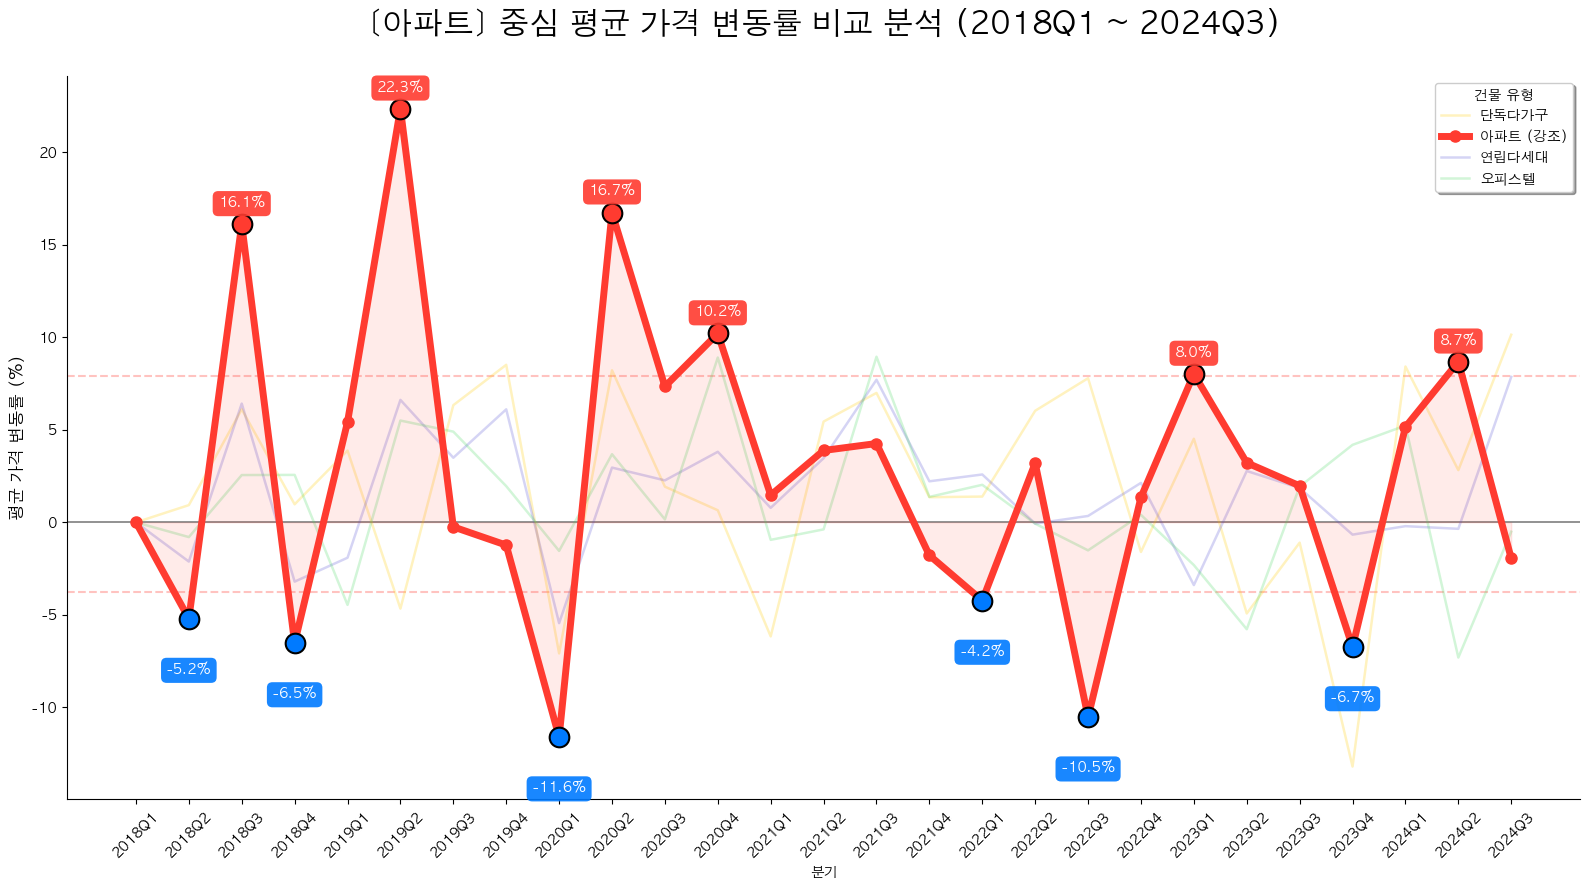

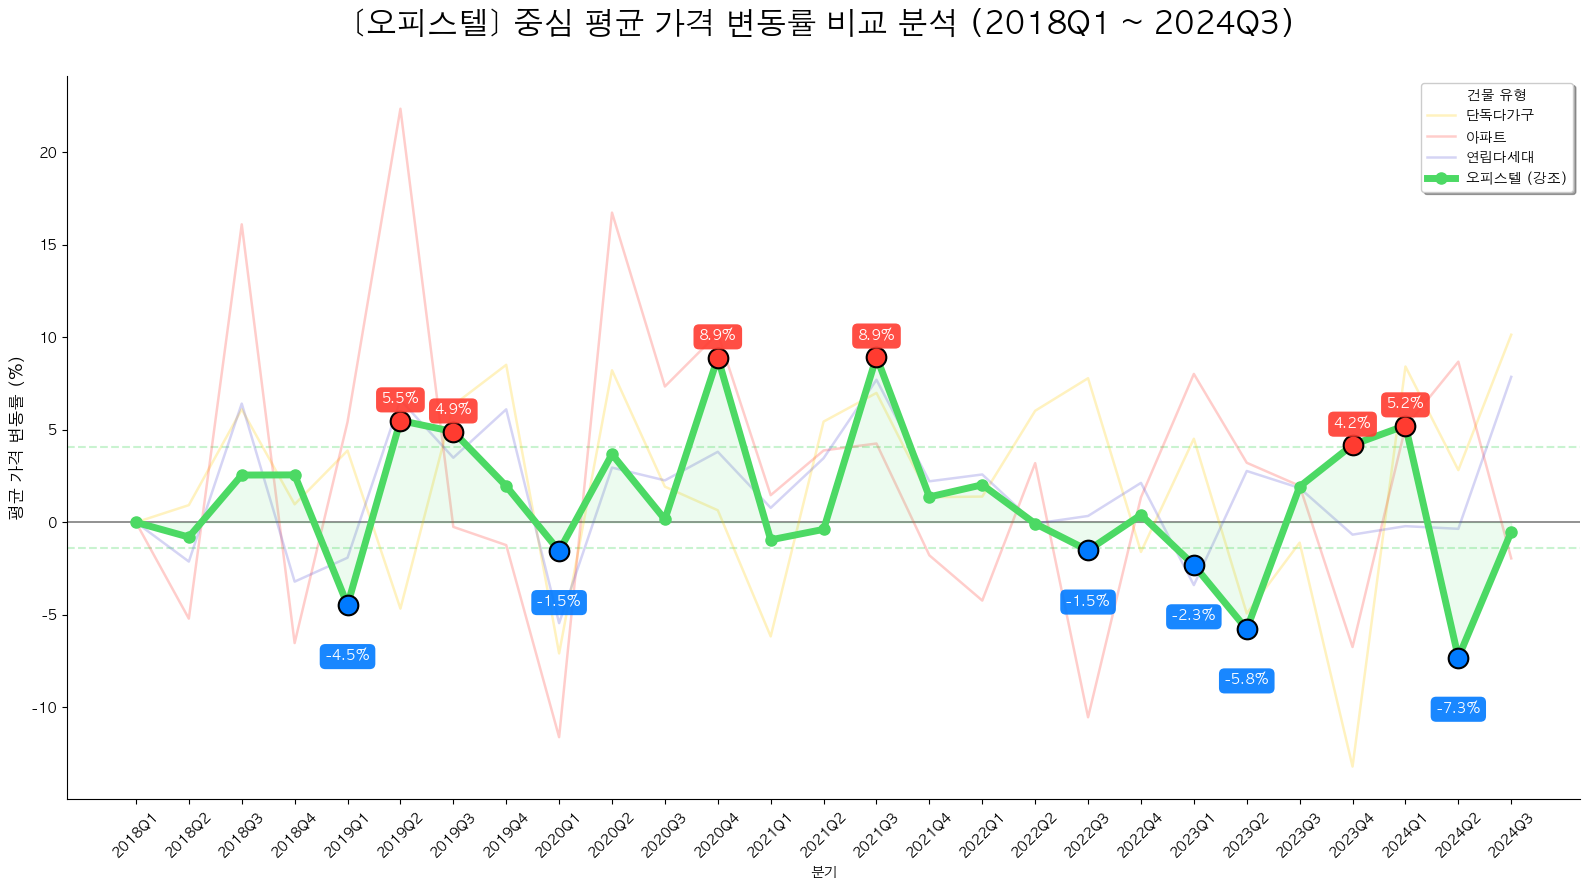

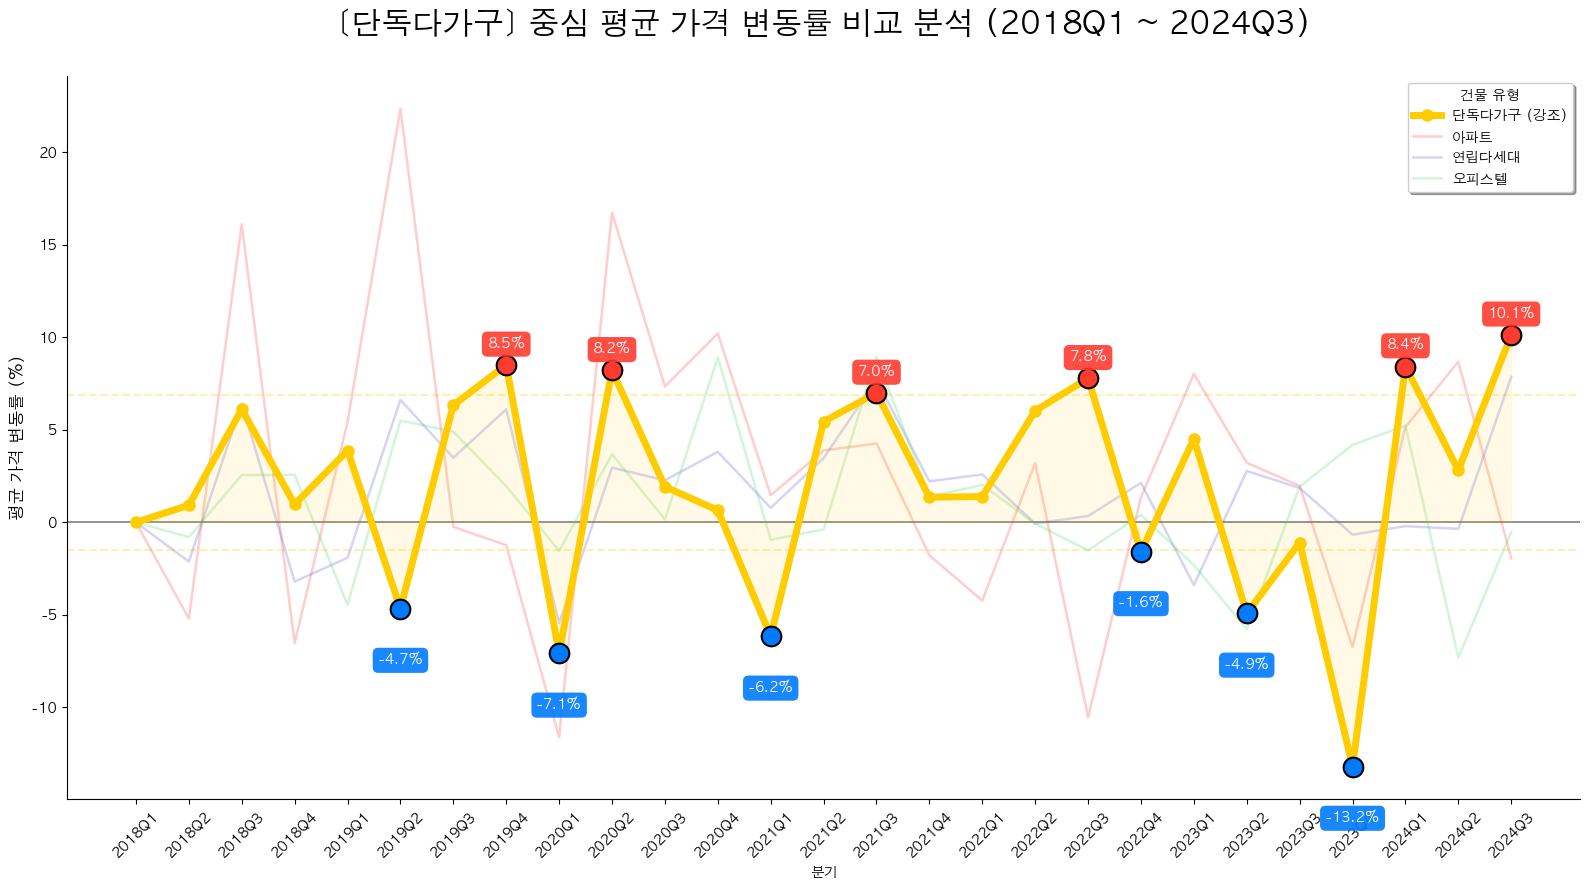

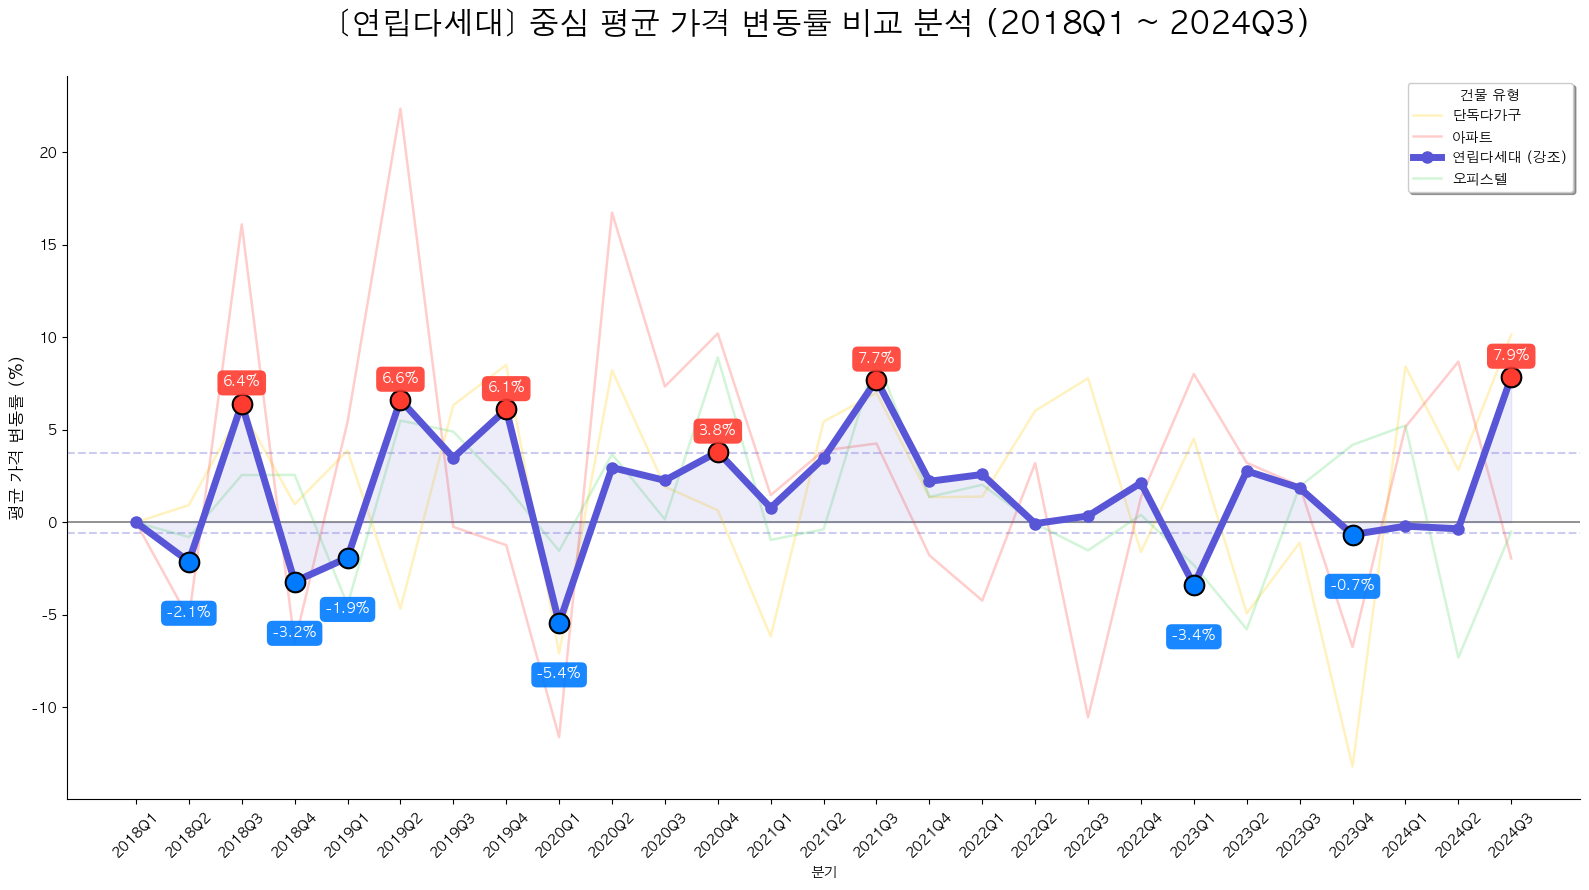

In [71]:
def plot_custom_analysis_v2(df6, start_qtr, end_qtr, target_col='mean_ratio', target_usg='아파트'):
    # 1. 기간 필터링
    mask = (df6['QUARTER'] >= start_qtr) & (df6['QUARTER'] <= end_qtr)
    filtered_df = df6[mask].copy()
    
    if filtered_df.empty:
        print(f"⚠️ {start_qtr} ~ {end_qtr} 기간에 해당하는 데이터가 없습니다.")
        return

    # 2. 텍스트 매핑
    label_dict = {'mean_ratio': '평균 가격 변동률', 'median_ratio': '중앙 가격 변동률', 'trade_ratio': '거래량 변동률'}
    target_label = label_dict.get(target_col, target_col)

    # 3. 주인공 건물의 임계치 계산
    usg_data = filtered_df[filtered_df['BLDG_USG'] == target_usg]
    upper_limit = usg_data[target_col].quantile(0.8)
    lower_limit = usg_data[target_col].quantile(0.2)
    big_move = usg_data[(usg_data[target_col] >= upper_limit) | (usg_data[target_col] <= lower_limit)]

    # 4. 시각화 설정
    # OS별 폰트 설정
    #set_korean_font()
    
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 깨짐 방지
    fig, ax = plt.subplots(figsize=(16, 9))

    # 건물별 고유 색상 팔레트
    base_colors = {'아파트': '#FF3B30', '연립다세대': '#5856D6', '단독다가구': '#FFCC00', '오피스텔': '#4CD964'}
    
    # 5. 그래프 그리기
    for usg in filtered_df['BLDG_USG'].unique():
        subset = filtered_df[filtered_df['BLDG_USG'] == usg]
        color = base_colors.get(usg, '#8E8E93')
        
        if usg == target_usg:
            # 주인공: 굵고 선명하게 + 마커 추가
            ax.plot(subset['QUARTER'], subset[target_col], label=f'{usg} (강조)', 
                    color=color, linewidth=5, zorder=10, marker='o', markersize=8)
            ax.fill_between(subset['QUARTER'], subset[target_col], 0, color=color, alpha=0.1, zorder=9)
        else:
            # 배경 건물: 고유 색상을 유지하되, 얇고 투명하게 (alpha 조절)
            ax.plot(subset['QUARTER'], subset[target_col], label=usg, 
                    color=color, linewidth=1.8, alpha=0.25, zorder=5)

    # 6. 주인공 건물의 '급변 구간' 하이라이트 (수치 박스)
    for _, row in big_move.iterrows():
        val = row[target_col]
        # 박스 색상은 상승/하락 직관성을 위해 Red/Blue 유지
        p_color = '#FF3B30' if val > 0 else '#007AFF'
        
        ax.scatter(row['QUARTER'], val, color=p_color, s=200, edgecolors='black', linewidth=1.5, zorder=12)
        
        # 수치 표시 위치 계산
        max_val = filtered_df[target_col].abs().max()
        offset = (max_val * 0.05)
        ax.text(row['QUARTER'], val + (offset if val > 0 else -offset*2.5), 
                f"{val:.1f}%", ha='center', va='center', fontsize=10, fontweight='black', 
                color='white', bbox=dict(boxstyle='round,pad=0.4', fc=p_color, ec='none', alpha=0.9), zorder=13)

    # 7. 가이드라인 및 디자인
    ax.axhline(0, color='black', linewidth=1.2, alpha=0.5)
    ax.axhline(upper_limit, color=base_colors.get(target_usg), linestyle='--', alpha=0.3)
    ax.axhline(lower_limit, color=base_colors.get(target_usg), linestyle='--', alpha=0.3)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.title(f'[{target_usg}] 중심 {target_label} 비교 분석 ({start_qtr} ~ {end_qtr})', 
              fontsize=22, fontweight='bold', pad=30)
    plt.xticks(rotation=45)
    plt.xlabel('분기')
    plt.ylabel(f'{target_label} (%)', fontsize=12)
    plt.legend(loc='upper right', frameon=True, shadow=True, title="건물 유형")
    
    plt.tight_layout()
    plt.show()

# --- 실행 예시 ---
# 1. 아파트를 강조하되, 나머지 건물들도 고유색으로 보고 싶을 때
plot_custom_analysis_v2(qtr_price, '2018Q1', '2024Q3', target_col='mean_ratio', target_usg='아파트')
plot_custom_analysis_v2(qtr_price, '2018Q1', '2024Q3', target_col='mean_ratio', target_usg='오피스텔')
plot_custom_analysis_v2(qtr_price, '2018Q1', '2024Q3', target_col='mean_ratio', target_usg='단독다가구')
plot_custom_analysis_v2(qtr_price, '2018Q1', '2024Q3', target_col='mean_ratio', target_usg='연립다세대')

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_24657/4276774521.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  trend_df = trend_df.fillna(method='ffill')


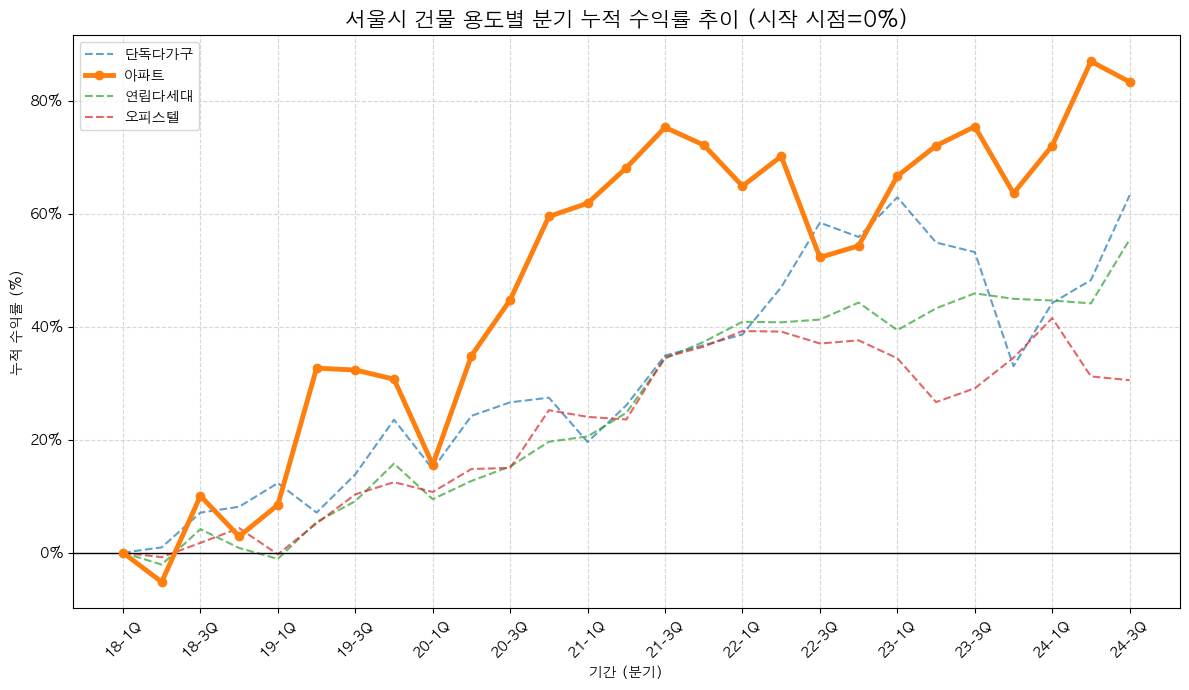

=== 기간 내 최종 누적 수익률 ===
BLDG_USG
아파트      +83.43%
단독다가구    +63.35%
연립다세대    +55.51%
오피스텔     +30.56%
Name: 2024Q3, dtype: object


In [72]:
# 0. 한글 폰트 설정
os_name = platform.system()
if os_name == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif os_name == 'Windows':
    plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 1. 건물 용도별, 분기별 평균 평당가 집계
# 서울시 전체 기준이므로 자치구(CGG_NM) 구분 없이 집계
# df 전역 변수의 'QUARTER' 컬럼(예: 2018Q1) 사용
pivot_df = df6.groupby(['BLDG_USG', 'QUARTER'])['AMT_PER_PYEONG'].mean().unstack(level=0)

# 시계열 순서가 섞이지 않게 인덱스 정렬
trend_df = pivot_df.sort_index()

# 널 값이 있는 경우(특정 분기에 거래가 없는 경우) 보간하거나 drop해야 함
# 여기서는 시각화를 끊기지 않게 하기 위해 앞의 값으로 채움 (선택 사항)
trend_df = trend_df.fillna(method='ffill')

# 2. 누적 수익률 계산 (Cumulative Return)
# (현재가 - 시작가) / 시작가 * 100
# 시작점(첫 데이터)을 기준(0%)으로 잡습니다.
cumulative_return = trend_df.apply(lambda x: (x / x.iloc[0] - 1) * 100)

# 3. 시각화
plt.figure(figsize=(12, 7))

# X축 라벨 생성 (2018Q1 -> 18-1Q 변환)
x_labels = [f"{x[2:4]}-{x[5]}Q" for x in cumulative_return.index]

# 각 건물 용도별로 선 그리기
x_range = range(len(x_labels))

for col in cumulative_return.columns:
    # 아파트는 중요하니 굵고 진하게 강조
    if col == '아파트':
        plt.plot(x_range, cumulative_return[col], label=col, linewidth=3.5, marker='o', zorder=10)
    else:
        plt.plot(x_range, cumulative_return[col], label=col, linewidth=1.5, linestyle='--', alpha=0.7)

# 4. 그래프 꾸미기
plt.title('서울시 건물 용도별 분기 누적 수익률 추이 (시작 시점=0%)', fontsize=15)
plt.ylabel('누적 수익률 (%)')
plt.xlabel('기간 (분기)')

# X축 라벨 설정 (너무 빽빽하지_않게 2분기 간격으로 표시 예시)
# 전체를 다 보여주고 싶으면 slice(::2) 제거
plt.xticks(x_range[::2], x_labels[::2], rotation=45)

# 기준선(0%) 표시
plt.axhline(0, color='black', linewidth=1, linestyle='-')
plt.grid(True, linestyle='--', alpha=0.5)

# Y축 % 포맷
plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))

plt.legend()
plt.tight_layout()
plt.show()

# 최종 수익률 출력
print("=== 기간 내 최종 누적 수익률 ===")
print(cumulative_return.iloc[-1].sort_values(ascending=False).apply(lambda x: f"{x:+.2f}%"))

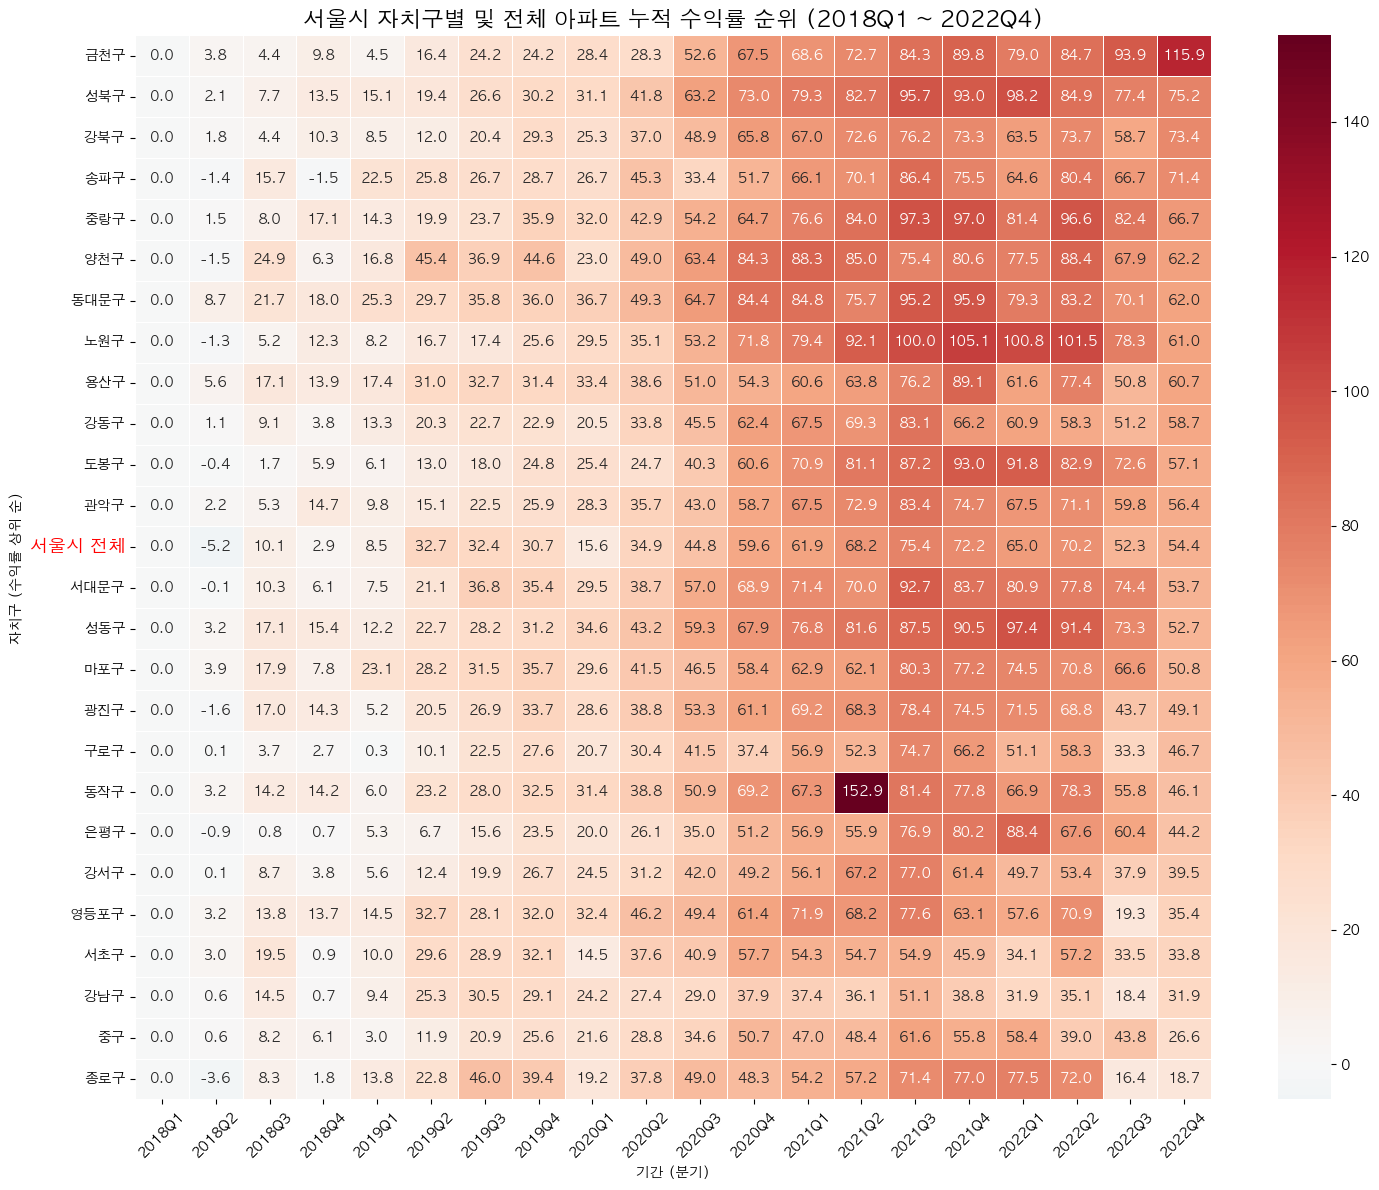

■ 최종 순위 요약 (총 26개 지역)
1위. 금천구: 115.95%
2위. 성북구: 75.24%
3위. 강북구: 73.40%
★ [13위] 서울시 전체: 54.38% (Average)
24위. 강남구: 31.94%
25위. 중구: 26.58%
26위. 종로구: 18.66%


In [73]:
def visualize_seoul_cagr_heatmap_ranked(bldg_type, start_year, start_quarter, duration_quarters):
    """
    자치구별 기간 내 누적 수익률 순위를 Heatmap으로 시각화합니다.
    """
    # 0. 한글 폰트 설정
    os_name = platform.system()
    if os_name == 'Darwin':
        plt.rc('font', family='AppleGothic')
    elif os_name == 'Windows':
        plt.rc('font', family='Malgun Gothic')
    plt.rc('axes', unicode_minus=False)
    
    # 1. 분석 대상 기간 리스트 생성 (포맷: 2018Q1)
    target_quarters = []
    current_y, current_q = start_year, start_quarter
    
    for _ in range(duration_quarters + 1):
        target_quarters.append(f"{current_y}Q{current_q}")
        current_q += 1
        if current_q > 4:
            current_y += 1
            current_q = 1
            
    # 2. 데이터 필터링
    mask = (
        (df6['QUARTER'].isin(target_quarters)) & 
        (df6['BLDG_USG'] == bldg_type) &
        (df6['CGG_NM'].notnull())
    )
    filtered_df = df6.loc[mask].copy() 
    
    if filtered_df.empty:
        print("해당 조건의 데이터가 없습니다.")
        return

    # 3. [개별 자치구] 분기별 평단가 평균 집계 (Pivot)
    # Index: CGG_NM, Columns: QUARTER, Values: AMT_PER_PYEONG
    pivot_price = filtered_df.pivot_table(index='CGG_NM', columns='QUARTER', values='AMT_PER_PYEONG', aggfunc='mean')
    
    # 4. [서울시 전체] 분기별 평단가 평균 집계
    seoul_series = filtered_df.groupby('QUARTER')['AMT_PER_PYEONG'].mean()
    
    # 컬럼 순서 보장 (target_quarters 순서대로 정렬 및 reindex)
    # 데이터에 없는 분기가 있을 경우 NaN 처리됨
    valid_cols = [q for q in target_quarters if q in pivot_price.columns]
    
    # 누락된 기간이 너무 많으면 시각화가 어려우므로 경고
    if len(valid_cols) < 2:
        print("시각화할 기간 데이터가 충분하지 않습니다 (최소 2개 분기 필요).")
        return

    pivot_price = pivot_price[valid_cols]
    seoul_series = seoul_series.reindex(valid_cols)
    
    # 5. 수익률 계산 (기준 시점 대비 누적 수익률)
    # (1) 자치구 수익률
    base_prices = pivot_price.iloc[:, 0]  # 첫 번째 컬럼(시작 시점) 기준
    growth_rate_df = pivot_price.div(base_prices, axis=0) # 나눗셈
    growth_rate_df = (growth_rate_df - 1) * 100           # 백분율 변환
    
    # (2) 서울시 전체 수익률
    seoul_ret = (seoul_series / seoul_series.iloc[0] - 1) * 100
    
    # [핵심] '서울시 전체'를 로우(Row)로 추가
    growth_rate_df.loc['서울시 전체'] = seoul_ret
    
    # 6. 정렬 (마지막 시점 수익률 높은 순)
    final_returns = growth_rate_df.iloc[:, -1]
    final_sorted_df = growth_rate_df.loc[final_returns.sort_values(ascending=False).index]
    
    # 7. Heatmap 시각화
    plt.figure(figsize=(15, 12))
    
    sns.heatmap(final_sorted_df, annot=True, fmt='.1f', cmap='RdBu_r', center=0, linewidths=0.5)
    
    plt.title(f"서울시 자치구별 및 전체 {bldg_type} 누적 수익률 순위 ({valid_cols[0]} ~ {valid_cols[-1]})", fontsize=16)
    plt.xlabel("기간 (분기)")
    plt.ylabel("자치구 (수익률 상위 순)")
    
    # X축 라벨 45도 회전
    plt.xticks(rotation=45)
    
    # y축 라벨에서 '서울시 전체' 강조
    ax = plt.gca()
    for tick in ax.get_yticklabels():
        if tick.get_text() == '서울시 전체':
            tick.set_color('red')
            tick.set_fontweight('heavy')
            tick.set_fontsize(13)
        else:
            tick.set_color('black')
    
    plt.tight_layout()
    plt.show()
    
    # 순위 출력
    print(f"■ 최종 순위 요약 (총 {len(final_sorted_df)}개 지역)")
    rank = 1
    for name in final_sorted_df.index:
        ret = final_sorted_df.loc[name].iloc[-1]
        
        if name == '서울시 전체':
            print(f"★ [{rank}위] {name}: {ret:.2f}% (Average)")
        else:
            # 상위 3개, 하위 3개만 출력
            if rank <= 3 or rank >= len(final_sorted_df) - 2:
                print(f"{rank}위. {name}: {ret:.2f}%")
        rank += 1

# 실행 예시
visualize_seoul_cagr_heatmap_ranked("아파트", 2018, 1, 19)

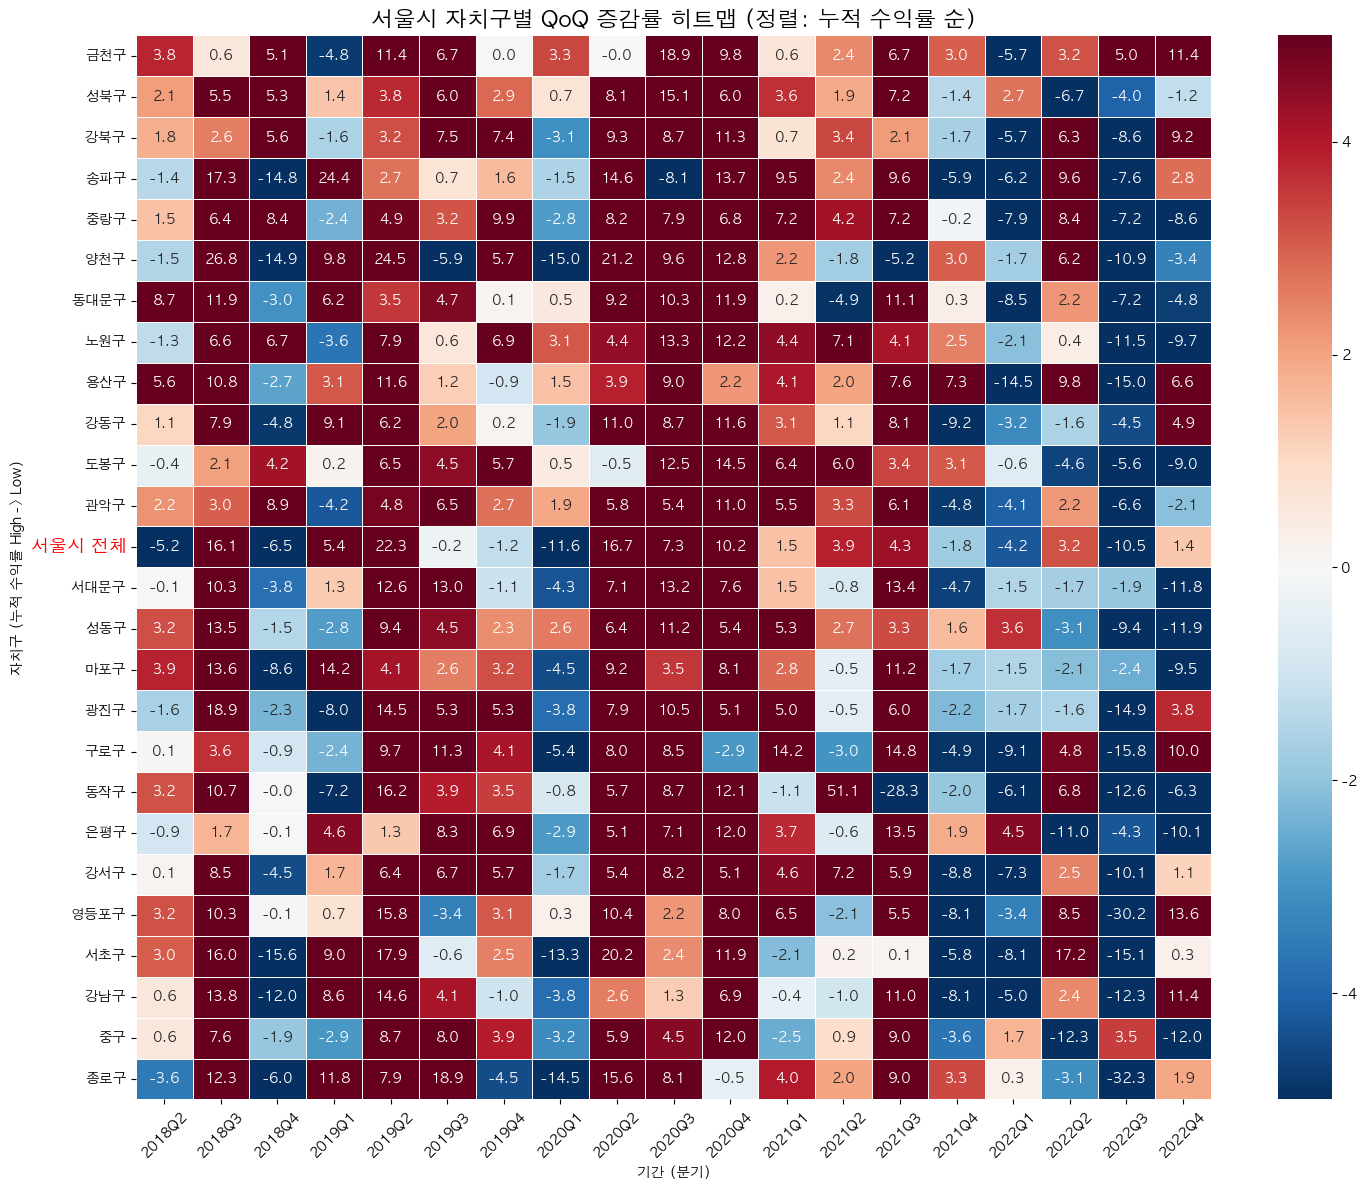

■ 누적 수익률 1위 자치구: 금천구 (115.95%)
■ 서울시 전체 누적 수익률: 54.38%


In [74]:
def visualize_seoul_qoq_heatmap_cum_sorted(bldg_type, start_year, start_quarter, duration_quarters):
    """
    자치구별 기간 내 QoQ(전분기 대비 증감률) 히트맵을 시각화합니다.
    정렬 기준은 기간 내 '누적 수익률'입니다.
    """
    # 0. 한글 폰트 설정
    os_name = platform.system()
    if os_name == 'Darwin':
        plt.rc('font', family='AppleGothic')
    elif os_name == 'Windows':
        plt.rc('font', family='Malgun Gothic')
    plt.rc('axes', unicode_minus=False)

    # 1. 분석 대상 기간 리스트 생성 (포맷: 2018Q1)
    target_quarters = []
    current_y, current_q = start_year, start_quarter
    
    for _ in range(duration_quarters + 1):
        target_quarters.append(f"{current_y}Q{current_q}")
        current_q += 1
        if current_q > 4:
            current_y += 1
            current_q = 1
            
    # 2. 데이터 필터링
    mask = (
        (df6['QUARTER'].isin(target_quarters)) & 
        (df6['BLDG_USG'] == bldg_type) &
        (df6['CGG_NM'].notnull())
    )
    filtered_df = df6.loc[mask].copy()
    
    if filtered_df.empty:
        print("해당 조건의 데이터가 없습니다.")
        return

    # 3. 평단가 집계
    # (1) [개별 자치구] 분기별 평단가
    pivot_price = filtered_df.pivot_table(index='CGG_NM', columns='QUARTER', values='AMT_PER_PYEONG', aggfunc='mean')
    
    # (2) [서울시 전체] 분기별 평단가
    seoul_series = filtered_df.groupby('QUARTER')['AMT_PER_PYEONG'].mean()
    
    # 컬럼 순서 및 인덱스 맞추기 (누락된 분기 고려)
    valid_cols = [q for q in target_quarters if q in pivot_price.columns]
    
    if len(valid_cols) < 2:
        print("시각화할 기간 데이터가 충분하지 않습니다 (증감률 계산을 위해 최소 2개 분기 필요).")
        return

    pivot_price = pivot_price[valid_cols]
    seoul_series = seoul_series.reindex(valid_cols)
    
    # 4. QoQ (전분기 대비 증감률) 계산 -> 히트맵 색칠용
    # axis=1: 컬럼(분기) 간 계산
    qoq_df = pivot_price.pct_change(axis=1) * 100
    qoq_seoul = seoul_series.pct_change() * 100
    
    # 서울시 전체 행 추가
    qoq_df.loc['서울시 전체'] = qoq_seoul
    
    # 첫 분기는 증감률이 NaN이므로 제외
    qoq_df = qoq_df.iloc[:, 1:] 
    
    # 5. [핵심] 정렬 기준: 누적 수익률 (전체 기간)
    # (마지막 가격 / 시작 가격 - 1)
    
    # (1) 자치구 누적 수익률
    dist_cum_ret = (pivot_price.iloc[:, -1] / pivot_price.iloc[:, 0] - 1) * 100
    
    # (2) 서울시 전체 누적 수익률
    seoul_cum_ret = (seoul_series.iloc[-1] / seoul_series.iloc[0] - 1) * 100
    
    # 합쳐서 정렬용 Series 생성
    dist_cum_ret['서울시 전체'] = seoul_cum_ret
    
    # 누적 수익률 높은 순서로 정렬된 인덱스 추출
    sorted_indices = dist_cum_ret.sort_values(ascending=False).index
    
    # QoQ 데이터프레임을 이 순서대로 재정렬
    final_sorted_df = qoq_df.loc[sorted_indices]
    
    if final_sorted_df.empty:
        print("비교할 기간이 충분하지 않습니다.")
        return

    # 6. Heatmap 시각화
    plt.figure(figsize=(15, 12))
    
    sns.heatmap(final_sorted_df, annot=True, fmt='.1f', cmap='RdBu_r', center=0, linewidths=0.5, vmin=-5, vmax=5)
    
    plt.title(f"서울시 자치구별 QoQ 증감률 히트맵 (정렬: 누적 수익률 순)", fontsize=16)
    plt.xlabel("기간 (분기)")
    plt.ylabel("자치구 (누적 수익률 High -> Low)")
    
    # X축 라벨 회전 (45도)
    plt.xticks(rotation=45)
    
    # '서울시 전체' 라벨 강조 (Y축)
    ax = plt.gca()
    for tick in ax.get_yticklabels():
        if tick.get_text() == '서울시 전체':
            tick.set_color('red')
            tick.set_fontweight('heavy')
            tick.set_fontsize(13)
        else:
            tick.set_color('black')
            
    plt.tight_layout()
    plt.show()
    
    # 상위 1등과 서울 평균 출력
    # (주의: sorted_indices에는 서울시 전체도 포함되어 있으므로 구분 필요)
    top_1 = sorted_indices[0] if sorted_indices[0] != '서울시 전체' else sorted_indices[1]
    top_val = dist_cum_ret[top_1]
    
    print(f"■ 누적 수익률 1위 자치구: {top_1} ({top_val:.2f}%)")
    print(f"■ 서울시 전체 누적 수익률: {seoul_cum_ret:.2f}%")

# 실행 예시
visualize_seoul_qoq_heatmap_cum_sorted("아파트", 2018, 1, 19)

In [75]:
## 자치구 별 기간 별 ROI, CAGR 계산기

# 1. 연도별, 지역별, 용도별 평균 평단가 계산
# 그룹핑 기준: 계약연도, 자치구명, 법정동명, 건물용도
# 이상치 제거를 위해 meidan을 사용할 수도 있지만, 요청하신 '평균'을 사용합니다.
price_trend = df6.groupby(['CTRT_YEAR', 'CGG_NM', 'STDG_NM', 'BLDG_USG'])['AMT_PER_PYEONG'].mean().reset_index()

# 2. CAGR 계산 함수 정의
def calculate_cagr(gu, dong, bldg_type, start_year, duration):
    """
    특정 지역, 건물 유형, 투자 기간에 대한 CAGR(연평균 성장률)을 계산하는 함수
    
    Parameters:
    - gu: 자치구명 (예: '서대문구')
    - dong: 법정동명 (예: '대현동')
    - bldg_type: 건물용도 (예: '아파트')
    - start_year: 매수 연도 (예: 2018)
    - duration: 보유 기간 (년) (예: 6) -> 매도 연도 = start_year + duration
    """
    end_year = start_year + duration
    
    # 시작 연도 데이터 조회
    start_row = price_trend[
        (price_trend['CGG_NM'] == gu) &
        (price_trend['STDG_NM'] == dong) &
        (price_trend['BLDG_USG'] == bldg_type) &
        (price_trend['CTRT_YEAR'] == start_year)
    ]
    
    # 끝 연도 데이터 조회
    end_row = price_trend[
        (price_trend['CGG_NM'] == gu) &
        (price_trend['STDG_NM'] == dong) &
        (price_trend['BLDG_USG'] == bldg_type) &
        (price_trend['CTRT_YEAR'] == end_year)
    ]
    
    # 데이터 유효성 검사
    if start_row.empty:
        return f"Error: `{start_year}`년도 `{gu} {dong} {bldg_type}` 데이터가 없습니다."
    if end_row.empty:
        return f"Error: `{end_year}`년도 `{gu} {dong} {bldg_type}` 데이터가 없습니다."
    
    # 가격 추출 (Series 형태이므로 값만 추출)
    start_price = start_row['AMT_PER_PYEONG'].values[0]
    end_price = end_row['AMT_PER_PYEONG'].values[0]
    
    # CAGR 공식: (기말가치 / 기초가치)^(1/기간) - 1
    cagr = (end_price / start_price) ** (1 / duration) - 1
    
    # 결과 출력용 포맷팅
    print(f"[{gu} {dong} {bldg_type}]")
    print(f"- 매수({start_year}년): {start_price:,.0f} 만원/평")
    print(f"- 매도({end_year}년): {end_price:,.0f} 만원/평")
    print(f"- 총 수익률: {((end_price - start_price) / start_price) * 100:.2f}%")
    print(f"- CAGR (연평균 수익률): {cagr * 100:.2f}%")
    
    return cagr

# --- 사용 예시 ---
# 예: 서대문구 대현동 아파트를 2018년에 사서 6년(2024년) 뒤에 팔았다면?
result = calculate_cagr("서대문구", "대현동", "아파트", 2018, 6)

[서대문구 대현동 아파트]
- 매수(2018년): 2,701 만원/평
- 매도(2024년): 4,028 만원/평
- 총 수익률: 49.12%
- CAGR (연평균 수익률): 6.89%


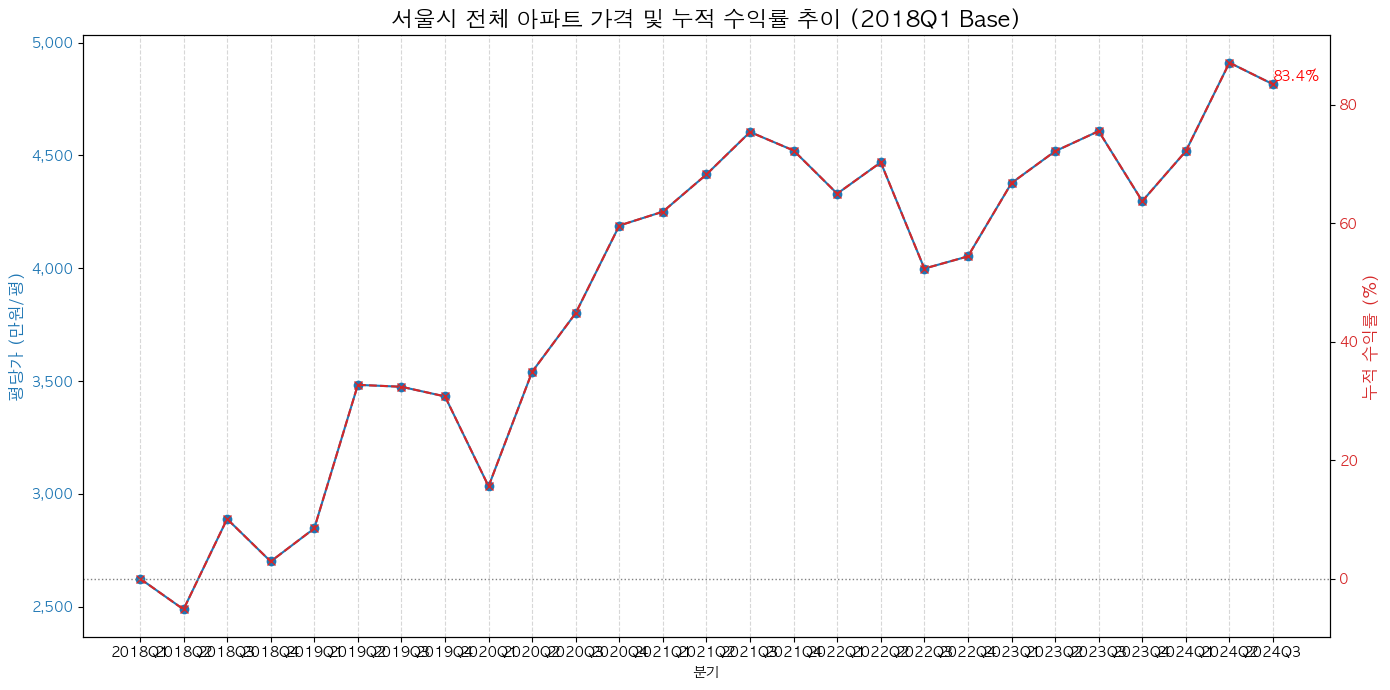

■ 서울시 전체 아파트 시장 흐름 요약
- 분석 기간: 27개 분기 (2018Q1 ~ 2024Q3)
- 시작 평당가: 2,625 만원
- 종료 평당가: 4,815 만원
- 서울시 전체 누적 수익률: 83.43%


In [76]:
def visualize_seoul_total_trend(bldg_type, start_year, start_quarter, duration_quarters):

    # 0. 한글 폰트 설정
    os_name = platform.system()
    if os_name == 'Darwin':
        plt.rc('font', family='AppleGothic')
    elif os_name == 'Windows':
        plt.rc('font', family='Malgun Gothic')
    plt.rc('axes', unicode_minus=False)
    
    # 1. 분석 대상 기간 리스트 생성 (포맷: 2018Q1)
    target_quarters = []
    current_y, current_q = start_year, start_quarter
    
    for _ in range(duration_quarters + 1):
        target_quarters.append(f"{current_y}Q{current_q}")
        current_q += 1
        if current_q > 4:
            current_y += 1
            current_q = 1
            
    # 2. 데이터 필터링 및 집계
    # 이미 존재하는 'QUARTER' 컬럼을 사용하여 필터링
    mask = (df6['BLDG_USG'] == bldg_type) & (df6['QUARTER'].isin(target_quarters))
    
    filtered_df = df6.loc[mask]
    
    if filtered_df.empty:
        print("해당 조건의 데이터가 없습니다.")
        return

    # 분기별 평단가 평균 계산 (Index: QUARTER, Value: AMT_PER_PYEONG)
    # reindex를 사용하여 원하는 기간 순서대로 정렬 (누락된 기간은 NaN 처리 후 dropna)
    price_series = filtered_df.groupby('QUARTER')['AMT_PER_PYEONG'].mean()
    price_series = price_series.reindex(target_quarters).dropna()

    if price_series.empty:
        print("기간 내 유효한 데이터가 없습니다.")
        return

    # 3. 수익률 계산 (시작 시점 대비)
    start_price = price_series.iloc[0]
    return_series = (price_series / start_price - 1) * 100
    
    # 4. 시각화
    fig, ax1 = plt.subplots(figsize=(14, 7))
    
    # (1) 평단가 그래프 (좌측 축)
    color_price = 'tab:blue'
    # 제목에 시작 분기 표시
    ax1.set_title(f"서울시 전체 {bldg_type} 가격 및 누적 수익률 추이 ({target_quarters[0]} Base)", fontsize=16)
    ax1.set_xlabel('분기')
    ax1.set_ylabel('평당가 (만원/평)', color=color_price, fontsize=12)
    
    ax1.plot(price_series.index, price_series.values, color=color_price, marker='o', label='평균 평당가')
    ax1.tick_params(axis='y', labelcolor=color_price)
    ax1.grid(True, axis='x', linestyle='--', alpha=0.5)
    
    # Y축 천단위 콤마 포맷
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # (2) 수익률 그래프 (우측 축)
    ax2 = ax1.twinx()
    color_ret = 'tab:red'
    ax2.set_ylabel('누적 수익률 (%)', color=color_ret, fontsize=12) 
    
    ax2.plot(return_series.index, return_series.values, color=color_ret, linestyle='--', marker='x', label='누적 수익률')
    ax2.tick_params(axis='y', labelcolor=color_ret)
    
    # 0% 기준선
    ax2.axhline(0, color='gray', linestyle=':', linewidth=1)
    
    # 마지막 시점 수익률 텍스트 표시
    last_idx = return_series.index[-1]
    last_val = return_series.iloc[-1]
    ax2.text(last_idx, last_val, f"{last_val:.1f}%", color='red', fontweight='bold', va='bottom', ha='left')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # 5. 결과 요약 출력
    print(f"■ 서울시 전체 {bldg_type} 시장 흐름 요약")
    print(f"- 분석 기간: {len(price_series)}개 분기 ({price_series.index[0]} ~ {price_series.index[-1]})")
    print(f"- 시작 평당가: {start_price:,.0f} 만원")
    print(f"- 종료 평당가: {price_series.iloc[-1]:,.0f} 만원")
    print(f"- 서울시 전체 누적 수익률: {last_val:.2f}%")

# 실행 예시
visualize_seoul_total_trend("아파트", 2018, 1, 26)

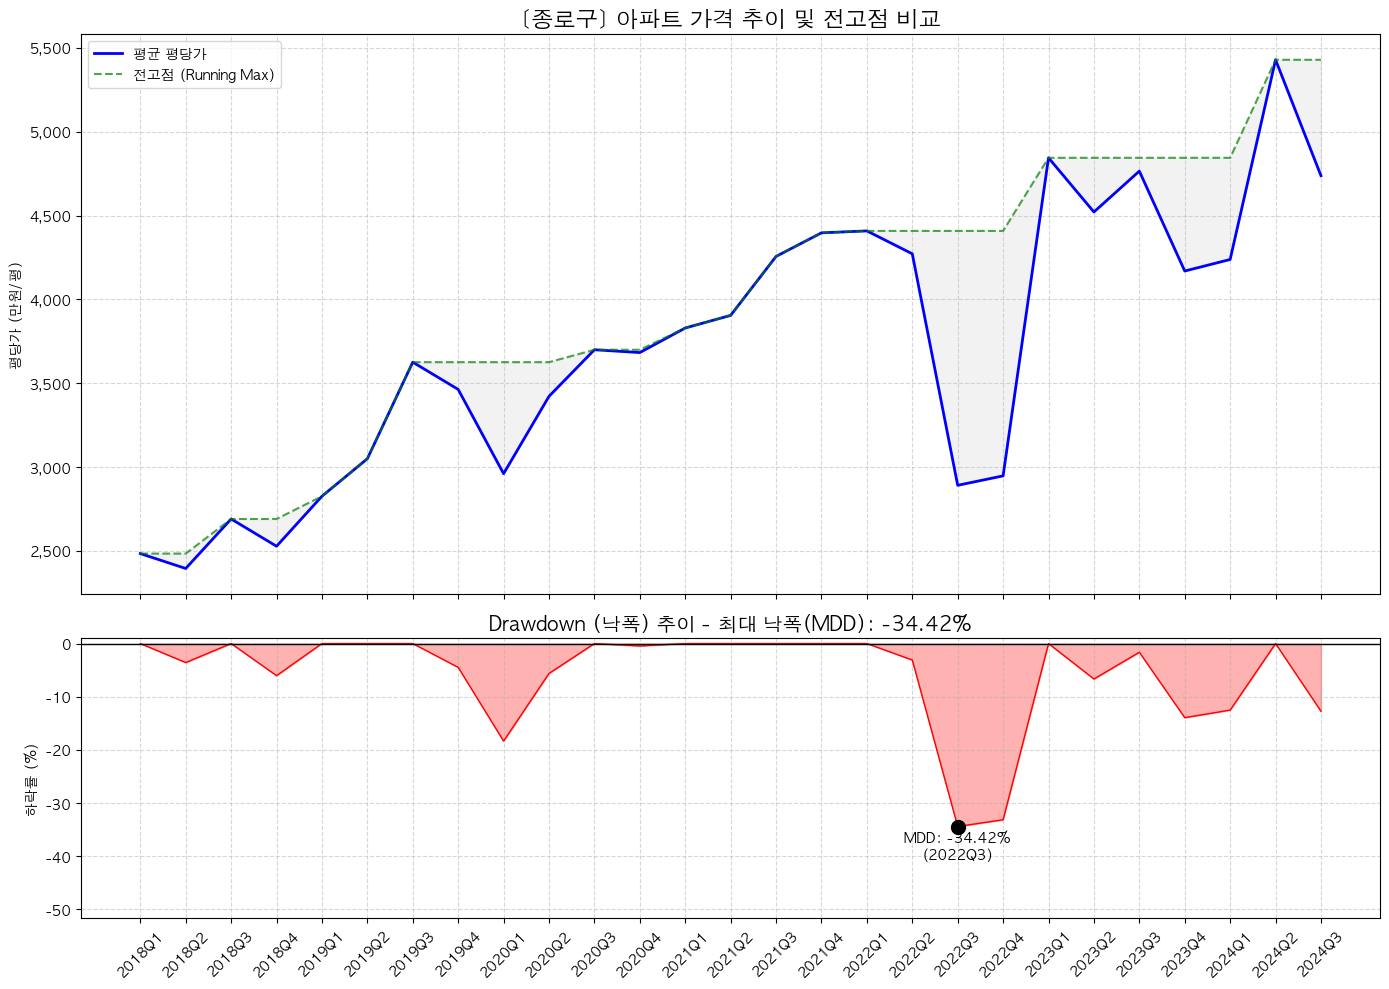

■ [종로구] 아파트 MDD 분석 결과
- 최대 낙폭(MDD): -34.42%
- MDD 발생 시점: 2022Q3 (전고점 4,409만원 대비)
- 현재 Drawdown: -12.74%


In [77]:
def visualize_mdd(bldg_type, start_year, start_quarter, duration_quarters, region='서울시'):
    """
    지역(서울시 전체 또는 특정 자치구)의 아파트 가격 MDD를 시각화합니다.
    df 전역 변수의 'QUARTER'(예: 2018Q1) 컬럼을 사용합니다.
    """
    # 0. 한글 폰트 설정
    os_name = platform.system()
    if os_name == 'Darwin':
        plt.rc('font', family='AppleGothic')
    elif os_name == 'Windows':
        plt.rc('font', family='Malgun Gothic')
    plt.rc('axes', unicode_minus=False)
    
    # 1. 분석 대상 기간 리스트 생성 (포맷: 2018Q1)
    target_quarters = []
    current_y, current_q = start_year, start_quarter
    
    for _ in range(duration_quarters + 1):
        target_quarters.append(f"{current_y}Q{current_q}")
        current_q += 1
        if current_q > 4:
            current_y += 1
            current_q = 1
            
    # 2. 데이터 필터링
    # 기본 마스크: 건물 용도 & 기간
    mask = (df6['BLDG_USG'] == bldg_type) & (df6['QUARTER'].isin(target_quarters))
    
    # [수정] 특정 자치구가 선택된 경우 조건 추가
    if region != '서울시':
        mask = mask & (df6['CGG_NM'] == region)

    filtered_df = df6.loc[mask]
    
    if filtered_df.empty:
        print(f"[{region}] 해당 기간에 데이터가 없습니다.")
        return

    # 분기별 평단가 평균 집계 (Index: QUARTER, Value: AMT_PER_PYEONG)
    # reindex를 사용하여 순서를 보장하고, 누락된 기간은 dropna로 처리
    trend_series = filtered_df.groupby('QUARTER')['AMT_PER_PYEONG'].mean()
    trend_series = trend_series.reindex(target_quarters).dropna()
    
    if trend_series.empty:
        print(f"[{region}] 선택한 기간에 유효한 데이터가 충분하지 않습니다.")
        return

    # Series -> DataFrame 변환
    trend_df = pd.DataFrame({'AMT_PER_PYEONG': trend_series})

    # 3. MDD 계산 (Run Max 대비 현재가 하락률)
    trend_df['Run_Max'] = trend_df['AMT_PER_PYEONG'].cummax()
    trend_df['Drawdown'] = (trend_df['AMT_PER_PYEONG'] / trend_df['Run_Max'] - 1) * 100
    
    mdd_val = trend_df['Drawdown'].min()
    mdd_point = trend_df['Drawdown'].idxmin()

    # 4. 시각화
    fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    
    # (1) Upper Plot: 가격 및 전고점
    ax[0].plot(trend_df.index, trend_df['AMT_PER_PYEONG'], label='평균 평당가', color='blue', linewidth=2)
    ax[0].plot(trend_df.index, trend_df['Run_Max'], label='전고점 (Running Max)', color='green', linestyle='--', alpha=0.7)
    ax[0].fill_between(trend_df.index, trend_df['AMT_PER_PYEONG'], trend_df['Run_Max'], color='gray', alpha=0.1)
    
    ax[0].set_title(f"[{region}] {bldg_type} 가격 추이 및 전고점 비교", fontsize=16, fontweight='bold')
    ax[0].set_ylabel("평당가 (만원/평)")
    ax[0].legend(loc='upper left')
    ax[0].grid(True, linestyle='--', alpha=0.5)
    
    # Y축 천단위 콤마
    ax[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))

    # (2) Lower Plot: Drawdown (Underwater Plot)
    ax[1].fill_between(trend_df.index, trend_df['Drawdown'], 0, color='red', alpha=0.3)
    ax[1].plot(trend_df.index, trend_df['Drawdown'], color='red', linewidth=1)
    
    # MDD 지점 표시
    ax[1].scatter(mdd_point, mdd_val, color='black', s=100, zorder=5)
    ax[1].text(mdd_point, mdd_val - 1, f"MDD: {mdd_val:.2f}%\n({mdd_point})", 
               ha='center', va='top', fontweight='bold', color='black')
    
    ax[1].set_title(f"Drawdown (낙폭) 추이 - 최대 낙폭(MDD): {mdd_val:.2f}%", fontsize=14)
    ax[1].set_ylabel("하락률 (%)")
    
    # Y축 범위 조정
    lower_lim = min(mdd_val * 1.5, -5) if mdd_val < 0 else -5
    ax[1].set_ylim(lower_lim, 1)
    
    ax[1].axhline(0, color='black', linewidth=1)
    ax[1].grid(True, linestyle='--', alpha=0.5)
    
    # X축 라벨 회전 (요청사항 반영)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

    # 결과 요약
    print(f"■ [{region}] {bldg_type} MDD 분석 결과")
    print(f"- 최대 낙폭(MDD): {mdd_val:.2f}%")
    print(f"- MDD 발생 시점: {mdd_point} (전고점 {trend_df.loc[mdd_point, 'Run_Max']:,.0f}만원 대비)")
    print(f"- 현재 Drawdown: {trend_df['Drawdown'].iloc[-1]:.2f}%")

# --- 사용 예시 ---
visualize_mdd("아파트", 2018, 1, 27, region="종로구")

      [종로구 vs 서울시 전체] 아파트 투자 백테스트 비교
1. 투자 기간 : 2022Q1 ~ 2022Q4 (4분기)
2. 매입 금액 : 100,000만 원
----------------------------------------------------------------
   구분        |      종로구      |     서울시 전체
----------------------------------------------------------------
3. 최종 금액   |  66,853만 (-33,147만) |  93,581만 (-6,419만)
4. 누적 수익률 |     -33.15 %       |      -6.42 %
----------------------------------------------------------------
 * 비교 결과: 종로구 수익률이 서울 평균보다 낮음



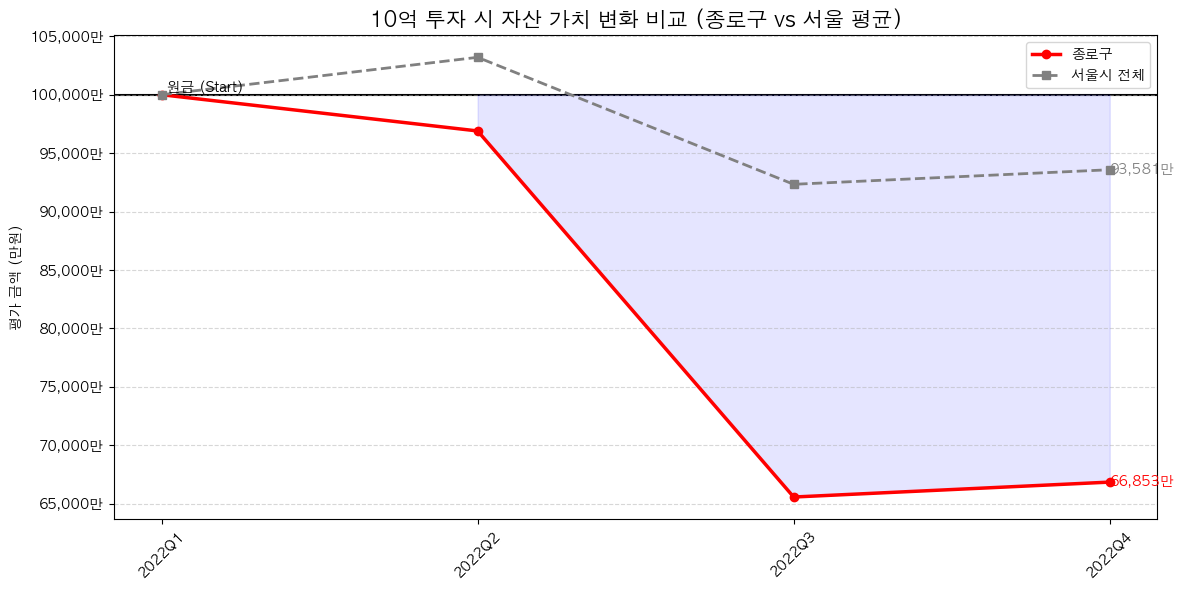

In [78]:
def run_real_estate_backtest_vs_seoul(target_gu, bldg_type, start_year, start_quarter, initial_capital, duration_quarters):
    """
    특정 자치구와 서울시 전체의 부동산 투자 백테스트를 수행하고 비교합니다. (CAGR/MDD 제거)
    """

    # 0. 한글 폰트 설정
    os_name = platform.system()
    if os_name == 'Darwin':
        plt.rc('font', family='AppleGothic')
    elif os_name == 'Windows':
        plt.rc('font', family='Malgun Gothic')
    plt.rc('axes', unicode_minus=False)
    
    # 1. 분석 대상 기간 리스트 생성 (포맷: 2018Q1)
    target_quarters = []
    current_y, current_q = start_year, start_quarter
    
    for _ in range(duration_quarters + 1):
        target_quarters.append(f"{current_y}Q{current_q}")
        current_q += 1
        if current_q > 4:
            current_y += 1
            current_q = 1
            
    # 2. 데이터 필터링
    # (1) 타겟 자치구
    mask_gu = (
        (df6['QUARTER'].isin(target_quarters)) & 
        (df6['BLDG_USG'] == bldg_type) &
        (df6['CGG_NM'] == target_gu)
    )
    df_gu = df6.loc[mask_gu].copy()
    
    # (2) 서울시 전체 (비교군)
    mask_seoul = (
        (df6['QUARTER'].isin(target_quarters)) & 
        (df6['BLDG_USG'] == bldg_type)
    )
    df_seoul = df6.loc[mask_seoul].copy()
    
    if df_gu.empty or df_seoul.empty:
        print("데이터가 부족합니다.")
        return

    # 공통 전처리 함수 (분기별 평단가 Series 생성)
    def get_price_series(temp_df):
        # Index: QUARTER, Value: AMT_PER_PYEONG
        series = temp_df.groupby('QUARTER')['AMT_PER_PYEONG'].mean()
        series = series.reindex(target_quarters).dropna()
        return series

    price_gu = get_price_series(df_gu)
    price_seoul = get_price_series(df_seoul)
    
    # 데이터가 중간에 끊겼으면 교집합 기간만 비교
    common_idx = price_gu.index.intersection(price_seoul.index)
    if common_idx.empty:
        print("겹치는 기간의 데이터가 없습니다.")
        return
        
    price_gu = price_gu.loc[common_idx]
    price_seoul = price_seoul.loc[common_idx]
    
    # 3. 자산 가치 변동 및 지표 계산 함수 (CAGR, MDD 제거)
    def calc_metrics(price_series, capital):
        start_p = price_series.iloc[0]
        # (현재가 / 시작가) * 원금 = 현재 평가금액
        portfolio = (price_series / start_p) * capital
        
        final_val = portfolio.iloc[-1]
        ret = (final_val / capital - 1) * 100
        
        return portfolio, final_val, ret

    # 계산 수행
    pf_gu, val_gu, ret_gu = calc_metrics(price_gu, initial_capital)
    pf_seoul, val_seoul, ret_seoul = calc_metrics(price_seoul, initial_capital)
    
    profit_gu = val_gu - initial_capital
    profit_seoul = val_seoul - initial_capital
    
    # --- [결과 텍스트 출력] (단위: 만원) ---
    print(f"================================================================")
    print(f"      [{target_gu} vs 서울시 전체] {bldg_type} 투자 백테스트 비교")
    print(f"================================================================")
    print(f"1. 투자 기간 : {common_idx[0]} ~ {common_idx[-1]} ({len(common_idx)}분기)")
    print(f"2. 매입 금액 : {initial_capital/10000:,.0f}만 원")
    print(f"----------------------------------------------------------------")
    print(f"   구분        |      {target_gu}      |     서울시 전체")
    print(f"----------------------------------------------------------------")
    print(f"3. 최종 금액   |  {val_gu/10000:,.0f}만 ({profit_gu/10000:+,.0f}만) |  {val_seoul/10000:,.0f}만 ({profit_seoul/10000:+,.0f}만)")
    print(f"4. 누적 수익률 |     {ret_gu:6.2f} %       |     {ret_seoul:6.2f} %")
    print(f"----------------------------------------------------------------")
    print(f" * 비교 결과: {target_gu} 수익률이 서울 평균보다 {'높음' if ret_gu > ret_seoul else '낮음'}")
    print(f"================================================================\n")
    
    # --- [시각화] ---
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # (1) 데이터 플로팅
    ax.plot(pf_gu.index, pf_gu, color='red', linewidth=2.5, marker='o', label=f'{target_gu}')
    ax.plot(pf_seoul.index, pf_seoul, color='gray', linewidth=2, linestyle='--', marker='s', label='서울시 전체')
    
    # (2) 기준선 (원금) 강조
    ax.axhline(initial_capital, color='black', linewidth=1.5, linestyle='-', zorder=1)
    ax.text(pf_gu.index[0], initial_capital, " 원금 (Start)", va='bottom', fontweight='bold')
    
    # (3) 영역 채우기
    ax.fill_between(pf_gu.index, pf_gu, initial_capital, where=(pf_gu >= initial_capital), color='red', alpha=0.1)
    ax.fill_between(pf_gu.index, pf_gu, initial_capital, where=(pf_gu < initial_capital), color='blue', alpha=0.1)
    
    ax.set_title(f"10억 투자 시 자산 가치 변화 비교 ({target_gu} vs 서울 평균)", fontsize=15)
    ax.set_ylabel("평가 금액 (만원)")
    
    # Y축 포맷 (만원 단위)
    def ten_thousands(x, pos):
        return f'{x/10000:,.0f}만'
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(ten_thousands))
    
    # 최종 금액 라벨링 (만원 단위)
    ax.text(pf_gu.index[-1], pf_gu.iloc[-1], f"{pf_gu.iloc[-1]/10000:,.0f}만", color='red', fontweight='bold', ha='left', va='center')
    ax.text(pf_seoul.index[-1], pf_seoul.iloc[-1], f"{pf_seoul.iloc[-1]/10000:,.0f}만", color='gray', fontweight='bold', ha='left', va='center')

    # X축 라벨 회전 (45도)
    plt.xticks(rotation=45)
    
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 실행 예시
run_real_estate_backtest_vs_seoul("종로구", "아파트", 2022, 1, 1000000000, 3)

      [종로구 vs 서울시 전체] 아파트 투자 백테스트 비교
1. 투자 기간 : 2022Q1 ~ 2024Q3 (11분기)
2. 매입 금액 : 100,000만 원
----------------------------------------------------------------
   구분        |      종로구      |     서울시 전체
----------------------------------------------------------------
3. 최종 금액   |  107,467만 (+7,467만) |  111,193만 (+11,193만)
4. 누적 수익률 |       7.47 %       |      11.19 %
----------------------------------------------------------------
 * 비교 결과: 종로구 수익률이 서울 평균보다 낮음



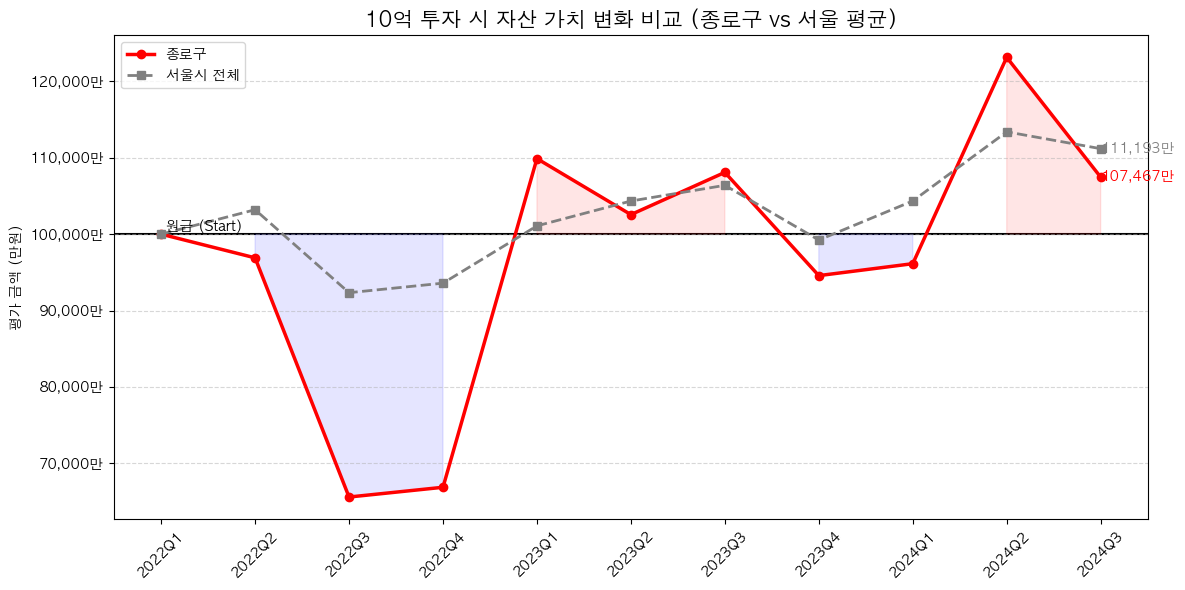

In [79]:
run_real_estate_backtest_vs_seoul("종로구", "아파트", 2022, 1, 1000000000, 10)

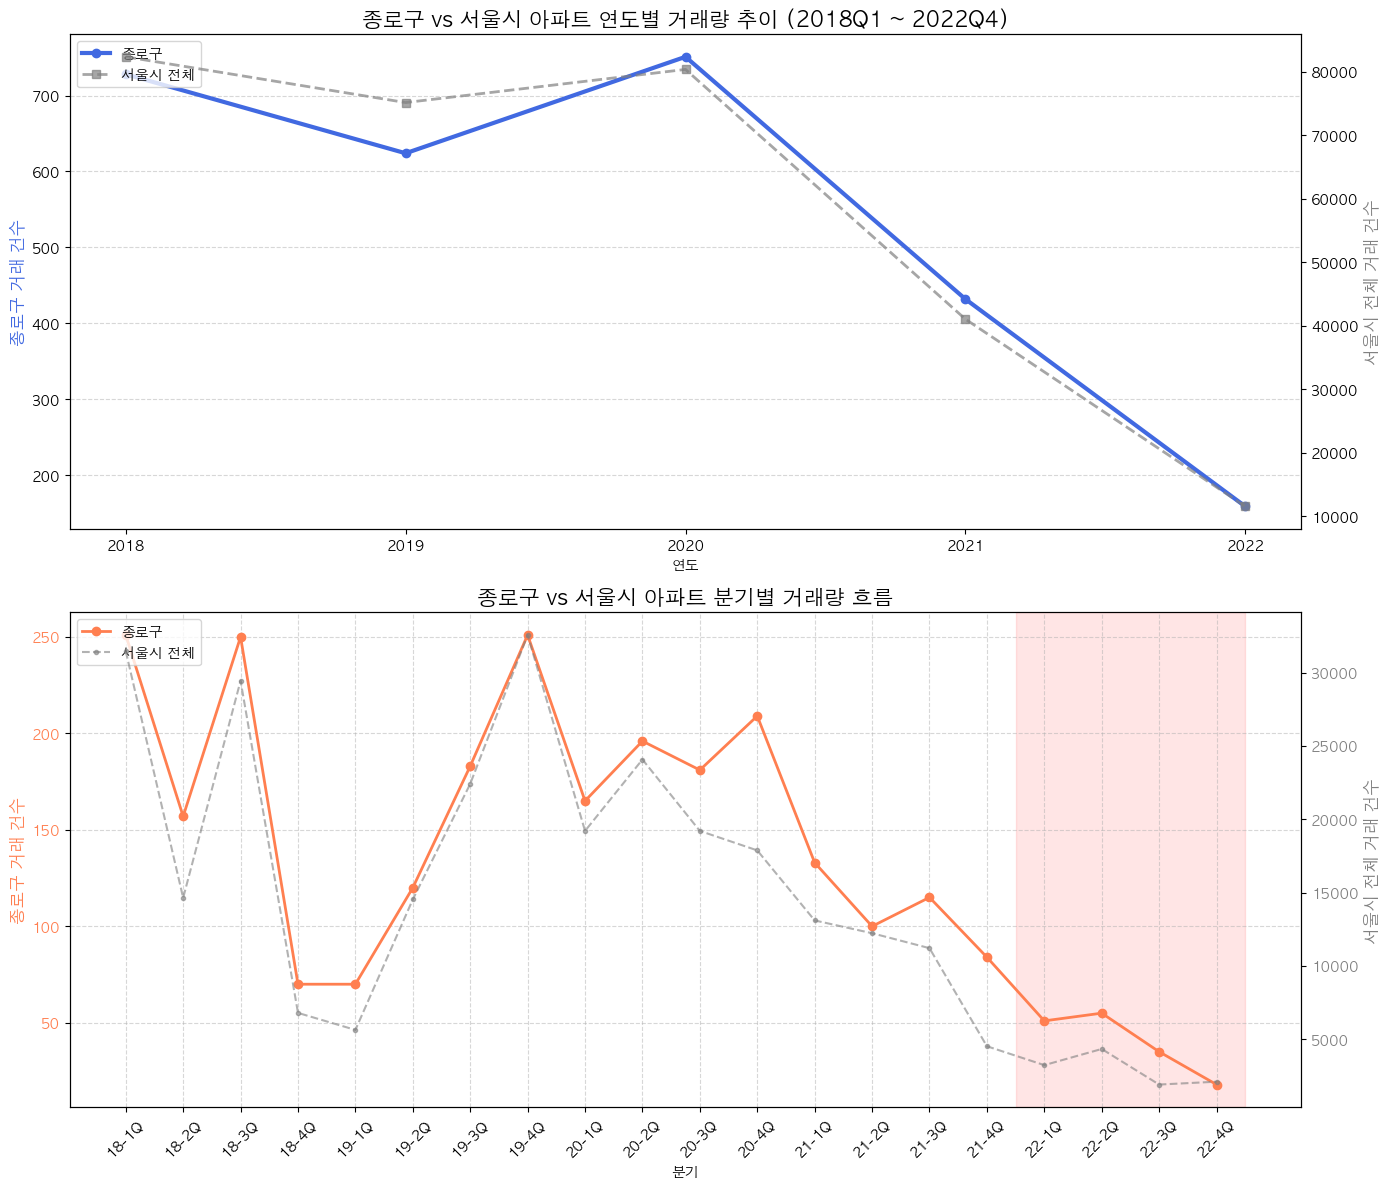

In [80]:
def visualize_transaction_volume_vs_seoul(gu_name, start_year, start_quarter, duration_quarters, bldg_type="아파트"):
    """
    특정 자치구와 서울시 전체의 거래량을 설정된 기간 동안 연도별/분기별로 비교하여 시각화합니다.
    """

    # 0. 한글 폰트 설정
    os_name = platform.system()
    if os_name == 'Darwin':
        plt.rc('font', family='AppleGothic')
    elif os_name == 'Windows':
        plt.rc('font', family='Malgun Gothic')
    plt.rc('axes', unicode_minus=False)
    
    # 1. 분석 대상 기간 리스트 생성 (포맷: 2018Q1)
    target_quarters = []
    current_y, current_q = start_year, start_quarter
    
    for _ in range(duration_quarters + 1):
        target_quarters.append(f"{current_y}Q{current_q}")
        current_q += 1
        if current_q > 4:
            current_y += 1
            current_q = 1
            
    # 2. 데이터 준비 & 필터링
    # (1) 타겟 자치구
    mask_gu = (
        (df6['QUARTER'].isin(target_quarters)) & 
        (df6['CGG_NM'] == gu_name) & 
        (df6['BLDG_USG'] == bldg_type)
    )
    gu_df = df6.loc[mask_gu].copy()
    
    # (2) 서울시 전체 (비교군)
    mask_seoul = (
        (df6['QUARTER'].isin(target_quarters)) & 
        (df6['BLDG_USG'] == bldg_type)
    )
    seoul_df = df6.loc[mask_seoul].copy()

    if gu_df.empty:
        print(f"{gu_name} {bldg_type} 데이터가 없습니다.")
        return

    # 3. 연도별 거래량 집계
    gu_yearly = gu_df.groupby('CTRT_YEAR').size()
    seoul_yearly = seoul_df.groupby('CTRT_YEAR').size()

    # 4. 분기별 거래량 집계
    seoul_quarterly = seoul_df.groupby('QUARTER').size().sort_index()
    gu_quarterly = gu_df.groupby('QUARTER').size().sort_index()
    
    # 기간 맞추기 (Zero filling)
    seoul_quarterly = seoul_quarterly.reindex(target_quarters, fill_value=0)
    gu_quarterly = gu_quarterly.reindex(target_quarters, fill_value=0)
    
    # X축 라벨 생성 ('2019Q1' -> '19-1Q' 변환)
    q_labels = [f"{x[2:4]}-{x[5]}Q" for x in target_quarters]
    
    # 5. 시각화
    fig, ax = plt.subplots(2, 1, figsize=(14, 12))

    # --- (1) 연도별 Line Chart ---
    line_y1 = ax[0].plot(gu_yearly.index, gu_yearly.values, marker='o', color='royalblue', linewidth=3, label=f'{gu_name}')
    ax[0].set_ylabel(f"{gu_name} 거래 건수", color='royalblue', fontsize=12)
    ax[0].grid(axis='y', linestyle='--', alpha=0.5)
    
    # 오른쪽 축: 서울시 전체
    ax0_twin = ax[0].twinx()
    line_y2 = ax0_twin.plot(seoul_yearly.index, seoul_yearly.values, color='gray', marker='s', linestyle='--', linewidth=2, alpha=0.7, label='서울시 전체')
    ax0_twin.set_ylabel("서울시 전체 거래 건수", color='gray', fontsize=12)
    
    # X축 정수만 표시 및 라벨 추가
    ax[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax[0].set_title(f"{gu_name} vs 서울시 {bldg_type} 연도별 거래량 추이 ({target_quarters[0]} ~ {target_quarters[-1]})", fontsize=15)
    ax[0].set_xlabel("연도")  # [추가됨]
    
    # 범례 합치기
    lines_y = line_y1 + line_y2
    labels_y = [l.get_label() for l in lines_y]
    ax[0].legend(lines_y, labels_y, loc='upper left')

    # --- (2) 분기별 Line Chart ---
    x_range = range(len(q_labels))
    
    line_q1 = ax[1].plot(x_range, gu_quarterly.values, marker='o', color='coral', linewidth=2, label=f'{gu_name}')
    ax[1].set_ylabel(f"{gu_name} 거래 건수", color='coral', fontsize=12)
    ax[1].tick_params(axis='y', labelcolor='coral')
    
    # 오른쪽 축: 서울시 전체
    ax1_twin = ax[1].twinx()
    line_q2 = ax1_twin.plot(x_range, seoul_quarterly.values, marker='.', color='gray', linestyle='--', alpha=0.6, label='서울시 전체')
    ax1_twin.set_ylabel("서울시 전체 거래 건수", color='gray', fontsize=12)
    ax1_twin.tick_params(axis='y', labelcolor='gray')
    
    # X축 설정 및 라벨 추가
    ax[1].set_xticks(x_range)
    ax[1].set_xticklabels(q_labels, rotation=45) 
    ax[1].set_title(f"{gu_name} vs 서울시 {bldg_type} 분기별 거래량 흐름", fontsize=15)
    ax[1].set_xlabel("분기")  # [추가됨]
    ax[1].grid(True, linestyle='--', alpha=0.5)
    
    # 2022년 하락장 구간 강조
    indices_2022 = [i for i, label in enumerate(q_labels) if '22-' in label]
    if indices_2022:
        ax[1].axvspan(indices_2022[0]-0.5, indices_2022[-1]+0.5, color='red', alpha=0.1, label='2022년(하락장)')

    # 범례 표시
    lines_q = line_q1 + line_q2
    labels_q = [l.get_label() for l in lines_q]
    ax[1].legend(lines_q, labels_q, loc='upper left')

    plt.tight_layout()
    plt.show()

# 사용 예시
visualize_transaction_volume_vs_seoul("종로구", 2018, 1, 19)

In [81]:
# 쿼리 조건 설정 (자치구 리스트에서 종로구만 선택하거나, 전체를 위해 비워둠)
target_year = 2022
target_quarters_nums = [1, 2, 3, 4]
target_quarters_str = [f"{target_year}Q{q}" for q in target_quarters_nums]
target_target_gu = '종로구'

# 전체 서울시 데이터 필터링 (평균 산출용)
seoul_condition = (
    (df6['QUARTER'].isin(target_quarters_str)) &
    (df6['BLDG_USG'] == '아파트')
)
seoul_df = df6[seoul_condition]

# 데이터 집계
# (1) 서울시 구별/분기별 거래량 계산 후 -> 분기별 '평균' 산출
seoul_avg = seoul_df.groupby(['QUARTER', 'CGG_NM']).size().unstack(fill_value=0)
seoul_avg_series = seoul_avg.mean(axis=1) # 자치구 방향으로 평균

# (2) 종로구 분기별 거래량 계산
jongno_series = seoul_df[seoul_df['CGG_NM'] == target_target_gu].groupby('QUARTER').size()

# 결과 합치기
comparison_result = pd.DataFrame({
    f'{target_target_gu}': jongno_series,
    '서울시 구 평균': seoul_avg_series
}).T # 보기 편하게 행/열 전환

print(f"=== {target_year}년 아파트 거래량: {target_target_gu} vs 서울시 평균 ===")
display(comparison_result.round(1)) # 평균값은 소수점 1자리까지

=== 2022년 아파트 거래량: 종로구 vs 서울시 평균 ===


QUARTER,2022Q1,2022Q2,2022Q3,2022Q4
종로구,51.0,55.0,35.0,18.0
서울시 구 평균,128.9,173.0,75.9,83.7


### 페르소나2

In [82]:
# 아파트 기준 자치구별 평균 평당가(AMT_PER_PYEONG) 산출 및 정렬
AMT_PER_PYEONG_ranking = df6[df6['BLDG_USG'] == '오피스텔'].groupby('CGG_NM')['AMT_PER_PYEONG'].mean().sort_values(ascending=False)

# 결과 출력
print("--- [서울 오피스텔 평당가 서열 TOP 25] ---")
print(AMT_PER_PYEONG_ranking)

--- [서울 오피스텔 평당가 서열 TOP 25] ---
CGG_NM
용산구     3316.324017
강남구     2974.661687
서대문구    2947.436192
종로구     2849.645895
송파구     2837.601927
광진구     2755.403346
중구      2745.876472
금천구     2728.235480
동작구     2703.095507
서초구     2639.170268
성동구     2602.737028
영등포구    2571.241714
마포구     2562.491057
강서구     2418.292787
관악구     2362.749073
은평구     2261.765110
동대문구    2257.857735
강동구     2249.210946
중랑구     2160.206922
양천구     2111.975892
성북구     2004.955799
도봉구     1903.348163
구로구     1887.154731
강북구     1804.505563
노원구     1470.595250
Name: AMT_PER_PYEONG, dtype: float64


어디에 투자했어야 했나?
“강남 살걸" vs “?? 살걸"
  - 시각화1: 건물용도 기준, 각 구의 평균 평당 가격 내림차순 정렬
      - (상위권에 강남, 서초가 있는 것을 보여주며 “강남은 역시 비싸다"는 인식)
  - 시각화2: 수익률 비교 막대 그래프 
      - (시각화 1에서 하위권이었던 구가 2에서 상위권이 있다면 그곳이 “보석")
  - 시각화3:  상위권(강남) vs “보석”구 분산 구매를 배치하여 수익금의 차이 보여줌
      - (동일한 금액으로 강남 1채보다 보석 구 n채의 수익금 합계가 더 크다는 것을 시각적으로 증명)

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_24657/2403308959.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=initial_prices.values, y=initial_prices.index, palette='Blues_r')


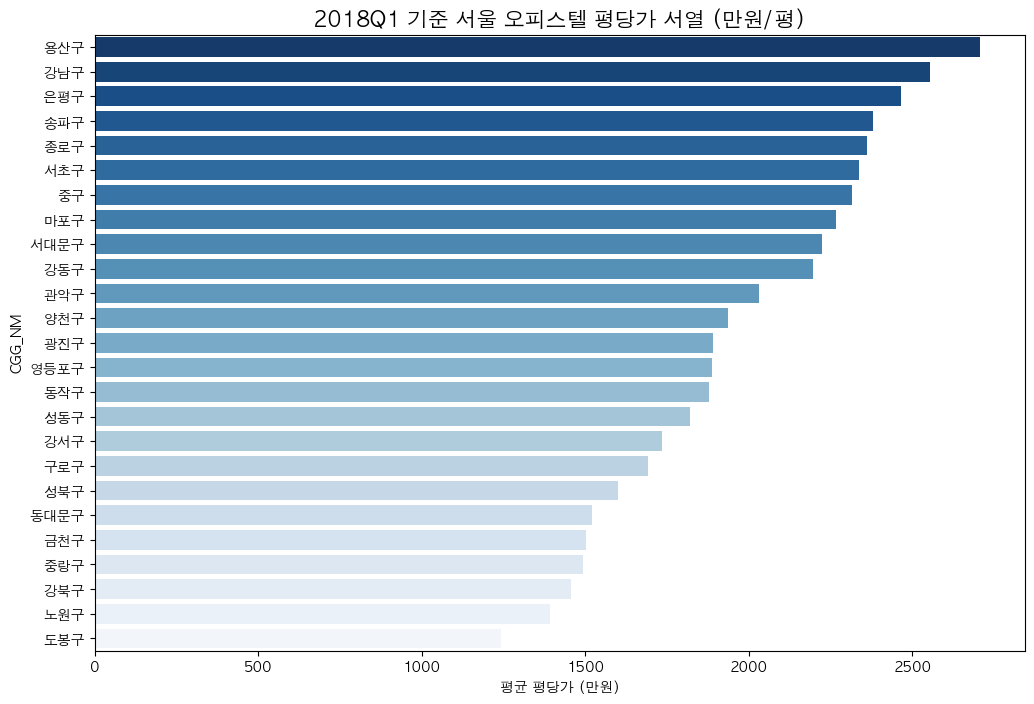

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_24657/2403308959.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=roi_ranking.values, y=roi_ranking.index, palette=colors)


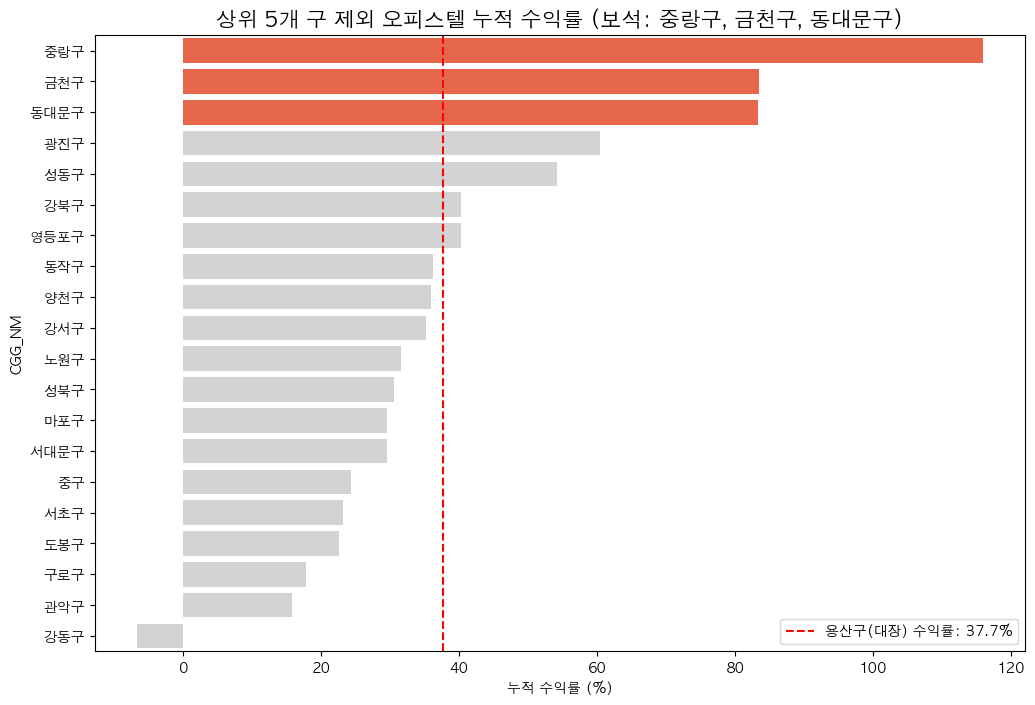

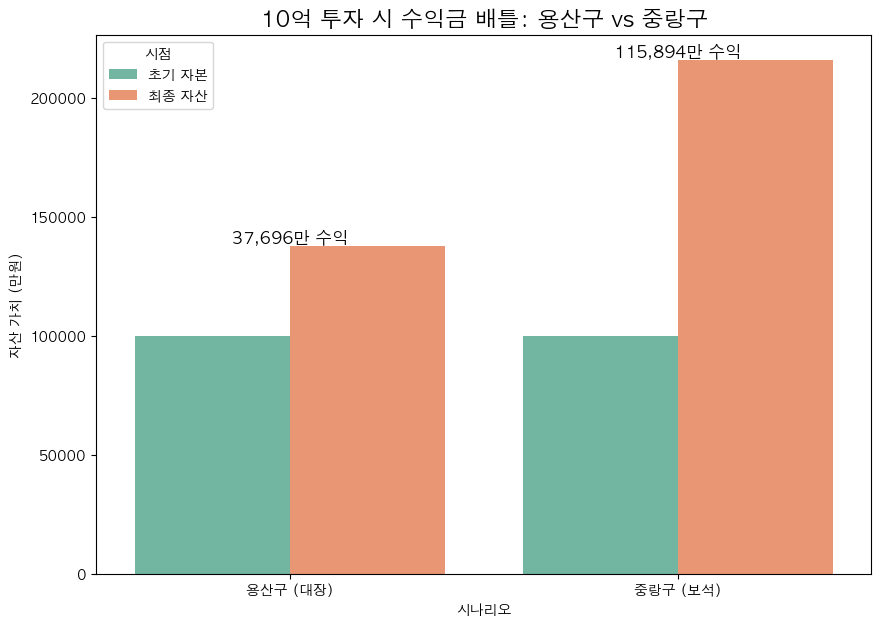

분석 완료! (2018Q1 -> 2024Q3)
용산구 (대장) 수익금: 37,696만원
중랑구 (보석) 수익금: 115,894만원
🔥 두 지역의 수익금 차이: 78,198만원


In [83]:
def run_ggeolmusae_final(df6, start_q='2018Q1', end_q='2024Q3'):
    # 폰트 설정 (맥북용)
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['axes.unicode_minus'] = False
    
    # [수정 포인트] 시작부터 '아파트'만 필터링하여 일관성 유지!
    apt_df = df6[df6['BLDG_USG'] == '오피스텔'].copy()
    
    # 1. 데이터 피벗 (필터링된 apt_df 사용)
    pivot_df = apt_df.pivot_table(index='QUARTER', columns='CGG_NM', values='AMT_PER_PYEONG', aggfunc='mean').sort_index()
    
    # 분석 기간 슬라이싱
    if start_q not in pivot_df.index: start_q = pivot_df.index[0]
    if end_q not in pivot_df.index: end_q = pivot_df.index[-1]
    pivot_df = pivot_df.loc[start_q:end_q]
    
    # --- [시각화 1] 시작 시점(start_q) 기준 가격 서열 ---
    initial_prices = pivot_df.loc[start_q].sort_values(ascending=False)
    top_5_gu = initial_prices.head(5).index.tolist()
    king_gu = top_5_gu[0] 
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x=initial_prices.values, y=initial_prices.index, palette='Blues_r')
    plt.title(f'{start_q} 기준 서울 오피스텔 평당가 서열 (만원/평)', fontsize=15)
    plt.xlabel('평균 평당가 (만원)')
    plt.show()

    # --- [시각화 2] 수익률 반전 (이제 순수하게 '아파트' 수익률만 비교) ---
    hidden_df = pivot_df.drop(columns=top_5_gu)
    roi_ranking = ((hidden_df.iloc[-1] / hidden_df.iloc[0]) - 1) * 100
    roi_ranking = roi_ranking.sort_values(ascending=False)
    
    # 상위 3개
    gem_top3 = roi_ranking.index[:3] 
    gem_gu = roi_ranking.index[0] # 시각화 3 유지를 위해 1등 변수는 남겨둠
    king_roi = ((pivot_df.loc[end_q, king_gu] / pivot_df.loc[start_q, king_gu]) - 1) * 100

    plt.figure(figsize=(12, 8))
    # 상위 3개(gem_top3)에 포함되면 주황색, 아니면 회색
    colors = ['#FF5733' if x in gem_top3 else '#D3D3D3' for x in roi_ranking.index]
    
    sns.barplot(x=roi_ranking.values, y=roi_ranking.index, palette=colors)
    plt.axvline(king_roi, color='red', linestyle='--', label=f'{king_gu}(대장) 수익률: {king_roi:.1f}%')
    # 제목에 Top 3 지역 이름 나열
    plt.title(f'상위 5개 구 제외 오피스텔 누적 수익률 (보석: {", ".join(gem_top3)})', fontsize=15)
    plt.xlabel('누적 수익률 (%)')
    plt.legend()
    plt.show()

    # --- [시각화 3] 수익금 배틀 (동일한 10억 투자 시나리오) ---
    capital = 100000 
    final_val_king = (capital / pivot_df.loc[start_q, king_gu]) * pivot_df.loc[end_q, king_gu]
    final_val_gem = (capital / pivot_df.loc[start_q, gem_gu]) * pivot_df.loc[end_q, gem_gu]
    
    battle_df = pd.DataFrame({
        '시나리오': [f'{king_gu} (대장)', f'{gem_gu} (보석)'],
        '초기 자본': [capital, capital],
        '최종 자산': [final_val_king, final_val_gem]
    })
    
    battle_melted = battle_df.melt(id_vars='시나리오', var_name='시점', value_name='금액')
    
    plt.figure(figsize=(10, 7))
    sns.barplot(data=battle_melted, x='시나리오', y='금액', hue='시점', palette='Set2')
    
    plt.text(0, final_val_king, f'{final_val_king-capital:,.0f}만 수익', ha='center', va='bottom', fontweight='bold', fontsize=12)
    plt.text(1, final_val_gem, f'{final_val_gem-capital:,.0f}만 수익', ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    plt.title(f'10억 투자 시 수익금 배틀: {king_gu} vs {gem_gu}', fontsize=16)
    plt.ylabel('자산 가치 (만원)')
    plt.show()

    # 차이 금액 계산
    profit_king = final_val_king - capital
    profit_gem = final_val_gem - capital
    diff = abs(profit_gem - profit_king)

    print(f"분석 완료! ({start_q} -> {end_q})")
    print(f"{king_gu} (대장) 수익금: {profit_king:,.0f}만원")
    print(f"{gem_gu} (보석) 수익금: {profit_gem:,.0f}만원")
    print(f"🔥 두 지역의 수익금 차이: {diff:,.0f}만원")

run_ggeolmusae_final(df6)

      [금천구 vs 용산구] 오피스텔 투자 백테스트 비교
1. 투자 기간 : 2018Q1 ~ 2024Q3 (27분기)
2. 매입 금액 : 30,000만 원
----------------------------------------------------------------
   구분        |      금천구      |     용산구
----------------------------------------------------------------
3. 최종 금액   |  55,032만 (+25,032만) |  41,309만 (+11,309만)
4. 누적 수익률 |      83.44 %       |      37.70 %
----------------------------------------------------------------
 * 비교 결과: 금천구의 수익률이 더 높습니다.



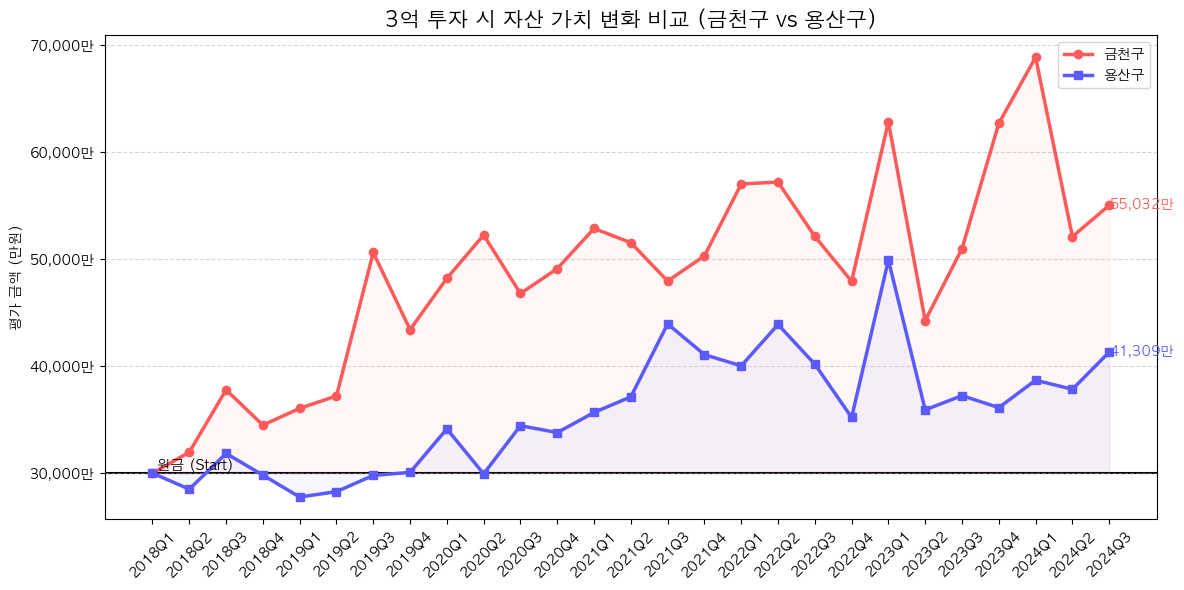

In [84]:
def run_real_estate_backtest_inter_gu(gu1, gu2, bldg_type, start_year, start_quarter, initial_capital, duration_quarters):
    """
    [자치구 vs 자치구] 두 지역의 부동산 투자 백테스트를 수행하고 비교합니다. (CAGR/MDD 제거)
    """
    # 0. 건물 용도 데이터 존재 여부 검증
    # df는 전역 변수로 가정
    available_types = df6['BLDG_USG'].unique()
    if bldg_type not in available_types:
        print(f"⚠️ 오류: 요청하신 건물 용도 '{bldg_type}'는 데이터셋에 존재하지 않습니다.")
        print(f"   (사용 가능한 용도: {list(available_types)})")
        return

    # 1. 분석 대상 기간 리스트 생성 (포맷: 2018Q1)
    target_quarters = []
    current_y, current_q = start_year, start_quarter
    
    for _ in range(duration_quarters + 1):
        target_quarters.append(f"{current_y}Q{current_q}")
        current_q += 1
        if current_q > 4:
            current_y += 1
            current_q = 1
            
    # 2. 데이터 필터링
    # (1) 첫 번째 자치구 (gu1)
    mask_1 = (
        (df6['QUARTER'].isin(target_quarters)) & 
        (df6['BLDG_USG'] == bldg_type) &
        (df6['CGG_NM'] == gu1)
    )
    df_1 = df6.loc[mask_1].copy()
    
    # (2) 두 번째 자치구 (gu2)
    mask_2 = (
        (df6['QUARTER'].isin(target_quarters)) & 
        (df6['BLDG_USG'] == bldg_type) &
        (df6['CGG_NM'] == gu2)
    )
    df_2 = df6.loc[mask_2].copy()
    
    if df_1.empty:
        print(f"[{gu1}] 해당 기간/용도의 데이터가 부족합니다.")
        return
    if df_2.empty:
        print(f"[{gu2}] 해당 기간/용도의 데이터가 부족합니다.")
        return

    # 공통 전처리 함수 (분기별 평단가 Series 생성)
    def get_price_series(temp_df):
        # Index: QUARTER, Value: AMT_PER_PYEONG
        series = temp_df.groupby('QUARTER')['AMT_PER_PYEONG'].mean()
        series = series.reindex(target_quarters).dropna()
        return series

    price_1 = get_price_series(df_1)
    price_2 = get_price_series(df_2)
    
    # 데이터가 중간에 끊겼으면 교집합 기간만 비교
    common_idx = price_1.index.intersection(price_2.index)
    if common_idx.empty:
        print("두 지역 간 겹치는 거래 기간이 없습니다.")
        return
        
    price_1 = price_1.loc[common_idx]
    price_2 = price_2.loc[common_idx]
    
    # 3. 자산 가치 변동 및 수익률 계산 함수 (CAGR, MDD 제거)
    def calc_metrics(price_series, capital):
        start_p = price_series.iloc[0]
        # (현재가 / 시작가) * 원금 = 현재 평가금액
        portfolio = (price_series / start_p) * capital
        
        final_val = portfolio.iloc[-1]
        ret = (final_val / capital - 1) * 100
        
        return portfolio, final_val, ret

    # 계산 수행
    pf_1, val_1, ret_1 = calc_metrics(price_1, initial_capital)
    pf_2, val_2, ret_2 = calc_metrics(price_2, initial_capital)
    
    profit_1 = val_1 - initial_capital
    profit_2 = val_2 - initial_capital
    
    # --- [결과 텍스트 출력] (단위: 만원) ---
    print(f"================================================================")
    print(f"      [{gu1} vs {gu2}] {bldg_type} 투자 백테스트 비교")
    print(f"================================================================")
    print(f"1. 투자 기간 : {common_idx[0]} ~ {common_idx[-1]} ({len(common_idx)}분기)")
    print(f"2. 매입 금액 : {initial_capital/10000:,.0f}만 원")
    print(f"----------------------------------------------------------------")
    print(f"   구분        |      {gu1}      |     {gu2}")
    print(f"----------------------------------------------------------------")
    print(f"3. 최종 금액   |  {val_1/10000:,.0f}만 ({profit_1/10000:+,.0f}만) |  {val_2/10000:,.0f}만 ({profit_2/10000:+,.0f}만)")
    print(f"4. 누적 수익률 |     {ret_1:6.2f} %       |     {ret_2:6.2f} %")
    print(f"----------------------------------------------------------------")
    
    better_gu = gu1 if ret_1 > ret_2 else gu2
    print(f" * 비교 결과: {better_gu}의 수익률이 더 높습니다.")
    print(f"================================================================\n")
    
    # --- [시각화] ---
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # (1) 데이터 플로팅
    # gu1: 빨간색 실선, gu2: 파란색 실선 (서울시는 보통 회색 점선으로 표현하지만 대등한 비교이므로 실선 사용)
    ax.plot(pf_1.index, pf_1, color='#FF5A5A', linewidth=2.5, marker='o', label=f'{gu1}')
    ax.plot(pf_2.index, pf_2, color='#5A5AFF', linewidth=2.5, marker='s', label=f'{gu2}')
    
    # (2) 기준선 (원금) 강조
    ax.axhline(initial_capital, color='black', linewidth=1.5, linestyle='-', zorder=1)
    ax.text(pf_1.index[0], initial_capital, " 원금 (Start)", va='bottom', fontweight='bold')
    
    # (3) 영역 채우기 (수익률 더 높은 쪽 강조 - 복잡해질 수 있어 단순 상승/하락보다는 두 선 사이 영역 채우기 고려 가능하나, 여기선 생략하거나 간단히 처리)
    # 여기서는 각 선 아래를 연하게 채워 시각적 볼륨감 부여
    ax.fill_between(pf_1.index, pf_1, initial_capital, color='#FF5A5A', alpha=0.05)
    ax.fill_between(pf_2.index, pf_2, initial_capital, color='#5A5AFF', alpha=0.05)
    
    ax.set_title(f"3억 투자 시 자산 가치 변화 비교 ({gu1} vs {gu2})", fontsize=15)
    ax.set_ylabel("평가 금액 (만원)")
    
    # Y축 포맷 (만원 단위)
    def ten_thousands(x, pos):
        return f'{x/10000:,.0f}만'
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(ten_thousands))
    
    # 최종 금액 라벨링
    ax.text(pf_1.index[-1], pf_1.iloc[-1], f"{pf_1.iloc[-1]/10000:,.0f}만", color='#FF5A5A', fontweight='bold', ha='left', va='center')
    ax.text(pf_2.index[-1], pf_2.iloc[-1], f"{pf_2.iloc[-1]/10000:,.0f}만", color='#5A5AFF', fontweight='bold', ha='left', va='center')

    # X축 라벨 회전 (45도)
    plt.xticks(rotation=45)
    
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 실행 예시: 종로구 vs 강남구, 아파트, 2018년 1분기부터 20분기(5년) 동안
run_real_estate_backtest_inter_gu("금천구", "용산구", "오피스텔", 2018, 1, 300000000, 27)

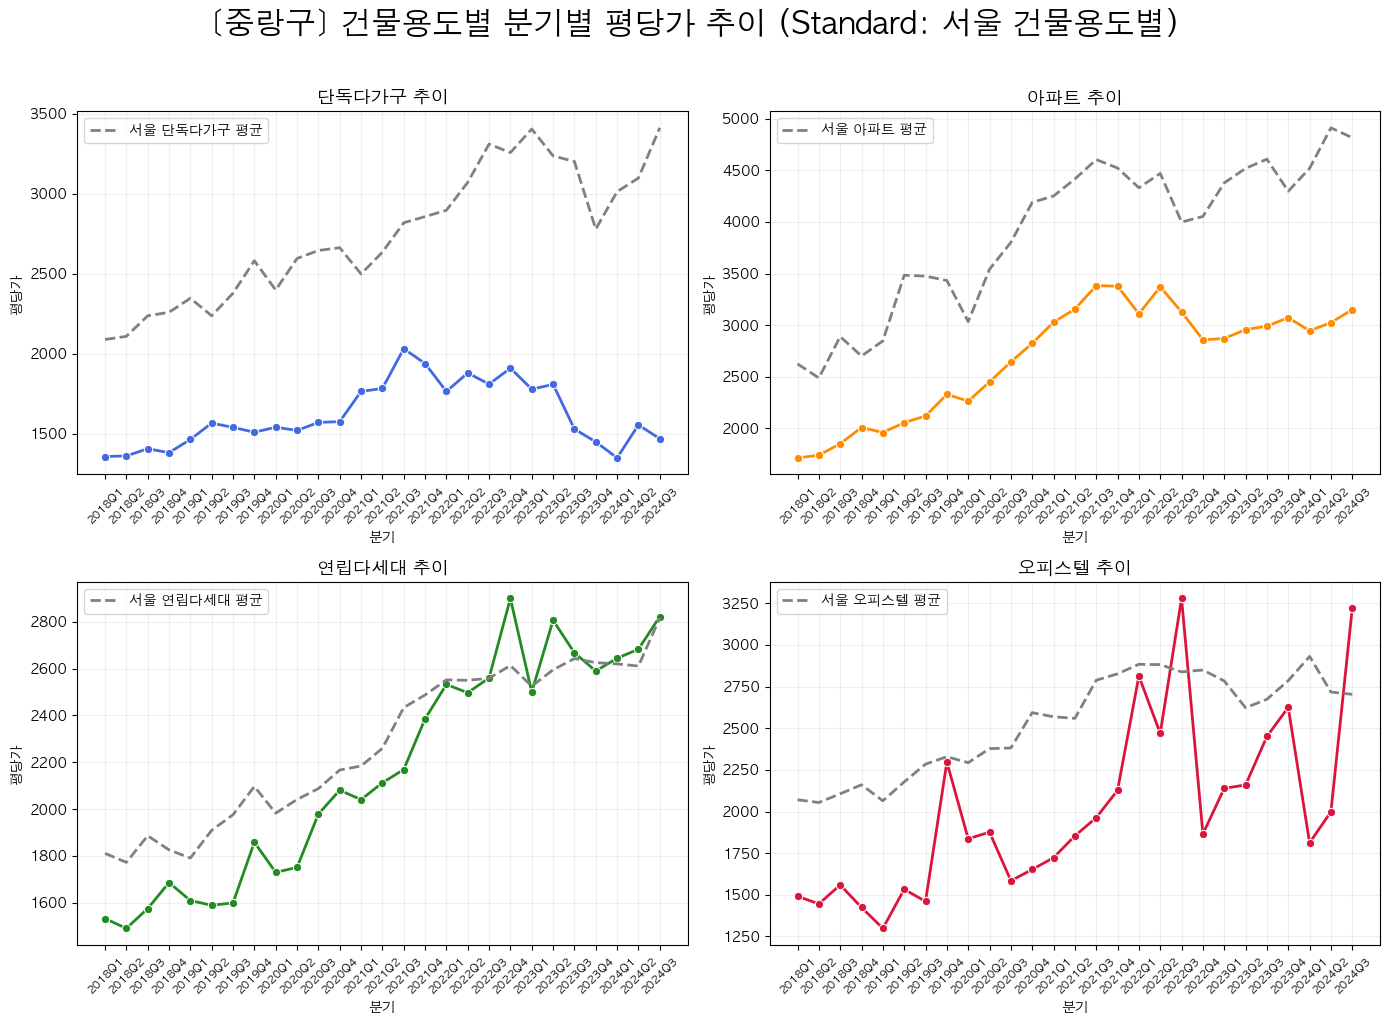

In [85]:
# 1. 자치구 데이터 필터링
jn_df = df6[df6['CGG_NM'] == '중랑구'].copy()

# 2. 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() # 2차원 배열을 1차원으로 펼쳐 반복문을 쉽게 만듦

# --- 용도별 4개 그래프 ---
usg_types = ['단독다가구', '아파트', '연립다세대', '오피스텔']
colors = ['royalblue', 'darkorange', 'forestgreen', 'crimson']

for i, usg in enumerate(usg_types):
    ax = axes[i]
    data = jn_df[jn_df['BLDG_USG'] == usg].groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index()
    seoul_data = df6[df6['BLDG_USG'] == usg].groupby('QUARTER')['AMT_PER_PYEONG'].mean().reset_index()
    
    if not data.empty:
        sns.lineplot(data=data, x='QUARTER', y='AMT_PER_PYEONG', marker='o', 
                        ax=ax, color=colors[i], linewidth=2)
        sns.lineplot(data=seoul_data, x='QUARTER', y='AMT_PER_PYEONG', 
                    ax=ax, color='gray', linestyle='--', linewidth=2, label=f'서울 {usg} 평균')
        
    ax.set_title(f"{usg} 추이", fontsize=13)
    ax.set_xlabel("분기")
    ax.set_ylabel("평당가")
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle(f"[중랑구] 건물용도별 분기별 평당가 추이 (Standard: 서울 건물용도별)", fontsize=22, y=1.02)
plt.tight_layout()
plt.show()

In [86]:
# 대상 분기 설정 및 데이터 필터링 (금천구 오피스텔)
target_quarters = ['2022Q2', '2023Q1', '2024Q1']
mask = (
    (df6['CGG_NM'] == '금천구') & 
    (df6['BLDG_USG'] == '오피스텔') & 
    (df6['QUARTER'].isin(target_quarters))
)
geumcheon_off_df = df6.loc[mask].copy()

# 건물명, 건축년도 기준으로 그룹화하여 거래 건수 집계
# 동일 건물이라도 건축년도가 다를 수 있으므로(드문 경우) 함께 묶습니다.
building_report = geumcheon_off_df.groupby(['QUARTER', 'BLDG_NM', 'ARCH_YR','THING_AMT','AMT_PER_PYEONG']).size().reset_index(name='거래건수')

# 분기별로 거래 건수가 많은 순서대로 정렬
building_report = building_report.sort_values(by=['QUARTER', '거래건수'], ascending=[True, False])

# 결과 출력
for q in target_quarters:
    print(f"\n--- {q} 금천구 오피스텔 거래 현황 ---")
    display_df = building_report[building_report['QUARTER'] == q].drop(columns='QUARTER')
    if display_df.empty:
        print("해당 분기 거래 데이터가 없습니다.")
    else:
        print(display_df.to_string(index=False))




--- 2022Q2 금천구 오피스텔 거래 현황 ---
        BLDG_NM  ARCH_YR  THING_AMT  AMT_PER_PYEONG  거래건수
     SHIN YOUNG     2022      24800     3091.396682    32
     SHIN YOUNG     2022      25350     3159.955882    24
     SHIN YOUNG     2022      25200     3095.732441    16
        독산헤리츠타워     2022      40950     2908.734637    16
     SHIN YOUNG     2022      24050     2997.906863    15
     SHIN YOUNG     2022      25650     3151.013378    12
     SHIN YOUNG     2022      48200     2858.621457    12
      계림 웨스트 벨리     2022      42600     2876.957712    12
        독산헤리츠타워     2022      40350     2866.115814    12
        독산헤리츠타워     2022      41150     2922.940911    12
      계림 웨스트 벨리     2022      44900     3032.286415    11
     SHIN YOUNG     2022      49250     2920.894331     9
     SHIN YOUNG     2022      24150     2966.743590     8
     SHIN YOUNG     2022      24550     3060.233409     8
     SHIN YOUNG     2022      24900     3093.364149     8
     SHIN YOUNG     2022      25050     3

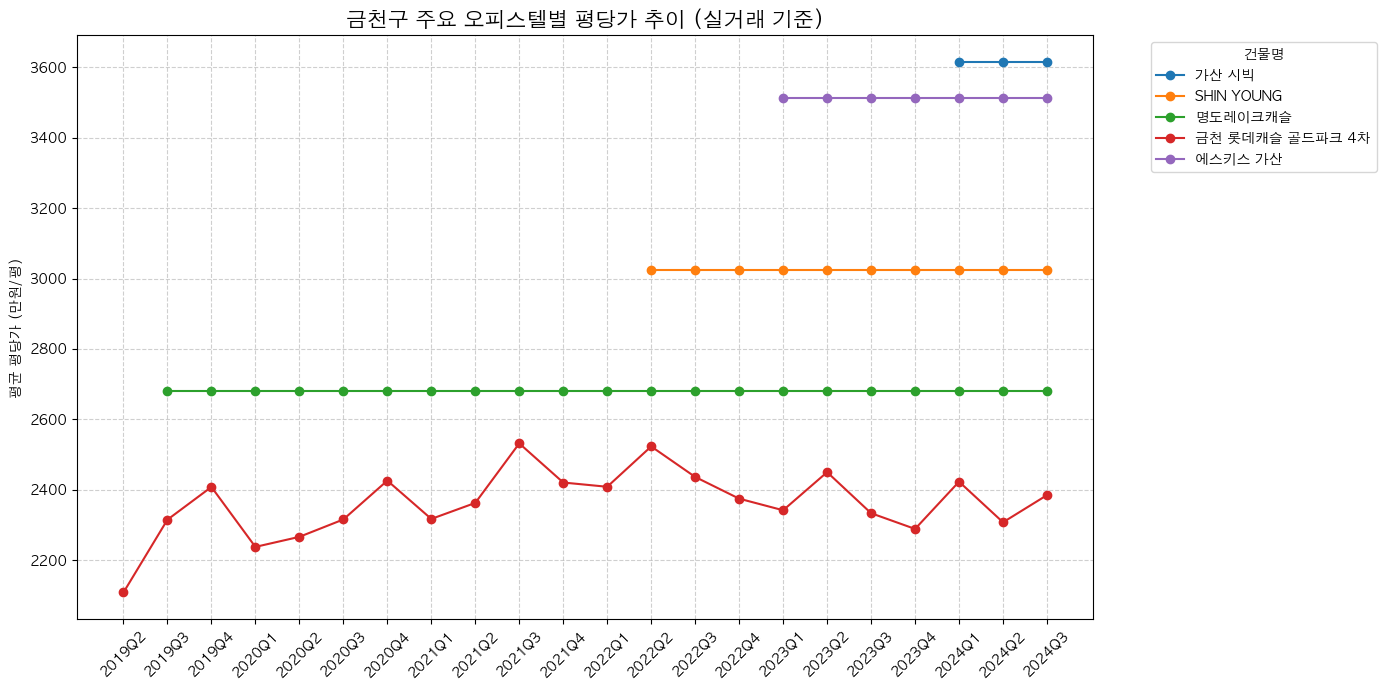

In [87]:
# 금천구 오피스텔 데이터만 추출
geumcheon_off = df6[(df6['CGG_NM'] == '금천구') & (df6['BLDG_USG'] == '오피스텔')].copy()

# 거래량이 가장 많았던 상위 5개 건물 추출
top_buildings = geumcheon_off['BLDG_NM'].value_counts().head(5).index.tolist()
trend_df = geumcheon_off[geumcheon_off['BLDG_NM'].isin(top_buildings)]

# 분기별 건물별 평균 평당가 피벗
building_pivot = trend_df.pivot_table(
    index='QUARTER', 
    columns='BLDG_NM', 
    values='AMT_PER_PYEONG', 
    aggfunc='mean'
).interpolate() # 데이터가 없는 분기는 선을 이어줌

# 시각화 (맥북 폰트 설정 포함)
plt.figure(figsize=(14, 7))
plt.rcParams['font.family'] = 'AppleGothic'

for bldg in top_buildings:
    plt.plot(building_pivot.index, building_pivot[bldg], marker='o', label=bldg)

plt.title('금천구 주요 오피스텔별 평당가 추이 (실거래 기준)', fontsize=15)
plt.ylabel('평균 평당가 (만원/평)')
plt.xticks(rotation=45)
plt.legend(title='건물명', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()